<a href="https://colab.research.google.com/github/Ehsan-Roohi/DSMC_Python/blob/main/8_Collision_Models_Relaxation_Frequency_correct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC: 1
--- DSMC Relaxation using method: SBT ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 500 particles.
Step: 4000/40000 | Total Collisions: 3997
Step: 8000/40000 | Total Collisions: 8164
Step: 12000/40000 | Total Collisions: 12097
Step: 16000/40000 | Total Collisions: 16095
Step: 20000/40000 | Total Collisions: 20093
Step: 24000/40000 | Total Collisions: 24105
Step: 28000/40000 | Total Collisions: 28078
Step: 32000/40000 | Total Collisions: 32116
Step: 36000/40000 | Total Collisions: 36041
Step: 40000/40000 | Total Collisions: 40118

Simulation finished in 106.16 seconds.
Final Equilibrium Temperature: 282.18 K
Total Simulated Collisions: 40118
Total Theoretical Collisions (TCOL): 40084.18
FINAL RATIO (Simulated/Theoretical): 1.0008


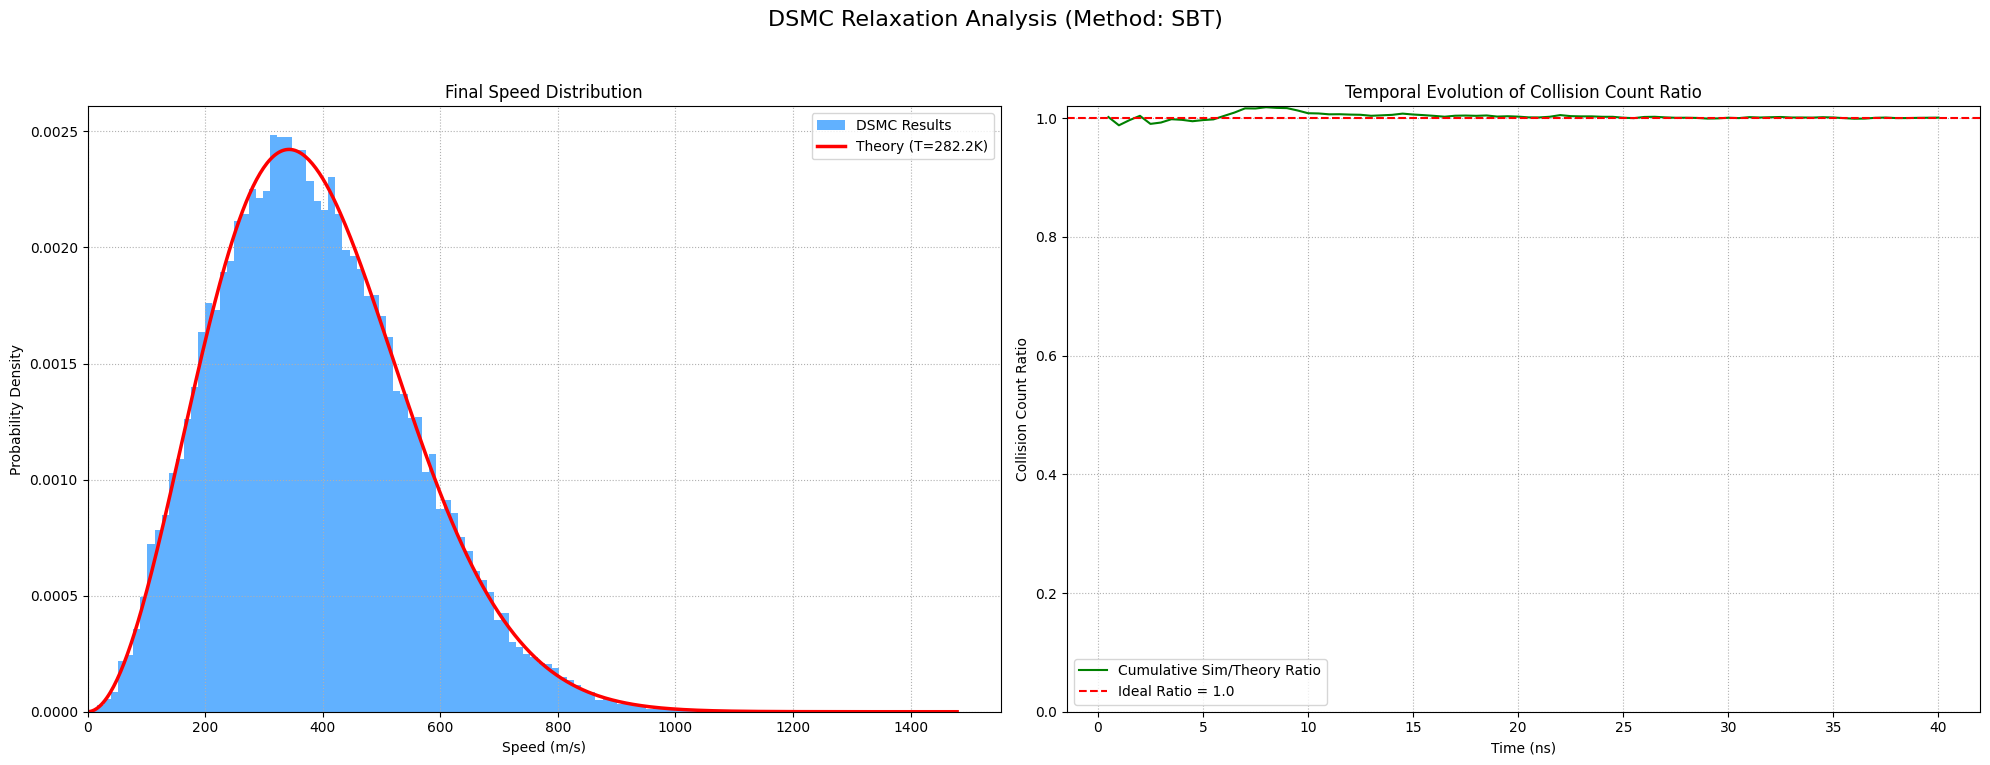

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V4.7 - FINAL CORRECTED AND COMPLETE CODE ---
# This version provides a complete, runnable script with a choice between three
# collision schemes and fixes the NameError by defining functions in the correct order.
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 5
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_START_TIME = 1.0e-8
SAMPLING_INTERVAL = 500

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (First-Order O(N) implementation based on the provided image)
        # Loop over each particle 'i' from 0 to N-2
        for i in range(num_particles_in_cell - 1):
            # Randomly select a collision partner 'j' from the particles after 'i'
            # as described in Eq. (4.5)
            j_local = rng_state.integers(i + 1, num_particles_in_cell)

            p1_idx = indices_in_cell[i]
            p2_idx = indices_in_cell[j_local]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))

            if vr_mag < 1e-9:
                continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)

            # Calculate collision probability using Eq. (4.6)
            # The factor (N'(l) - i) accounts for only selecting one pair instead of all of them.
            # Using 0-based index for 'i', the number of potential partners is (num_particles_in_cell - 1 - i).
            # The text (using 1-based index) uses (N-i). In our 0-based index this is (N - (i+1)).
            multiplier = num_particles_in_cell - (i + 1)
            collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell
    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell
    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

# --- Plotting and Initialization functions defined BEFORE run_dsmc_simulation ---
def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=16)

    ax1.hist(sampled_speeds, bins=100, density=True, label=f'DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Count Ratio'); ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    sampled_speeds = []
    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)

    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    sampling_start_step = int(SAMPLING_START_TIME / DT)
    cell_width = LX / NUM_CELLS_X

    # <<< CORRECTED: Total volume definition to be consistent >>>
    total_volume = LX

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i])
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (1.0 / (3.0 * KB)) * MASS_AR * np.mean(np.var(particles[:, 1:4], axis=0)) * 3.0

            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= sampling_start_step and step % 200 == 0:
            sampled_speeds.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (1.0 / (3.0 * KB)) * MASS_AR * np.mean(np.sum(np.var(particles[:, 1:4], axis=0)))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sampled_speeds:
        plot_results(np.array(sampled_speeds), final_temp, collision_method_name, time_history, ratio_history)

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC: ")
        if choice in ['1', '2', '3']:
            run_dsmc_simulation(method_code=int(choice))
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC: 3
--- DSMC Relaxation using method: NTC ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 1000 particles.
Step: 10000/100000 | Total Collisions: 8400
Step: 20000/100000 | Total Collisions: 24646
Step: 30000/100000 | Total Collisions: 43626
Step: 40000/100000 | Total Collisions: 63107
Step: 50000/100000 | Total Collisions: 82942
Step: 60000/100000 | Total Collisions: 102790
Step: 70000/100000 | Total Collisions: 122601
Step: 80000/100000 | Total Collisions: 142069
Step: 90000/100000 | Total Collisions: 161948
Step: 100000/100000 | Total Collisions: 181558

Simulation finished in 264.35 seconds.
Final Equilibrium Temperature: 274.85 K
Total Simulated Collisions: 181558
Total Theoretical Collisions (TCOL): 197799.38
FINAL RATIO (Simulated/Theoretical): 0.9179


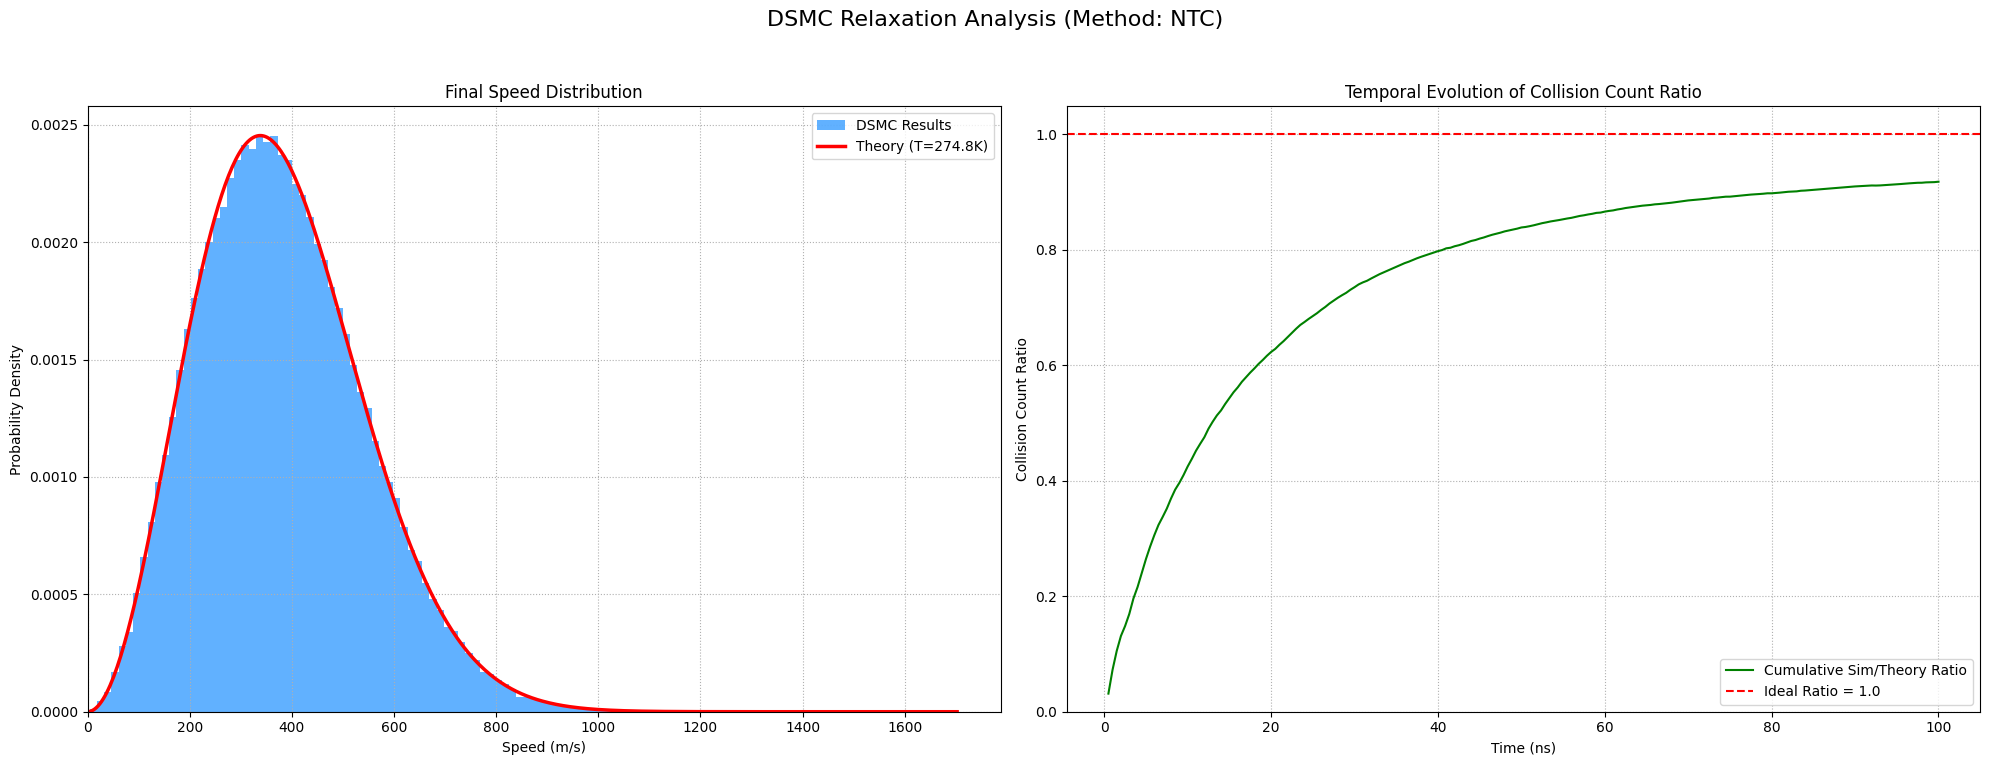

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V4.7 - FINAL CORRECTED AND COMPLETE CODE ---
# This version provides a complete, runnable script with a choice between three
# collision schemes and fixes the NameError by defining functions in the correct order.
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 10
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 1.0e-7
SAMPLING_START_TIME = 1.0e-8
SAMPLING_INTERVAL = 500

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (First-Order O(N) implementation based on the provided image)
        # Loop over each particle 'i' from 0 to N-2
        for i in range(num_particles_in_cell - 1):
            # Randomly select a collision partner 'j' from the particles after 'i'
            # as described in Eq. (4.5)
            j_local = rng_state.integers(i + 1, num_particles_in_cell)

            p1_idx = indices_in_cell[i]
            p2_idx = indices_in_cell[j_local]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))

            if vr_mag < 1e-9:
                continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)

            # Calculate collision probability using Eq. (4.6)
            # The factor (N'(l) - i) accounts for only selecting one pair instead of all of them.
            # Using 0-based index for 'i', the number of potential partners is (num_particles_in_cell - 1 - i).
            # The text (using 1-based index) uses (N-i). In our 0-based index this is (N - (i+1)).
            multiplier = num_particles_in_cell - (i + 1)
            collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell
    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell
    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

# --- Plotting and Initialization functions defined BEFORE run_dsmc_simulation ---
def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=16)

    ax1.hist(sampled_speeds, bins=100, density=True, label=f'DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Count Ratio'); ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    sampled_speeds = []
    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)

    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    sampling_start_step = int(SAMPLING_START_TIME / DT)
    cell_width = LX / NUM_CELLS_X

    # <<< CORRECTED: Total volume definition to be consistent >>>
    total_volume = LX

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i])
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (1.0 / (3.0 * KB)) * MASS_AR * np.mean(np.var(particles[:, 1:4], axis=0)) * 3.0

            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= sampling_start_step and step % 200 == 0:
            sampled_speeds.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (1.0 / (3.0 * KB)) * MASS_AR * np.mean(np.sum(np.var(particles[:, 1:4], axis=0)))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sampled_speeds:
        plot_results(np.array(sampled_speeds), final_temp, collision_method_name, time_history, ratio_history)

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC: ")
        if choice in ['1', '2', '3']:
            run_dsmc_simulation(method_code=int(choice))
            break
        else:
            print("Invalid input.")

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V4.7 - FINAL CORRECTED AND COMPLETE CODE ---
# This version provides a complete, runnable script with a choice between three
# collision schemes and fixes the NameError by defining functions in the correct order.
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 10
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-7
SAMPLING_START_TIME = 1.0e-8
SAMPLING_INTERVAL = 500

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (First-Order O(N) implementation based on the provided image)
        # Loop over each particle 'i' from 0 to N-2
        for i in range(num_particles_in_cell - 1):
            # Randomly select a collision partner 'j' from the particles after 'i'
            # as described in Eq. (4.5)
            j_local = rng_state.integers(i + 1, num_particles_in_cell)

            p1_idx = indices_in_cell[i]
            p2_idx = indices_in_cell[j_local]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))

            if vr_mag < 1e-9:
                continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)

            # Calculate collision probability using Eq. (4.6)
            # The factor (N'(l) - i) accounts for only selecting one pair instead of all of them.
            # Using 0-based index for 'i', the number of potential partners is (num_particles_in_cell - 1 - i).
            # The text (using 1-based index) uses (N-i). In our 0-based index this is (N - (i+1)).
            multiplier = num_particles_in_cell - (i + 1)
            collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell
    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell
    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

# --- Plotting and Initialization functions defined BEFORE run_dsmc_simulation ---
def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=16)

    ax1.hist(sampled_speeds, bins=100, density=True, label=f'DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Count Ratio'); ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    sampled_speeds = []
    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)

    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    sampling_start_step = int(SAMPLING_START_TIME / DT)
    cell_width = LX / NUM_CELLS_X

    # <<< CORRECTED: Total volume definition to be consistent >>>
    total_volume = LX

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i])
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (1.0 / (3.0 * KB)) * MASS_AR * np.mean(np.var(particles[:, 1:4], axis=0)) * 3.0

            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= sampling_start_step and step % 200 == 0:
            sampled_speeds.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (1.0 / (3.0 * KB)) * MASS_AR * np.mean(np.sum(np.var(particles[:, 1:4], axis=0)))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sampled_speeds:
        plot_results(np.array(sampled_speeds), final_temp, collision_method_name, time_history, ratio_history)

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC: ")
        if choice in ['1', '2', '3']:
            run_dsmc_simulation(method_code=int(choice))
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC: 3
--- DSMC Relaxation using method: NTC ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 1000 particles.
Step: 40000/400000 | Total Collisions: 63107
Step: 80000/400000 | Total Collisions: 142069
Step: 120000/400000 | Total Collisions: 220939
Step: 160000/400000 | Total Collisions: 300184


/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC: 3
--- DSMC Relaxation using method: NTC ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 1000 particles.
Step: 4000/40000 | Total Collisions: 61710
Step: 8000/40000 | Total Collisions: 140665
Step: 12000/40000 | Total Collisions: 220256
Step: 16000/40000 | Total Collisions: 299866
Step: 20000/40000 | Total Collisions: 379024
Step: 24000/40000 | Total Collisions: 458384
Step: 28000/40000 | Total Collisions: 537347
Step: 32000/40000 | Total Collisions: 616330
Step: 36000/40000 | Total Collisions: 695259
Step: 40000/40000 | Total Collisions: 774426

Simulation finished in 115.51 seconds.
Final Equilibrium Temperature: 274.85 K
Total Simulated Collisions: 774426
Total Theoretical Collisions (TCOL): 791197.54
FINAL RATIO (Simulated/Theoretical): 0.9788


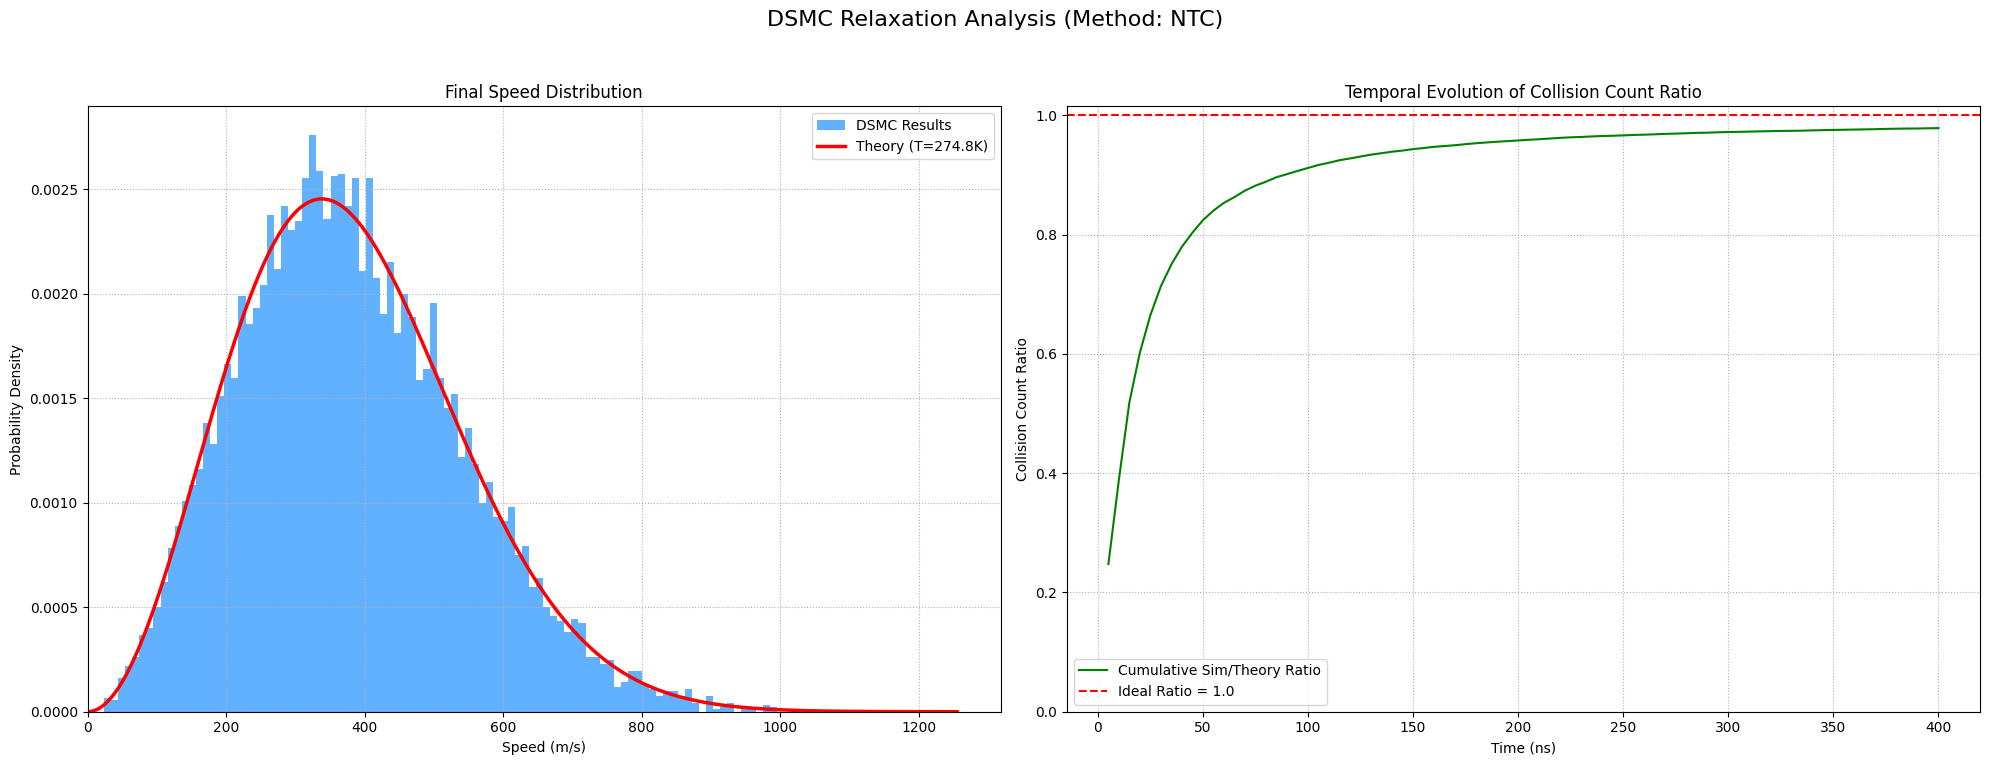

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V4.9 - BUG FIX for UnboundLocalError ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 10
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-11
TOTAL_TIME = 4.0e-7
SAMPLING_INTERVAL = 500

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (First-Order O(N) implementation)
        for i in range(num_particles_in_cell - 1):
            j_local = rng_state.integers(i + 1, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            multiplier = num_particles_in_cell - (i + 1)
            collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell
    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=16)

    ax1.hist(sampled_speeds, bins=100, density=True, label=f'DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Count Ratio'); ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    sampled_speeds = []
    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)

    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX

    # BUG FIX: Define cell_width before the loop that uses it.
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i])
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))

            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
            sampled_speeds.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sampled_speeds:
        plot_results(np.array(sampled_speeds), final_temp, collision_method_name, time_history, ratio_history)
    else:
        print("\nWarning: No speed data was sampled. The simulation might be too short or sampling parameters are too restrictive.")


if __name__ == "__main__":
    # The 'nopython is set' warning is a known Numba issue and can be safely ignored here.
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC: ")
        if choice in ['1', '2', '3']:
            run_dsmc_simulation(method_code=int(choice))
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC: 3
--- DSMC Relaxation using method: NTC ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 2000 particles.
Step: 4000/40000 | Total Collisions: 142099
Step: 8000/40000 | Total Collisions: 300407
Step: 12000/40000 | Total Collisions: 457905
Step: 16000/40000 | Total Collisions: 615296
Step: 20000/40000 | Total Collisions: 773229
Step: 24000/40000 | Total Collisions: 931559
Step: 28000/40000 | Total Collisions: 1089142
Step: 32000/40000 | Total Collisions: 1246493
Step: 36000/40000 | Total Collisions: 1404620
Step: 40000/40000 | Total Collisions: 1561954

Simulation finished in 139.87 seconds.
Final Equilibrium Temperature: 273.07 K
Total Simulated Collisions: 1561954
Total Theoretical Collisions (TCOL): 1577256.72
FINAL RATIO (Simulated/Theoretical): 0.9903


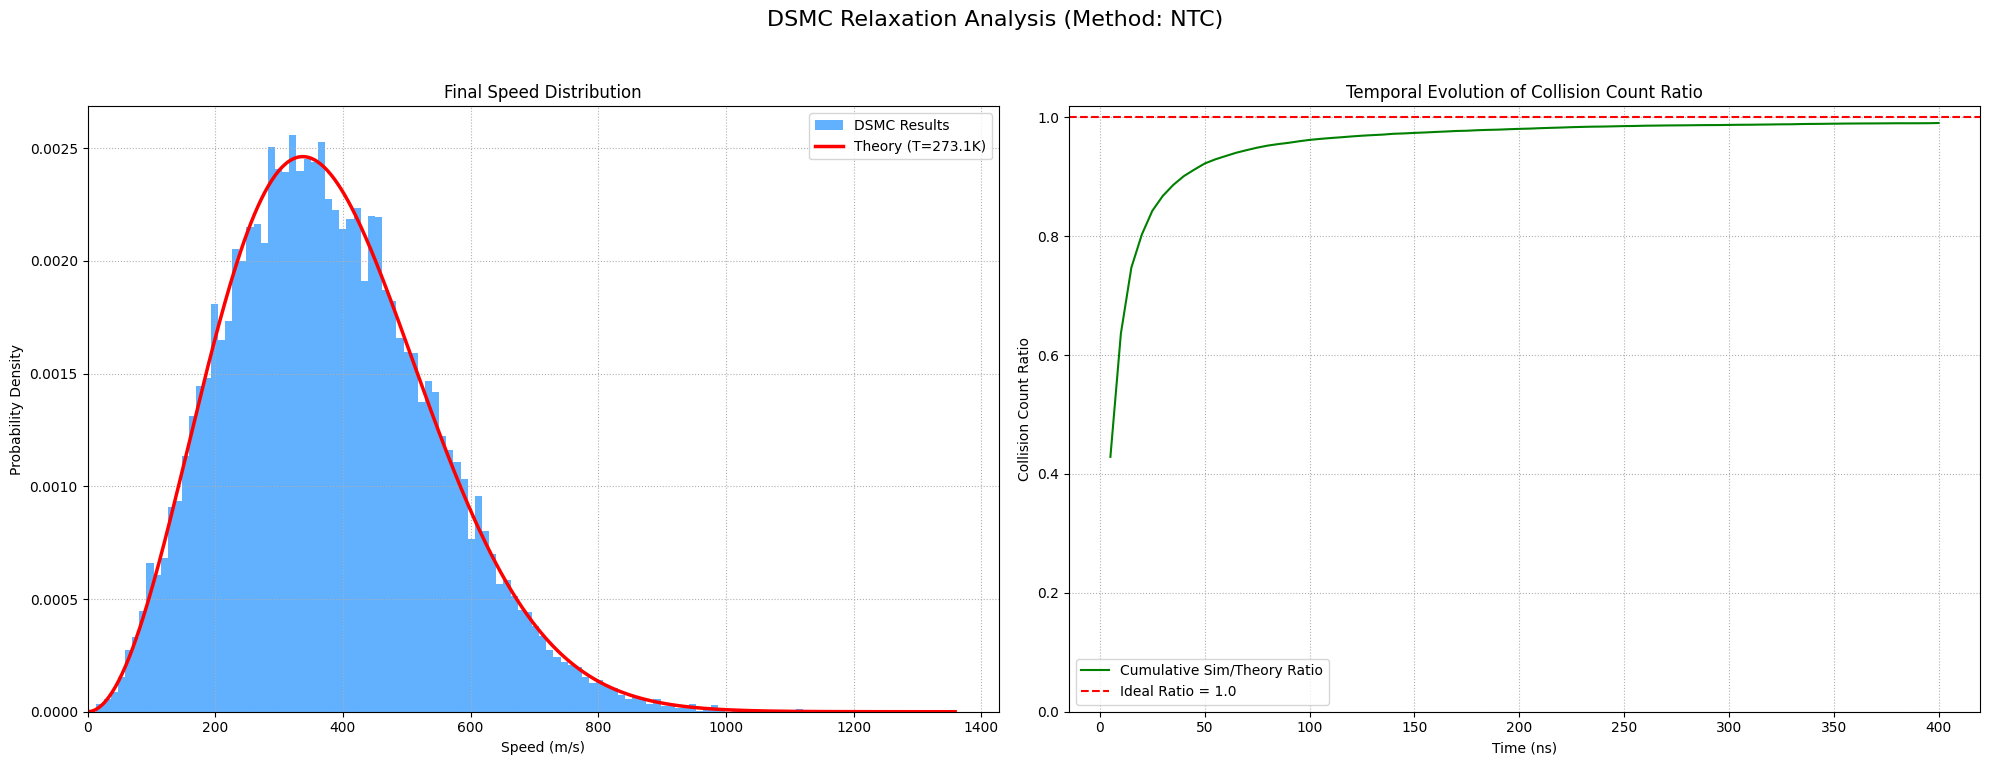

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V4.9 - BUG FIX for UnboundLocalError ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 20
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-11
TOTAL_TIME = 4.0e-7
SAMPLING_INTERVAL = 500

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (First-Order O(N) implementation)
        for i in range(num_particles_in_cell - 1):
            j_local = rng_state.integers(i + 1, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            multiplier = num_particles_in_cell - (i + 1)
            collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell
    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=16)

    ax1.hist(sampled_speeds, bins=100, density=True, label=f'DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Count Ratio'); ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    sampled_speeds = []
    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)

    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX

    # BUG FIX: Define cell_width before the loop that uses it.
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i])
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))

            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
            sampled_speeds.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sampled_speeds:
        plot_results(np.array(sampled_speeds), final_temp, collision_method_name, time_history, ratio_history)
    else:
        print("\nWarning: No speed data was sampled. The simulation might be too short or sampling parameters are too restrictive.")


if __name__ == "__main__":
    # The 'nopython is set' warning is a known Numba issue and can be safely ignored here.
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC: ")
        if choice in ['1', '2', '3']:
            run_dsmc_simulation(method_code=int(choice))
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC: 2
--- DSMC Relaxation using method: DCP ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 2000 particles.
Step: 4000/40000 | Total Collisions: 157559
Step: 8000/40000 | Total Collisions: 315318
Step: 12000/40000 | Total Collisions: 473084
Step: 16000/40000 | Total Collisions: 630486
Step: 20000/40000 | Total Collisions: 788163
Step: 24000/40000 | Total Collisions: 945973
Step: 28000/40000 | Total Collisions: 1103650
Step: 32000/40000 | Total Collisions: 1261498
Step: 36000/40000 | Total Collisions: 1419334
Step: 40000/40000 | Total Collisions: 1576820

Simulation finished in 267.30 seconds.
Final Equilibrium Temperature: 273.07 K
Total Simulated Collisions: 1576820
Total Theoretical Collisions (TCOL): 1577256.72
FINAL RATIO (Simulated/Theoretical): 0.9997


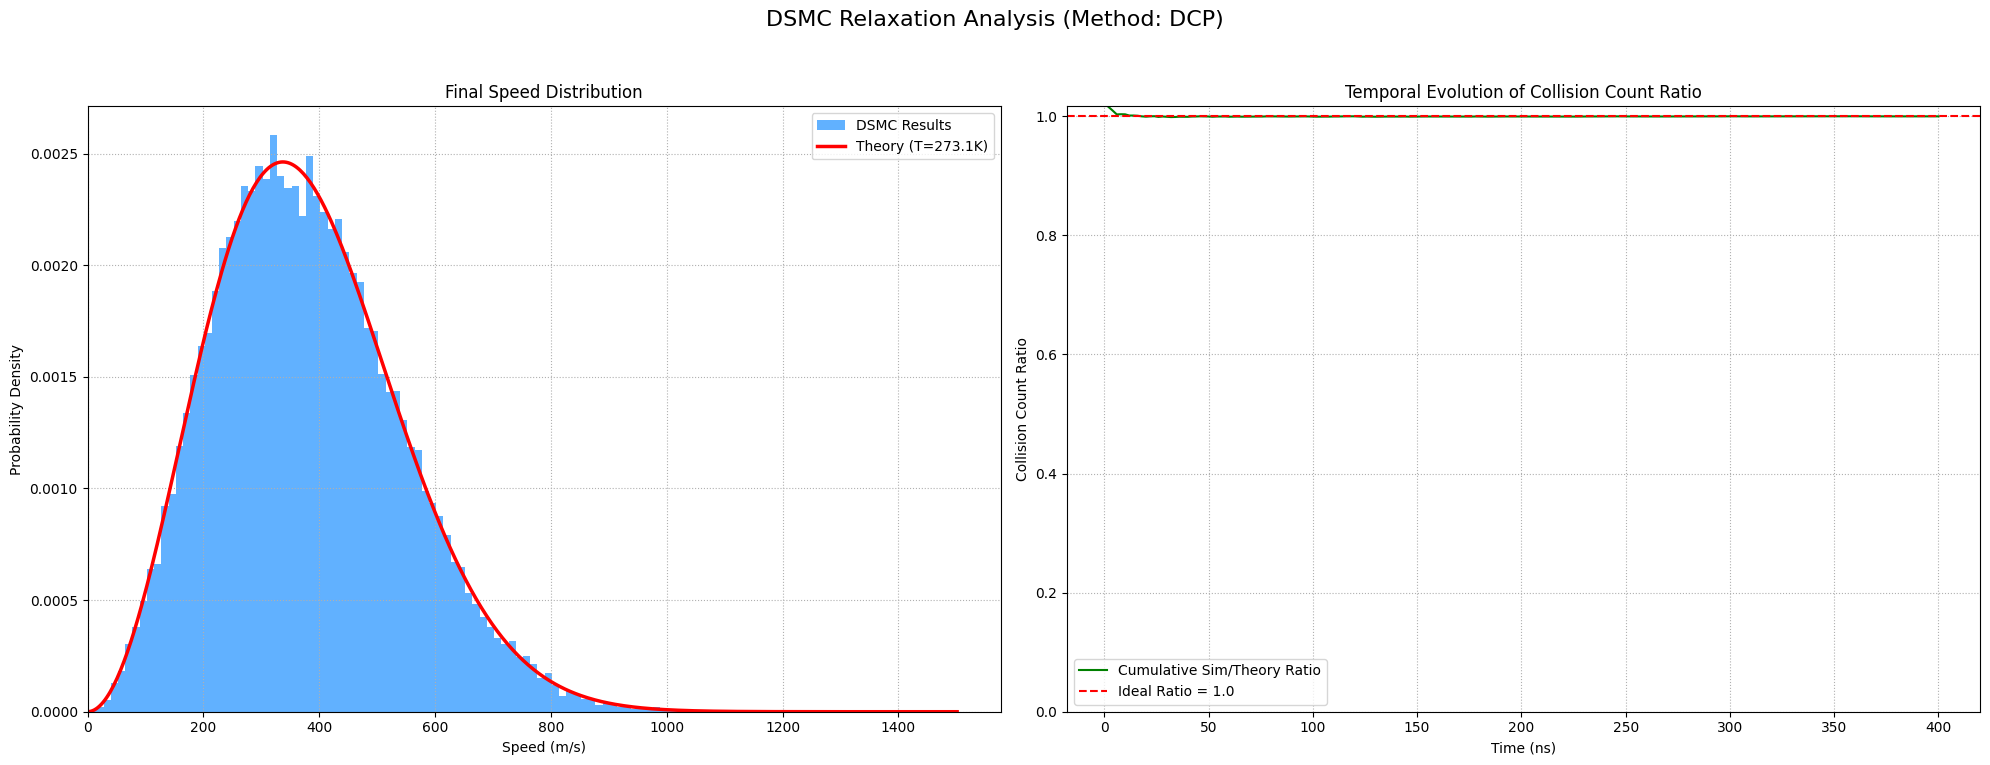

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V4.9 - BUG FIX for UnboundLocalError ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 20
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-11
TOTAL_TIME = 4.0e-7
SAMPLING_INTERVAL = 200

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (First-Order O(N) implementation)
        for i in range(num_particles_in_cell - 1):
            j_local = rng_state.integers(i + 1, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            multiplier = num_particles_in_cell - (i + 1)
            collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell
    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=16)

    ax1.hist(sampled_speeds, bins=100, density=True, label=f'DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Count Ratio'); ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    sampled_speeds = []
    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)

    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX

    # BUG FIX: Define cell_width before the loop that uses it.
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i])
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))

            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
            sampled_speeds.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sampled_speeds:
        plot_results(np.array(sampled_speeds), final_temp, collision_method_name, time_history, ratio_history)
    else:
        print("\nWarning: No speed data was sampled. The simulation might be too short or sampling parameters are too restrictive.")


if __name__ == "__main__":
    # The 'nopython is set' warning is a known Numba issue and can be safely ignored here.
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC: ")
        if choice in ['1', '2', '3']:
            run_dsmc_simulation(method_code=int(choice))
            break
        else:
            print("Invalid input.")

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V4.9 - BUG FIX for UnboundLocalError ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 2
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-11
TOTAL_TIME = 24.0e-7
SAMPLING_INTERVAL = 500

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (First-Order O(N) implementation)
        for i in range(num_particles_in_cell - 1):
            j_local = rng_state.integers(i + 1, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            multiplier = num_particles_in_cell - (i + 1)
            collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell
    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    # Set larger font sizes for all plot elements
    plt.rcParams.update({
        'font.size': 22,
        'axes.labelsize': 24,
        'axes.titlesize': 26,
        'xtick.labelsize': 20,
        'ytick.labelsize': 20,
        'legend.fontsize': 18,
        'figure.titlesize': 28
    })

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})')

    # Plot 1: Speed Distribution
    ax1.hist(sampled_speeds, bins=100, density=True, label=f'DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=0)

    # Plot 2: Collision Ratio History
    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Count Ratio'); ax2.set_title('Temporal Evolution of Collision Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':')

    # --- START OF MODIFIED SECTION ---
    # Set the y-axis limit for the second plot to make the '1.0' line clear
    ax2.set_ylim(bottom=0, top=1.1)
    # --- END OF MODIFIED SECTION ---

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save the figure as an EPS file
    plt.savefig("dsmc_relaxation_results.eps", format='eps')
    print("\nPlot saved as dsmc_relaxation_results.eps")

    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    sampled_speeds = []
    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)

    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX

    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i])
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))

            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
            sampled_speeds.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sampled_speeds:
        plot_results(np.array(sampled_speeds), final_temp, collision_method_name, time_history, ratio_history)
    else:
        print("\nWarning: No speed data was sampled. The simulation might be too short or sampling parameters are too restrictive.")


if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC: ")
        if choice in ['1', '2', '3']:
            run_dsmc_simulation(method_code=int(choice))
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC: 3
--- DSMC Relaxation using method: NTC ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 200 particles.
Step: 24000/240000 | Total Collisions: 77734
Step: 48000/240000 | Total Collisions: 172927
Step: 72000/240000 | Total Collisions: 268479
Step: 96000/240000 | Total Collisions: 363904
Step: 120000/240000 | Total Collisions: 459603
Step: 144000/240000 | Total Collisions: 554941
Step: 168000/240000 | Total Collisions: 650538


/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC: 2
--- DSMC Relaxation using method: DCP ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 2000 particles.
Step: 4000/40000 | Total Collisions: 157559
Step: 8000/40000 | Total Collisions: 315318
Step: 12000/40000 | Total Collisions: 473084
Step: 16000/40000 | Total Collisions: 630486
Step: 20000/40000 | Total Collisions: 788163
Step: 24000/40000 | Total Collisions: 945973
Step: 28000/40000 | Total Collisions: 1103650
Step: 32000/40000 | Total Collisions: 1261498
Step: 36000/40000 | Total Collisions: 1419334
Step: 40000/40000 | Total Collisions: 1576820

Simulation finished in 260.23 seconds.
Final Equilibrium Temperature: 273.07 K
Total Simulated Collisions: 1576820
Total Theoretical Collisions (TCOL): 1577256.72
FINAL RATIO (Simulated/Theoretical): 0.9997



Plot saved as dsmc_relaxation_results.eps


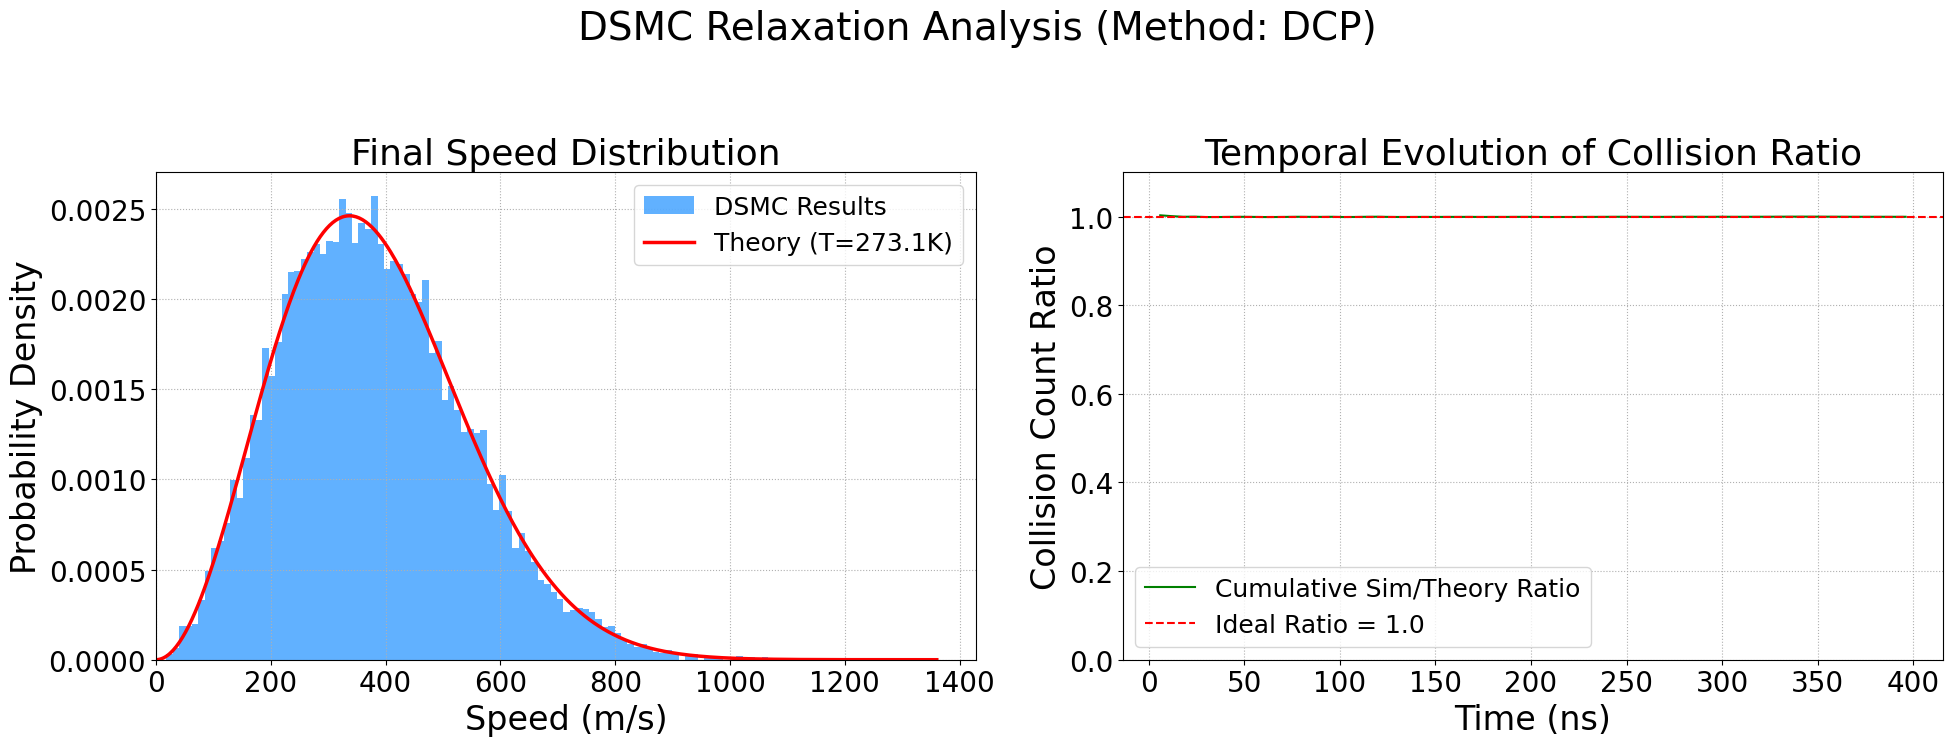

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V4.9 - BUG FIX for UnboundLocalError ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 20
# 🔥 FIX: Ensure the total number of particles is an integer
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-11
TOTAL_TIME = 4.0e-7
SAMPLING_INTERVAL = 600

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (First-Order O(N) implementation)
        for i in range(num_particles_in_cell - 1):
            j_local = rng_state.integers(i + 1, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            multiplier = num_particles_in_cell - (i + 1)
            collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell
    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    # Set larger font sizes for all plot elements
    plt.rcParams.update({
        'font.size': 22,
        'axes.labelsize': 24,
        'axes.titlesize': 26,
        'xtick.labelsize': 20,
        'ytick.labelsize': 20,
        'legend.fontsize': 18,
        'figure.titlesize': 28
    })

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})')

    # Plot 1: Speed Distribution
    ax1.hist(sampled_speeds, bins=100, density=True, label=f'DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=0)

    # Plot 2: Collision Ratio History
    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Count Ratio'); ax2.set_title('Temporal Evolution of Collision Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':')

    # --- START OF MODIFIED SECTION ---
    # Set the y-axis limit for the second plot to make the '1.0' line clear
    ax2.set_ylim(bottom=0, top=1.1)
    # --- END OF MODIFIED SECTION ---

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save the figure as an EPS file
    plt.savefig("dsmc_relaxation_results.eps", format='eps')
    print("\nPlot saved as dsmc_relaxation_results.eps")

    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    sampled_speeds = []
    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)

    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX

    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i])
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))

            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
            sampled_speeds.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sampled_speeds:
        plot_results(np.array(sampled_speeds), final_temp, collision_method_name, time_history, ratio_history)
    else:
        print("\nWarning: No speed data was sampled. The simulation might be too short or sampling parameters are too restrictive.")


if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC: ")
        if choice in ['1', '2', '3']:
            run_dsmc_simulation(method_code=int(choice))
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT: 4
--- DSMC Relaxation using method: GBT ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 1000 particles.
Step: 4000/40000 | Total Collisions: 7723
Step: 8000/40000 | Total Collisions: 15654
Step: 12000/40000 | Total Collisions: 23527
Step: 16000/40000 | Total Collisions: 31479
Step: 20000/40000 | Total Collisions: 39527
Step: 24000/40000 | Total Collisions: 47461
Step: 28000/40000 | Total Collisions: 55190
Step: 32000/40000 | Total Collisions: 63093
Step: 36000/40000 | Total Collisions: 70868
Step: 40000/40000 | Total Collisions: 78657

Simulation finished in 132.10 seconds.
Final Equilibrium Temperature: 274.85 K
Total Simulated Collisions: 78657
Total Theoretical Collisions (TCOL): 79119.75
FINAL RATIO (Simulated/Theoretical): 0.9942


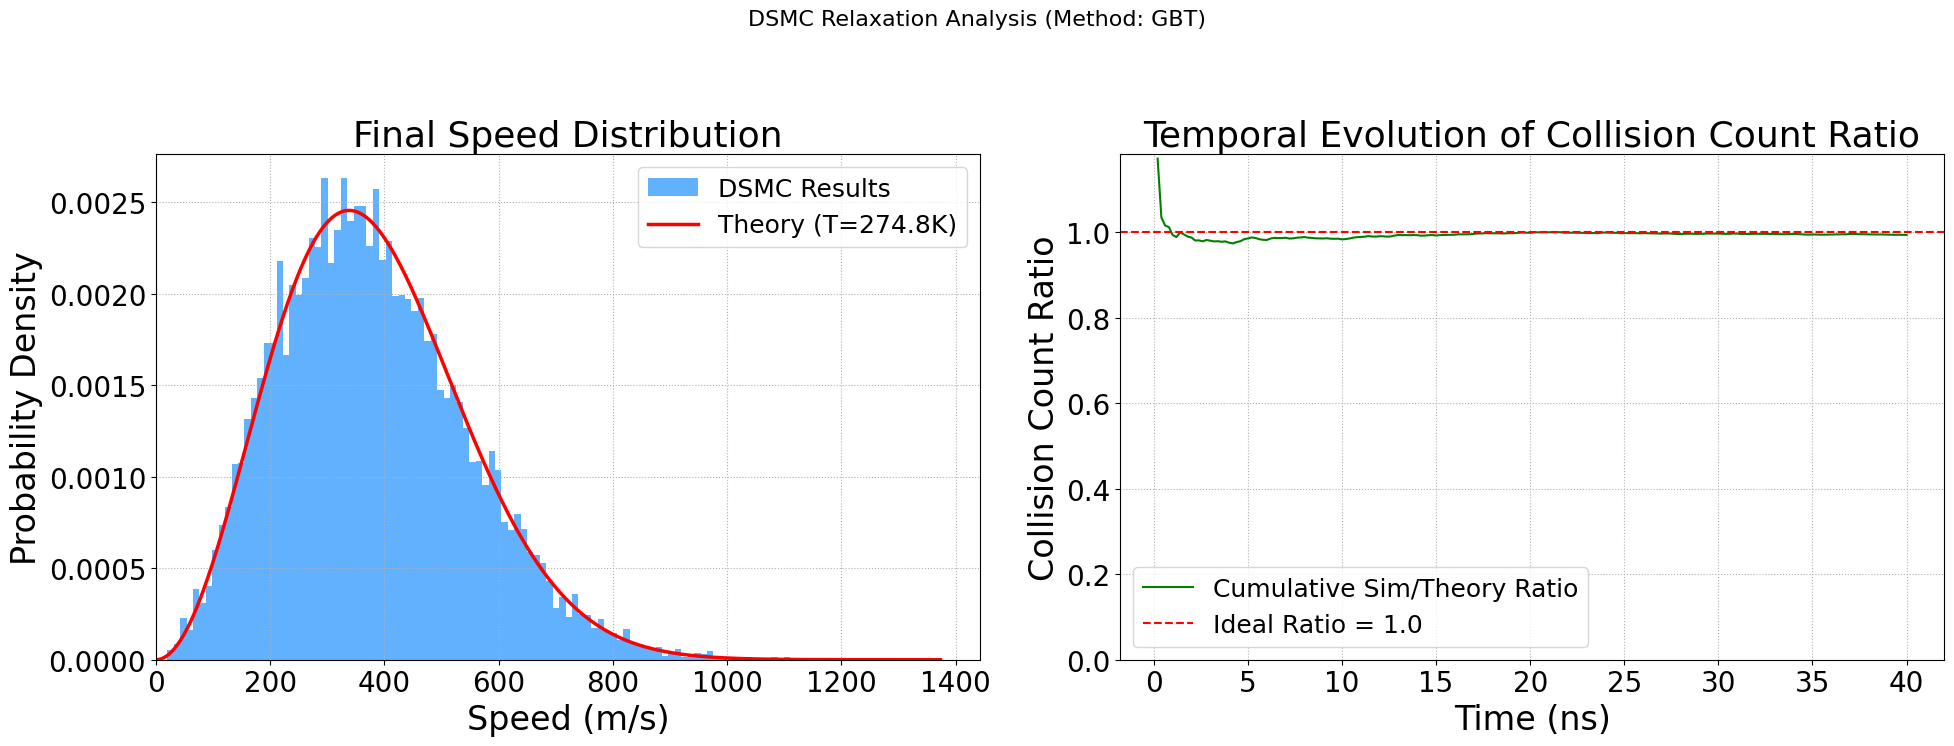

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V9.0 - Final Corrected Code with GBT ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 10
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_INTERVAL = 200

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

# Helper function for GBT fallback, representing an efficient O(N) scheme.
@njit(nopython=True)
def standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
    return n_accepted

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (Simple, Brute-Force O(N^2))
        prob_const = fnum * dt / cell_vol
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 4: # GBT (Generalized Bernoulli Trials)
        N = num_particles_in_cell
        N_sel = N // 3
        if N_sel == 0: N_sel = 1

        if N_sel >= N - 1 or N_sel < 1:
            n_accepted = standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_accepted, sigma_g_max_cell

        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]

        selected_local_indices = all_local_indices[:N_sel]

        mask = np.ones(N, dtype=np.bool_)
        mask[selected_local_indices] = False
        remaining_local_indices = all_local_indices[N_sel:]

        reordered_local_indices = np.concatenate((selected_local_indices, remaining_local_indices))
        reordered_global_indices = indices_in_cell[reordered_local_indices]

        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol

        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)

            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)

            k_k = k_k_const * (N - (i + 1.0))

            collision_prob = k_k * prob_const * sigma_g

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1

        return n_accepted, sigma_g_max_cell

    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=16)

    sampled_speeds = sampled_speeds[sampled_speeds > 0]

    ax1.hist(sampled_speeds, bins=100, density=True, label=f'DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Count Ratio'); ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)
    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)

    MAX_SAMPLES = 100000
    sampled_speeds = np.zeros(MAX_SAMPLES)
    sample_idx = 0

    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i])
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
            if sample_idx < MAX_SAMPLES:
                current_speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
                num_to_add = min(len(current_speeds), MAX_SAMPLES - sample_idx)
                sampled_speeds[sample_idx : sample_idx + num_to_add] = current_speeds[:num_to_add]
                sample_idx += num_to_add

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sample_idx > 0:
        plot_results(sampled_speeds[:sample_idx], final_temp, collision_method_name, time_history, ratio_history)
    else:
        print("\nWarning: No speed data was sampled. The simulation might be too short or sampling parameters are too restrictive.")

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT: ")
        if choice in ['1', '2', '3', '4']:
            run_dsmc_simulation(method_code=int(choice))
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT: 4
--- DSMC Relaxation using method: GBT ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 1000 particles.
Step: 4000/40000 | Total Collisions: 7723
Step: 8000/40000 | Total Collisions: 15654
Step: 12000/40000 | Total Collisions: 23527
Step: 16000/40000 | Total Collisions: 31479
Step: 20000/40000 | Total Collisions: 39527
Step: 24000/40000 | Total Collisions: 47461
Step: 28000/40000 | Total Collisions: 55190
Step: 32000/40000 | Total Collisions: 63093
Step: 36000/40000 | Total Collisions: 70868
Step: 40000/40000 | Total Collisions: 78657

Simulation finished in 121.80 seconds.
Final Equilibrium Temperature: 274.85 K
Total Simulated Collisions: 78657
Total Theoretical Collisions (TCOL): 79119.75
FINAL RATIO (Simulated/Theoretical): 0.9942



Plot saved as DSMC_Analysis_GBT.eps


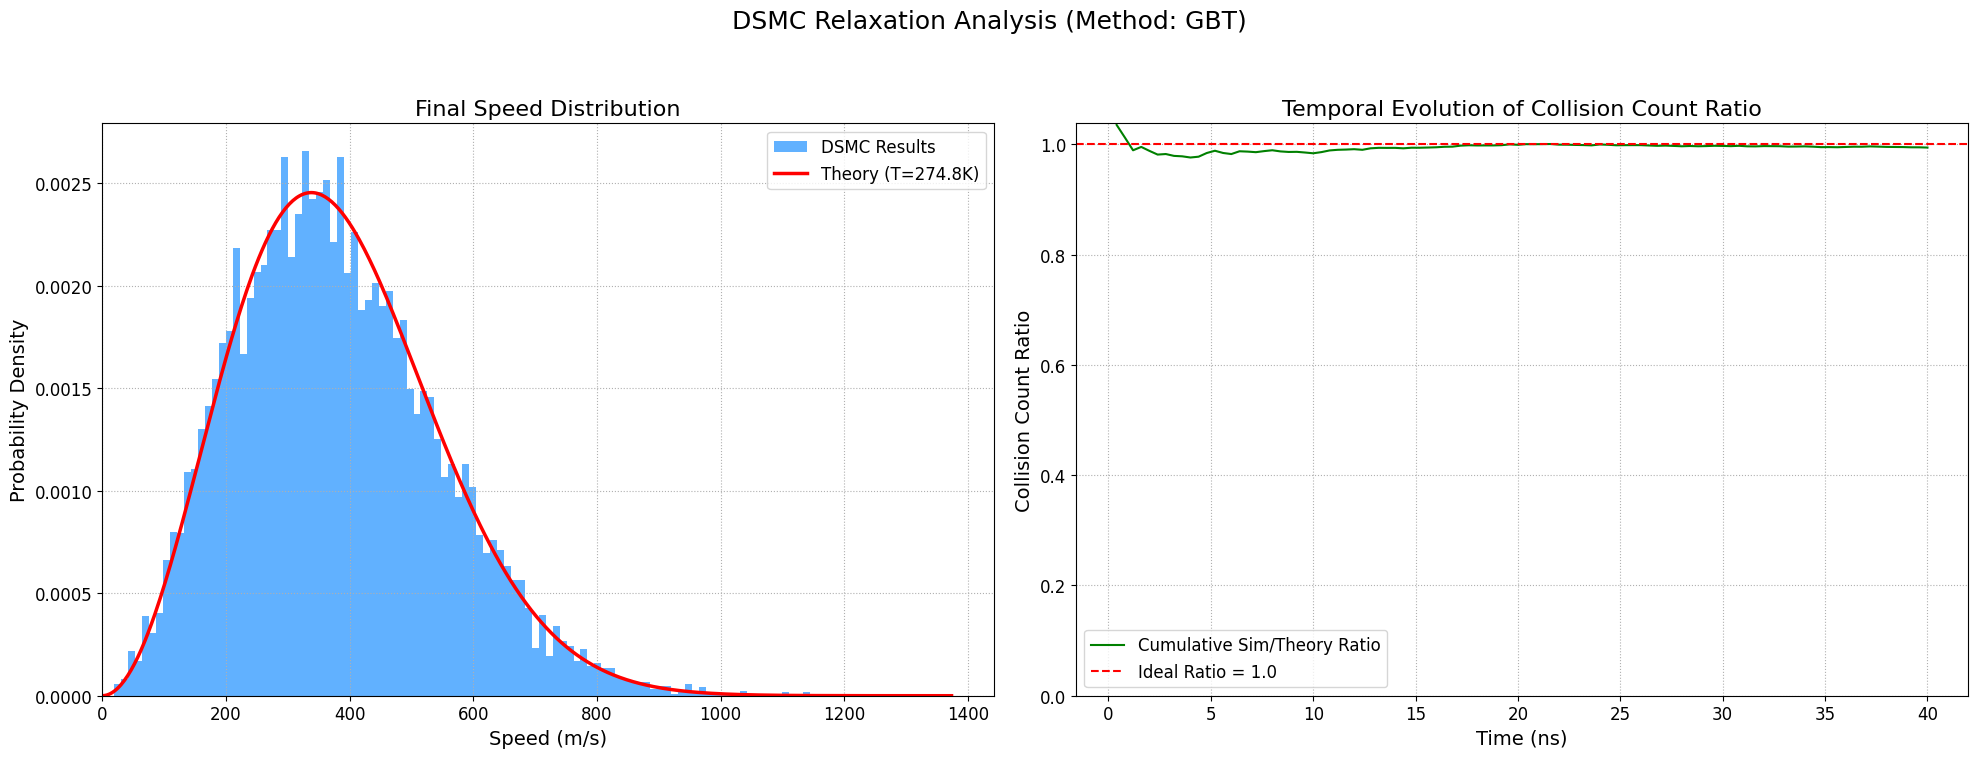

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V10.0 - EPS Output with Larger Fonts ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 10
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_INTERVAL = 400

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
    return n_accepted

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (Simple, Brute-Force O(N^2))
        prob_const = fnum * dt / cell_vol
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = N // 3
        if N_sel == 0: N_sel = 1

        if N_sel >= N - 1 or N_sel < 1:
            n_accepted = standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_accepted, sigma_g_max_cell

        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]

        selected_local_indices = all_local_indices[:N_sel]

        mask = np.ones(N, dtype=np.bool_)
        mask[selected_local_indices] = False
        remaining_local_indices = all_local_indices[N_sel:]

        reordered_local_indices = np.concatenate((selected_local_indices, remaining_local_indices))
        reordered_global_indices = indices_in_cell[reordered_local_indices]

        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol

        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)

            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)

            k_k = k_k_const * (N - (i + 1.0))

            collision_prob = k_k * prob_const * sigma_g

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1

        return n_accepted, sigma_g_max_cell

    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    # Set global font sizes for better readability in publications
    plt.rcParams.update({'font.size': 14,
                         'axes.titlesize': 16,
                         'axes.labelsize': 14,
                         'xtick.labelsize': 12,
                         'ytick.labelsize': 12,
                         'legend.fontsize': 12,
                         'figure.titlesize': 18})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})')

    sampled_speeds = sampled_speeds[sampled_speeds > 0]

    ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)')
    ax1.set_ylabel('Probability Density')
    ax1.set_title('Final Speed Distribution')
    ax1.legend()
    ax1.grid(True, linestyle=':')
    ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Collision Count Ratio')
    ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend()
    ax2.grid(True, linestyle=':')
    ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save the figure as an EPS file
    output_filename = f'DSMC_Analysis_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nPlot saved as {output_filename}")

    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)
    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)

    MAX_SAMPLES = 100000
    sampled_speeds = np.zeros(MAX_SAMPLES)
    sample_idx = 0

    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i])
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
            if sample_idx < MAX_SAMPLES:
                current_speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
                num_to_add = min(len(current_speeds), MAX_SAMPLES - sample_idx)
                sampled_speeds[sample_idx : sample_idx + num_to_add] = current_speeds[:num_to_add]
                sample_idx += num_to_add

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sample_idx > 0:
        plot_results(sampled_speeds[:sample_idx], final_temp, collision_method_name, time_history, ratio_history)
    else:
        print("\nWarning: No speed data was sampled. The simulation might be too short or sampling parameters are too restrictive.")

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT: ")
        if choice in ['1', '2', '3', '4']:
            run_dsmc_simulation(method_code=int(choice))
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT: 4
Enter the N_sel fraction for GBT (e.g., 0.33 for N/3): 1
Invalid fraction. Using default value of 0.33.
--- DSMC Relaxation using method: GBT ---
    GBT N_sel fraction set to: 0.33
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 300 particles.
Step: 4000/40000 | Total Collisions: 2418
Step: 8000/40000 | Total Collisions: 4819
Step: 12000/40000 | Total Collisions: 7248
Step: 16000/40000 | Total Collisions: 9496
Step: 20000/40000 | Total Collisions: 11975
Step: 24000/40000 | Total Collisions: 14325
Step: 28000/40000 | Total Collisions: 16648
Step: 32000/40000 | Total Collisions: 19082
Step: 36000/40000 | Total Collisions: 21375
Step: 40000/40000 | Total Collisions: 23732

Simulation finished in 119.49 seconds.
Final Equilibrium Temperature: 272.84 K
Total Simulated Collisions: 23732
Total Theoretical Collisions (TCOL): 23649.08
FINAL RATIO (Simulated/Theoretical): 1.0035



Plot saved as DSMC_Analysis_GBT.eps


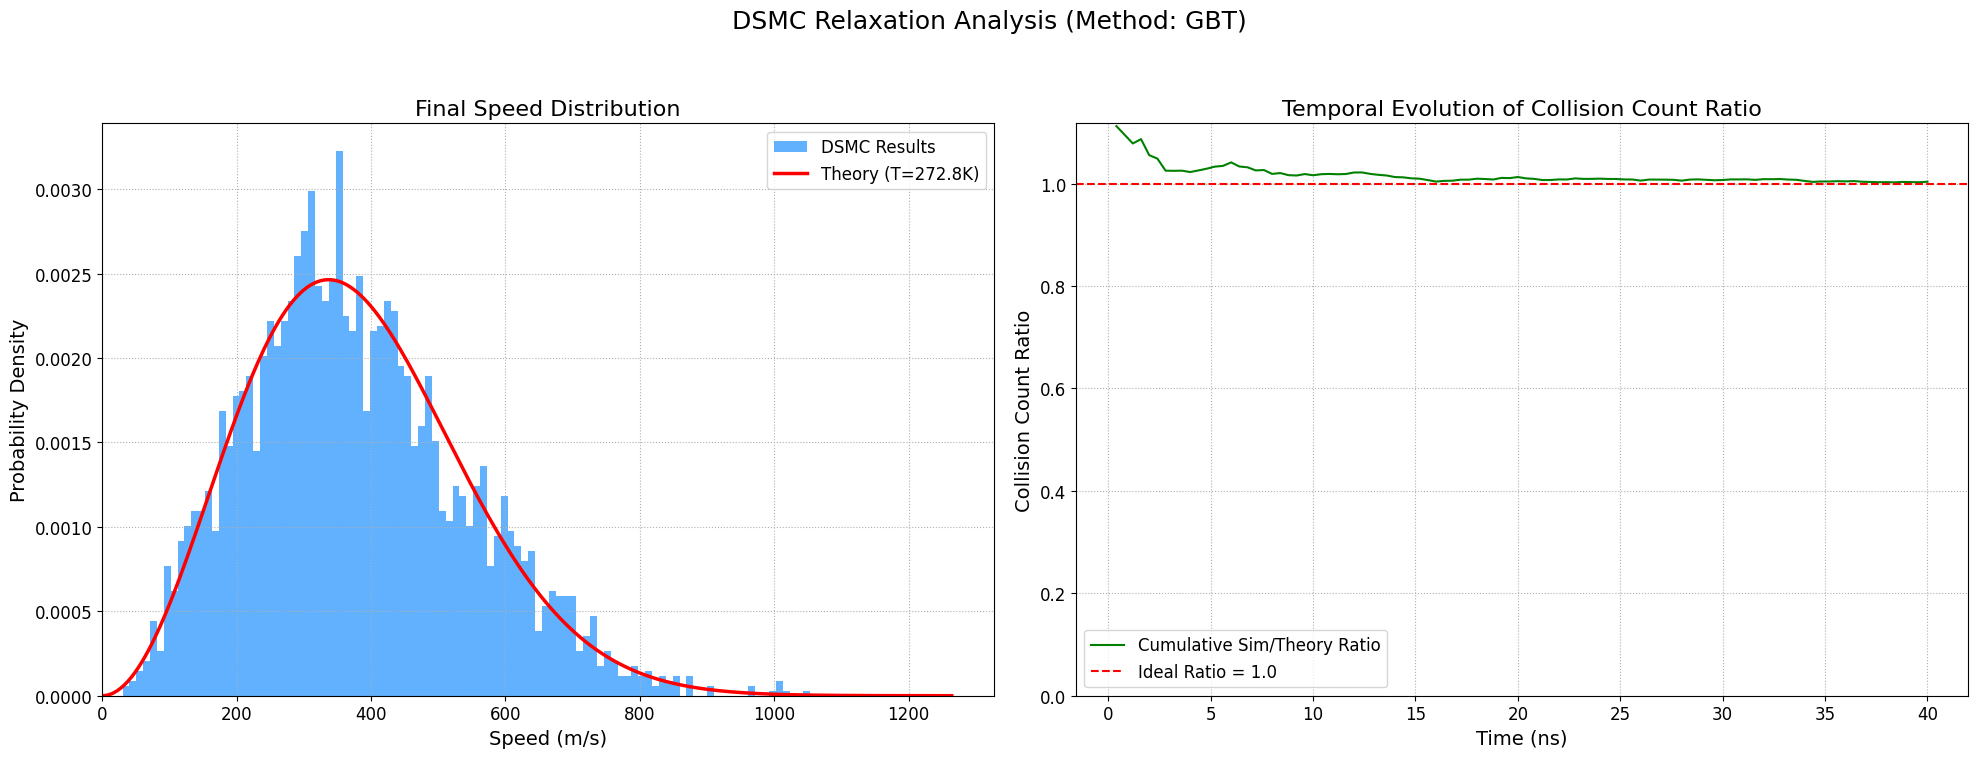

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V11.0 - User Input for N_sel ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 3
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_INTERVAL = 400

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
    return n_accepted

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (Simple, Brute-Force O(N^2))
        prob_const = fnum * dt / cell_vol
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)

        if N_sel >= N - 1 or N_sel < 1:
            n_accepted = standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_accepted, sigma_g_max_cell

        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]

        selected_local_indices = all_local_indices[:N_sel]

        mask = np.ones(N, dtype=np.bool_)
        mask[selected_local_indices] = False
        remaining_local_indices = all_local_indices[N_sel:]

        reordered_local_indices = np.concatenate((selected_local_indices, remaining_local_indices))
        reordered_global_indices = indices_in_cell[reordered_local_indices]

        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol

        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)

            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)

            k_k = k_k_const * (N - (i + 1.0))

            collision_prob = k_k * prob_const * sigma_g

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1

        return n_accepted, sigma_g_max_cell

    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    plt.rcParams.update({'font.size': 14,
                         'axes.titlesize': 16,
                         'axes.labelsize': 14,
                         'xtick.labelsize': 12,
                         'ytick.labelsize': 12,
                         'legend.fontsize': 12,
                         'figure.titlesize': 18})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})')

    sampled_speeds = sampled_speeds[sampled_speeds > 0]

    ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)')
    ax1.set_ylabel('Probability Density')
    ax1.set_title('Final Speed Distribution')
    ax1.legend()
    ax1.grid(True, linestyle=':')
    ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Collision Count Ratio')
    ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend()
    ax2.grid(True, linestyle=':')
    ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_filename = f'DSMC_Analysis_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nPlot saved as {output_filename}")

    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")
    if method_code == 4:
        print(f"    GBT N_sel fraction set to: {n_sel_fraction:.2f}")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)
    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)

    MAX_SAMPLES = 100000
    sampled_speeds = np.zeros(MAX_SAMPLES)
    sample_idx = 0

    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i], n_sel_fraction)
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
            if sample_idx < MAX_SAMPLES:
                current_speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
                num_to_add = min(len(current_speeds), MAX_SAMPLES - sample_idx)
                sampled_speeds[sample_idx : sample_idx + num_to_add] = current_speeds[:num_to_add]
                sample_idx += num_to_add

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sample_idx > 0:
        plot_results(sampled_speeds[:sample_idx], final_temp, collision_method_name, time_history, ratio_history)
    else:
        print("\nWarning: No speed data was sampled. The simulation might be too short or sampling parameters are too restrictive.")

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT: ")
        if choice in ['1', '2', '3', '4']:
            n_sel_fraction = 0.5 # Default value for non-GBT methods
            if choice == '4':
                try:
                    n_sel_input = float(input("Enter the N_sel fraction for GBT (e.g., 0.33 for N/3): "))
                    if 0 < n_sel_input < 1:
                        n_sel_fraction = n_sel_input
                    else:
                        print("Invalid fraction. Using default value of 0.33.")
                        n_sel_fraction = 0.33
                except ValueError:
                    print("Invalid input. Using default value of 0.33.")
                    n_sel_fraction = 0.33

            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=n_sel_fraction)
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT: 5
--- DSMC Relaxation using method: SSBT ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 500 particles.
Step: 4000/40000 | Total Collisions: 4005
Step: 8000/40000 | Total Collisions: 7976
Step: 12000/40000 | Total Collisions: 11994
Step: 16000/40000 | Total Collisions: 15934
Step: 20000/40000 | Total Collisions: 19837
Step: 24000/40000 | Total Collisions: 23808
Step: 28000/40000 | Total Collisions: 27804
Step: 32000/40000 | Total Collisions: 31799
Step: 36000/40000 | Total Collisions: 35826
Step: 40000/40000 | Total Collisions: 39877

Simulation finished in 127.10 seconds.
Final Equilibrium Temperature: 282.18 K
Total Simulated Collisions: 39877
Total Theoretical Collisions (TCOL): 40084.18
FINAL RATIO (Simulated/Theoretical): 0.9948



Plot saved as DSMC_Analysis_SSBT.eps


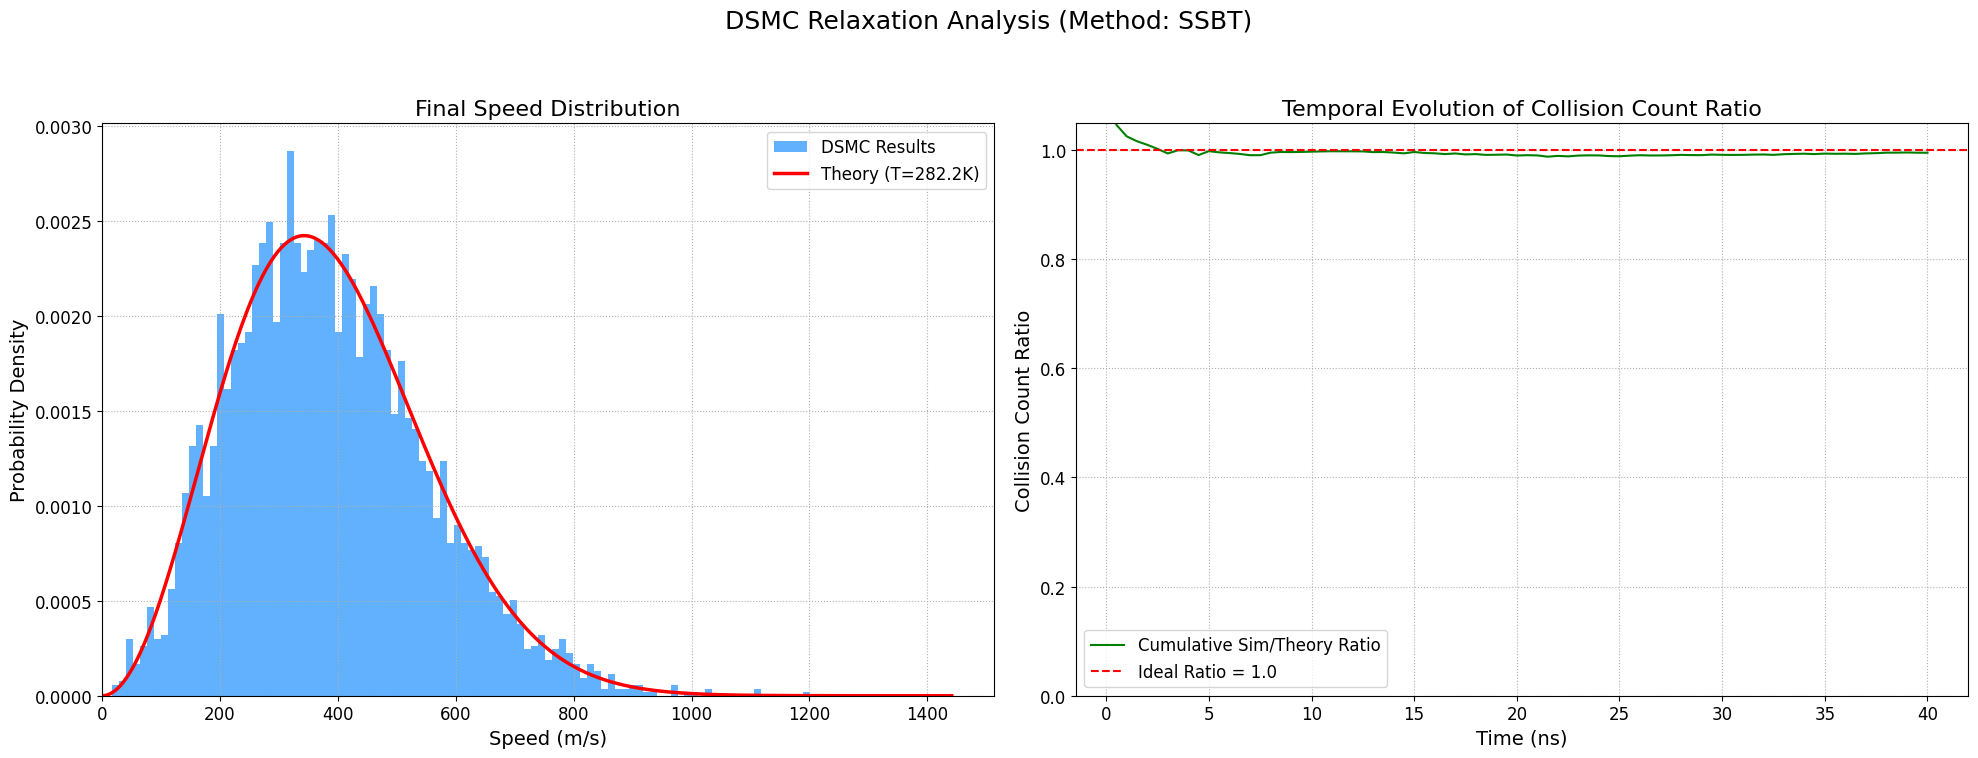

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V13.0 - Corrected SSBT Implementation ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 5
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_INTERVAL = 500

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
    return n_accepted

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (Simple, Brute-Force O(N^2))
        prob_const = fnum * dt / cell_vol
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)

        if N_sel >= N - 1 or N_sel < 1:
            n_accepted = standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_accepted, sigma_g_max_cell

        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]

        selected_local_indices = all_local_indices[:N_sel]

        mask = np.ones(N, dtype=np.bool_)
        mask[selected_local_indices] = False
        remaining_local_indices = all_local_indices[N_sel:]

        reordered_local_indices = np.concatenate((selected_local_indices, remaining_local_indices))
        reordered_global_indices = indices_in_cell[reordered_local_indices]

        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol

        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)

            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)

            k_k = k_k_const * (N - (i + 1.0))

            collision_prob = k_k * prob_const * sigma_g

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1

        return n_accepted, sigma_g_max_cell

    elif method == 5: # SSBT (Statistical Simple Bernoulli Trial) - CORRECTED
        prob_const = fnum * dt / cell_vol
        # The crucial multiplier from Eq. (4.27)
        multiplier = (num_particles_in_cell - 1.0) / 2.0

        # Loop i from 1 to N
        for i_local in range(num_particles_in_cell):
            p1_idx = indices_in_cell[i_local]

            # Select second particle randomly and re-select if it's the same
            j_local = rng_state.integers(0, num_particles_in_cell)
            while j_local == i_local:
                j_local = rng_state.integers(0, num_particles_in_cell)

            p2_idx = indices_in_cell[j_local]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)

            # Corrected collision probability using the multiplier
            collision_prob = multiplier * prob_const * sigma_g

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1

        return n_accepted, sigma_g_max_cell

    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    plt.rcParams.update({'font.size': 14,
                         'axes.titlesize': 16,
                         'axes.labelsize': 14,
                         'xtick.labelsize': 12,
                         'ytick.labelsize': 12,
                         'legend.fontsize': 12,
                         'figure.titlesize': 18})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})')

    sampled_speeds = sampled_speeds[sampled_speeds > 0]

    ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)')
    ax1.set_ylabel('Probability Density')
    ax1.set_title('Final Speed Distribution')
    ax1.legend()
    ax1.grid(True, linestyle=':')
    ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Collision Count Ratio')
    ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend()
    ax2.grid(True, linestyle=':')
    ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_filename = f'DSMC_Analysis_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nPlot saved as {output_filename}")

    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT', 5: 'SSBT'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")
    if method_code == 4:
        print(f"    GBT N_sel fraction set to: {n_sel_fraction:.2f}")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)
    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)

    MAX_SAMPLES = 100000
    sampled_speeds = np.zeros(MAX_SAMPLES)
    sample_idx = 0

    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i], n_sel_fraction)
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
            if sample_idx < MAX_SAMPLES:
                current_speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
                num_to_add = min(len(current_speeds), MAX_SAMPLES - sample_idx)
                sampled_speeds[sample_idx : sample_idx + num_to_add] = current_speeds[:num_to_add]
                sample_idx += num_to_add

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sample_idx > 0:
        plot_results(sampled_speeds[:sample_idx], final_temp, collision_method_name, time_history, ratio_history)
    else:
        print("\nWarning: No speed data was sampled. The simulation might be too short or sampling parameters are too restrictive.")

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT: ")
        if choice in ['1', '2', '3', '4', '5']:
            n_sel_fraction = 0.5 # Default value
            if choice == '4':
                try:
                    n_sel_input = float(input("Enter the N_sel fraction for GBT (e.g., 0.33 for N/3): "))
                    if 0 < n_sel_input < 1:
                        n_sel_fraction = n_sel_input
                    else:
                        print("Invalid fraction. Using default value of 0.33.")
                        n_sel_fraction = 0.33
                except ValueError:
                    print("Invalid input. Using default value of 0.33.")
                    n_sel_fraction = 0.33

            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=n_sel_fraction)
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [7] SGBT: 7
Enter the N_sel fraction for SGBT (e.g., 0.33 for N/3): 0.5
--- DSMC Relaxation using method: SGBT ---
    N_sel fraction set to: 0.50
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 500 particles.
Step: 4000/40000 | Total Collisions: 4040
Step: 8000/40000 | Total Collisions: 8102
Step: 12000/40000 | Total Collisions: 12036
Step: 16000/40000 | Total Collisions: 16003
Step: 20000/40000 | Total Collisions: 20052
Step: 24000/40000 | Total Collisions: 24043
Step: 28000/40000 | Total Collisions: 28136
Step: 32000/40000 | Total Collisions: 32104
Step: 36000/40000 | Total Collisions: 36139
Step: 40000/40000 | Total Collisions: 40126

Simulation finished in 129.62 seconds.
Final Equilibrium Temperature: 282.18 K
Total Simulated Collisions: 40126
Total Theoretical Collisions (TCOL): 40084.18
FINAL RATIO (Simulated/Theoretical): 1.0010



Plot saved as DSMC_Analysis_SGBT.eps


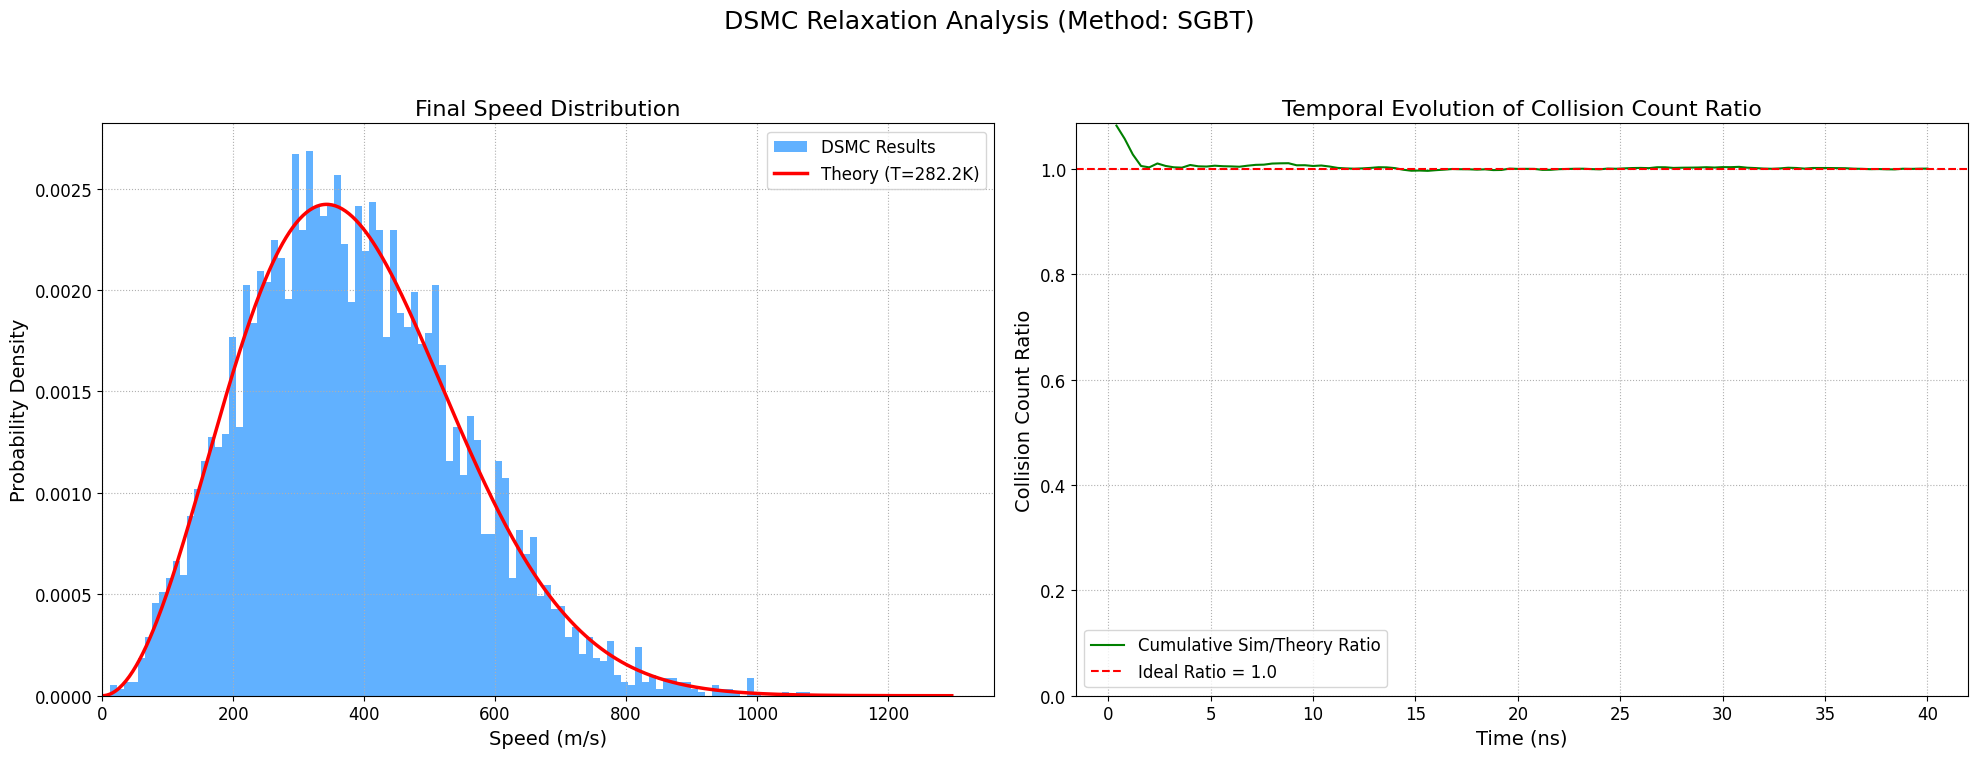

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V13.0 - Added SGBT Method ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 5
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_INTERVAL = 400

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
    return n_accepted

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction, duplicate_check_array):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (Simple, Brute-Force O(N^2))
        prob_const = fnum * dt / cell_vol
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)

        if N_sel >= N - 1 or N_sel < 1:
            n_accepted = standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_accepted, sigma_g_max_cell

        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]

        selected_local_indices = all_local_indices[:N_sel]

        mask = np.ones(N, dtype=np.bool_)
        mask[selected_local_indices] = False
        remaining_local_indices = all_local_indices[N_sel:]

        reordered_local_indices = np.concatenate((selected_local_indices, remaining_local_indices))
        reordered_global_indices = indices_in_cell[reordered_local_indices]

        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol

        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)

            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)
            k_k = k_k_const * (N - (i + 1.0))
            collision_prob = k_k * prob_const * sigma_g

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1

        return n_accepted, sigma_g_max_cell

    elif method == 5: # SSBT
        prob_const = fnum * dt / cell_vol
        multiplier = (num_particles_in_cell - 1.0) / 2.0

        for i_local in range(num_particles_in_cell):
            p1_idx = indices_in_cell[i_local]

            j_local = rng_state.integers(0, num_particles_in_cell)
            while j_local == i_local:
                j_local = rng_state.integers(0, num_particles_in_cell)

            p2_idx = indices_in_cell[j_local]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1

        return n_accepted, sigma_g_max_cell

    elif method == 7: # SGBT (Symmetrized and Generalized Bernoulli Trials)
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)

        if N_sel >= N or N_sel < 1:
            n_accepted = standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_accepted, sigma_g_max_cell

        # Particle shuffling
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]

        reordered_global_indices = indices_in_cell[all_local_indices]

        # Probability calculation from Eq. (4.35)
        prob_const = fnum * dt / cell_vol
        multiplier = (N * (N - 1.0)) / (N_sel * 2.0)

        # Loop i from 1 to N_sel
        for i in range(N_sel):
            p1_idx = reordered_global_indices[i]

            # Select second particle j randomly from the N particles, ensuring j != i
            j = rng_state.integers(0, N)
            while j == i:
                j = rng_state.integers(0, N)

            p2_idx = reordered_global_indices[j]

            # Duplicate collision check
            if duplicate_check_array[p1_idx] == p2_idx:
                continue

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    # Update duplicate check array
                    duplicate_check_array[p1_idx] = p2_idx
                    duplicate_check_array[p2_idx] = p1_idx

        return n_accepted, sigma_g_max_cell

    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    plt.rcParams.update({'font.size': 14,
                         'axes.titlesize': 16,
                         'axes.labelsize': 14,
                         'xtick.labelsize': 12,
                         'ytick.labelsize': 12,
                         'legend.fontsize': 12,
                         'figure.titlesize': 18})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})')

    sampled_speeds = sampled_speeds[sampled_speeds > 0]

    ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)')
    ax1.set_ylabel('Probability Density')
    ax1.set_title('Final Speed Distribution')
    ax1.legend()
    ax1.grid(True, linestyle=':')
    ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Collision Count Ratio')
    ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend()
    ax2.grid(True, linestyle=':')
    ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_filename = f'DSMC_Analysis_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nPlot saved as {output_filename}")

    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT', 5: 'SSBT', 7: 'SGBT'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")
    if method_code in [4, 7]:
        print(f"    N_sel fraction set to: {n_sel_fraction:.2f}")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)
    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)

    MAX_SAMPLES = 100000
    sampled_speeds = np.zeros(MAX_SAMPLES)
    sample_idx = 0

    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        # Array to prevent duplicate collisions in one timestep for SGBT
        duplicate_check_array = np.full(TOTAL_PARTICLES_SIM, -1, dtype=np.int64)

        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i], n_sel_fraction, duplicate_check_array)
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
            if sample_idx < MAX_SAMPLES:
                current_speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
                num_to_add = min(len(current_speeds), MAX_SAMPLES - sample_idx)
                sampled_speeds[sample_idx : sample_idx + num_to_add] = current_speeds[:num_to_add]
                sample_idx += num_to_add

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sample_idx > 0:
        plot_results(sampled_speeds[:sample_idx], final_temp, collision_method_name, time_history, ratio_history)
    else:
        print("\nWarning: No speed data was sampled. The simulation might be too short or sampling parameters are too restrictive.")

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [7] SGBT: ")
        if choice in ['1', '2', '3', '4', '5', '7']:
            n_sel_fraction = 0.5 # Default value
            if choice in ['4', '7']:
                try:
                    n_sel_input = float(input(f"Enter the N_sel fraction for { {4:'GBT', 7:'SGBT'}[int(choice)] } (e.g., 0.33 for N/3): "))
                    if 0 < n_sel_input < 1:
                        n_sel_fraction = n_sel_input
                    else:
                        print("Invalid fraction. Using default value of 0.33.")
                        n_sel_fraction = 0.33
                except ValueError:
                    print("Invalid input. Using default value of 0.33.")
                    n_sel_fraction = 0.33

            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=n_sel_fraction)
            break
        else:
            print("Invalid input.")

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V14.0 - Added MFS Method ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 10
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-7
SAMPLING_INTERVAL = 5000

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
    return n_accepted

@njit(nopython=True)
def perform_collisions(method, particles, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction, duplicate_check_array):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (Simple, Brute-Force O(N^2))
        prob_const = fnum * dt / cell_vol
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                distance = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)

        if N_sel >= N - 1 or N_sel < 1:
            n_accepted = standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_accepted, sigma_g_max_cell

        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]

        selected_local_indices = all_local_indices[:N_sel]

        mask = np.ones(N, dtype=np.bool_)
        mask[selected_local_indices] = False
        remaining_local_indices = all_local_indices[N_sel:]

        reordered_local_indices = np.concatenate((selected_local_indices, remaining_local_indices))
        reordered_global_indices = indices_in_cell[reordered_local_indices]

        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol

        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)

            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)
            k_k = k_k_const * (N - (i + 1.0))
            collision_prob = k_k * prob_const * sigma_g

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1

        return n_accepted, sigma_g_max_cell

    elif method == 5: # SSBT
        prob_const = fnum * dt / cell_vol
        multiplier = (num_particles_in_cell - 1.0) / 2.0

        for i_local in range(num_particles_in_cell):
            p1_idx = indices_in_cell[i_local]

            j_local = rng_state.integers(0, num_particles_in_cell)
            while j_local == i_local:
                j_local = rng_state.integers(0, num_particles_in_cell)

            p2_idx = indices_in_cell[j_local]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1

        return n_accepted, sigma_g_max_cell

    elif method == 7: # SGBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)

        if N_sel >= N or N_sel < 1:
            n_accepted = standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_accepted, sigma_g_max_cell

        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]

        reordered_global_indices = indices_in_cell[all_local_indices]

        prob_const = fnum * dt / cell_vol
        multiplier = (N * (N - 1.0)) / (N_sel * 2.0)

        for i in range(N_sel):
            p1_idx = reordered_global_indices[i]

            j = rng_state.integers(0, N)
            while j == i:
                j = rng_state.integers(0, N)

            p2_idx = reordered_global_indices[j]

            if duplicate_check_array[p1_idx] == p2_idx:
                continue

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue

            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g

            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    duplicate_check_array[p1_idx] = p2_idx
                    duplicate_check_array[p2_idx] = p1_idx

        return n_accepted, sigma_g_max_cell

    elif method == 8: # MFS (Majorant Frequency Scheme)
        cell_time = 0.0
        while cell_time < dt:
            num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)

            if num_pairs_float < 1 or sigma_g_max_cell < 1e-20:
                break

            # Eq. (31) for Majorant Frequency
            nu_max = num_pairs_float * fnum * sigma_g_max_cell / cell_vol
            if nu_max <= 0:
                break

            # Eq. (30) for time to next collision
            delta_t_c = -np.log(1.0 - rng_state.random()) / nu_max # Use 1.0-random to avoid log(0)

            cell_time += delta_t_c

            if cell_time < dt:
                # Select a random pair
                p1_idx_local = rng_state.integers(0, num_particles_in_cell)
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                while p1_idx_local == p2_idx_local:
                    p2_idx_local = rng_state.integers(0, num_particles_in_cell)

                p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]

                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))

                # Update max collision product
                if sigma_g_current > sigma_g_max_cell:
                    sigma_g_max_cell = sigma_g_current

                # Acceptance-Rejection test
                if rng_state.random() < sigma_g_current / sigma_g_max_cell:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1

        return n_accepted, sigma_g_max_cell

    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    plt.rcParams.update({'font.size': 14,
                         'axes.titlesize': 16,
                         'axes.labelsize': 14,
                         'xtick.labelsize': 12,
                         'ytick.labelsize': 12,
                         'legend.fontsize': 12,
                         'figure.titlesize': 18})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})')

    sampled_speeds = sampled_speeds[sampled_speeds > 0]

    ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)')
    ax1.set_ylabel('Probability Density')
    ax1.set_title('Final Speed Distribution')
    ax1.legend()
    ax1.grid(True, linestyle=':')
    ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Collision Count Ratio')
    ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend()
    ax2.grid(True, linestyle=':')
    ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_filename = f'DSMC_Analysis_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nPlot saved as {output_filename}")

    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT', 5: 'SSBT', 7: 'SGBT', 8: 'MFS'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")
    if method_code in [4, 7]:
        print(f"    N_sel fraction set to: {n_sel_fraction:.2f}")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)
    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)

    MAX_SAMPLES = 100000
    sampled_speeds = np.zeros(MAX_SAMPLES)
    sample_idx = 0

    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        duplicate_check_array = np.full(TOTAL_PARTICLES_SIM, -1, dtype=np.int64)

        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(method_code, particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state, sigma_g_max[i], n_sel_fraction, duplicate_check_array)
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
            if sample_idx < MAX_SAMPLES:
                current_speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
                num_to_add = min(len(current_speeds), MAX_SAMPLES - sample_idx)
                sampled_speeds[sample_idx : sample_idx + num_to_add] = current_speeds[:num_to_add]
                sample_idx += num_to_add

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sample_idx > 0:
        plot_results(sampled_speeds[:sample_idx], final_temp, collision_method_name, time_history, ratio_history)
    else:
        print("\nWarning: No speed data was sampled. The simulation might be too short or sampling parameters are too restrictive.")

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [7] SGBT, [8] MFS: ")
        if choice in ['1', '2', '3', '4', '5', '7', '8']:
            n_sel_fraction = 0.5 # Default value
            if choice in ['4', '7']:
                try:
                    n_sel_input = float(input(f"Enter the N_sel fraction for { {4:'GBT', 7:'SGBT'}[int(choice)] } (e.g., 0.33 for N/3): "))
                    if 0 < n_sel_input < 1:
                        n_sel_fraction = n_sel_input
                    else:
                        print("Invalid fraction. Using default value of 0.33.")
                        n_sel_fraction = 0.33
                except ValueError:
                    print("Invalid input. Using default value of 0.33.")
                    n_sel_fraction = 0.33

            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=n_sel_fraction)
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


KeyboardInterrupt: Interrupted by user

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [7] SGBT, [8] MFS, [9] NN: 9
--- DSMC Relaxation using method: NN ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 500 particles.
Step: 40000/400000 | Total Collisions: 26214
Step: 80000/400000 | Total Collisions: 65623
Step: 120000/400000 | Total Collisions: 105451
Step: 160000/400000 | Total Collisions: 145442
Step: 200000/400000 | Total Collisions: 185601
Step: 240000/400000 | Total Collisions: 225364
Step: 280000/400000 | Total Collisions: 265628
Step: 320000/400000 | Total Collisions: 305615
Step: 360000/400000 | Total Collisions: 345572
Step: 400000/400000 | Total Collisions: 385394

Simulation finished in 850.71 seconds.
Final Equilibrium Temperature: 282.18 K
Total Simulated Collisions: 385394
Total Theoretical Collisions (TCOL): 400841.81
FINAL RATIO (Simulated/Theoretical): 0.9615



Plot saved as DSMC_Analysis_NN.eps


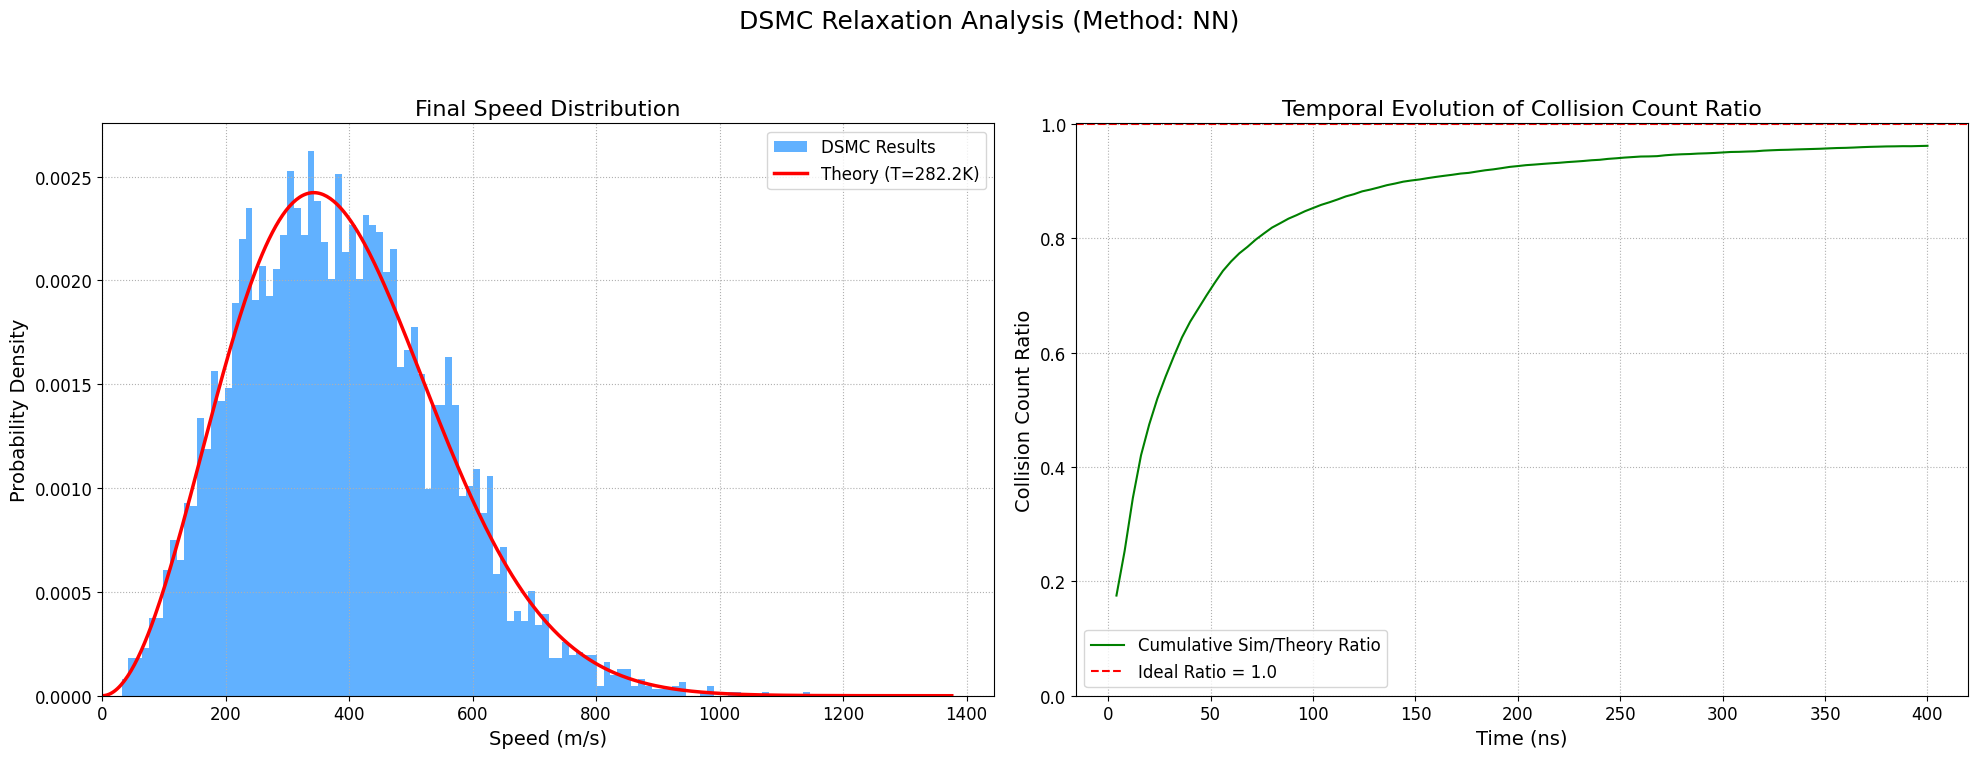

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V16.0 - Optimized NN Method ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 5
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 40.0e-8
SAMPLING_INTERVAL = 4000

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
    return n_accepted

@njit(nopython=True)
def perform_collisions(method, particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction, duplicate_check_array):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (Simple, Brute-Force O(N^2))
        prob_const = fnum * dt / cell_vol
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                distance = min(delta_x, lx - delta_x)
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local: p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell: sigma_g_max_cell = sigma_g_current
            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N - 1 or N_sel < 1:
            n_accepted = standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_accepted, sigma_g_max_cell
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        selected_local_indices = all_local_indices[:N_sel]
        mask = np.ones(N, dtype=np.bool_)
        mask[selected_local_indices] = False
        remaining_local_indices = all_local_indices[N_sel:]
        reordered_local_indices = np.concatenate((selected_local_indices, remaining_local_indices))
        reordered_global_indices = indices_in_cell[reordered_local_indices]
        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol
        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)
            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            k_k = k_k_const * (N - (i + 1.0))
            collision_prob = k_k * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 5: # SSBT
        prob_const = fnum * dt / cell_vol
        multiplier = (num_particles_in_cell - 1.0) / 2.0
        for i_local in range(num_particles_in_cell):
            p1_idx = indices_in_cell[i_local]
            j_local = rng_state.integers(0, num_particles_in_cell)
            while j_local == i_local:
                j_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx = indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 7: # SGBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N or N_sel < 1:
            n_accepted = standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_accepted, sigma_g_max_cell
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        prob_const = fnum * dt / cell_vol
        multiplier = (N * (N - 1.0)) / (N_sel * 2.0)
        for i in range(N_sel):
            p1_idx = reordered_global_indices[i]
            j = rng_state.integers(0, N)
            while j == i:
                j = rng_state.integers(0, N)
            p2_idx = reordered_global_indices[j]
            if duplicate_check_array[p1_idx] == p2_idx:
                continue
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    duplicate_check_array[p1_idx] = p2_idx
                    duplicate_check_array[p2_idx] = p1_idx
        return n_accepted, sigma_g_max_cell

    elif method == 8: # MFS
        cell_time = 0.0
        while cell_time < dt:
            num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
            if num_pairs_float < 1 or sigma_g_max_cell < 1e-20:
                break
            nu_max = num_pairs_float * fnum * sigma_g_max_cell / cell_vol
            if nu_max <= 0:
                break
            delta_t_c = -np.log(1.0 - rng_state.random()) / nu_max
            cell_time += delta_t_c
            if cell_time < dt:
                p1_idx_local = rng_state.integers(0, num_particles_in_cell)
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                while p1_idx_local == p2_idx_local:
                    p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
                if sigma_g_current > sigma_g_max_cell:
                    sigma_g_max_cell = sigma_g_current
                if rng_state.random() < sigma_g_current / sigma_g_max_cell:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 9: # NN (Nearest Neighbor) - OPTIMIZED
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell < 1e-20: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())

        if num_pairs_to_select == 0:
            return 0, sigma_g_max_cell

        # --- Optimization: Pre-calculate all nearest neighbors once ---
        N = num_particles_in_cell
        cell_positions = particles[indices_in_cell, 0]
        dist_matrix = np.full((N, N), np.finfo(np.float64).max, dtype=np.float64)

        for i in range(N):
            for j in range(i + 1, N):
                delta_x = np.abs(cell_positions[i] - cell_positions[j])
                dist = min(delta_x, lx - delta_x)
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist

        # nearest_neighbor_map[i] will give the local index of the nearest neighbor to particle i
        nearest_neighbor_map = np.argmin(dist_matrix, axis=1)
        # --- End of Optimization ---

        for _ in range(num_pairs_to_select):
            # Select first particle randomly
            p1_local_idx = rng_state.integers(0, N)

            # Find its nearest neighbor using the pre-calculated map
            p2_local_idx = nearest_neighbor_map[p1_local_idx]

            p1_idx, p2_idx = indices_in_cell[p1_local_idx], indices_in_cell[p2_local_idx]

            # Perform collision check on the (i, j) pair
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current

            if sigma_g_max_cell > 1e-20 and rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1

        return n_accepted, sigma_g_max_cell

    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    plt.rcParams.update({'font.size': 14,
                         'axes.titlesize': 16,
                         'axes.labelsize': 14,
                         'xtick.labelsize': 12,
                         'ytick.labelsize': 12,
                         'legend.fontsize': 12,
                         'figure.titlesize': 18})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})')

    sampled_speeds = sampled_speeds[sampled_speeds > 0]

    ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)')
    ax1.set_ylabel('Probability Density')
    ax1.set_title('Final Speed Distribution')
    ax1.legend()
    ax1.grid(True, linestyle=':')
    ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Collision Count Ratio')
    ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend()
    ax2.grid(True, linestyle=':')
    ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_filename = f'DSMC_Analysis_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nPlot saved as {output_filename}")

    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT', 5: 'SSBT', 7: 'SGBT', 8: 'MFS', 9: 'NN'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")
    if method_code in [4, 7]:
        print(f"    N_sel fraction set to: {n_sel_fraction:.2f}")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)
    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)

    MAX_SAMPLES = 100000
    sampled_speeds = np.zeros(MAX_SAMPLES)
    sample_idx = 0

    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        duplicate_check_array = np.full(TOTAL_PARTICLES_SIM, -1, dtype=np.int64)

        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(
                method_code, particles, LX, indices_in_cell_i,
                CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state,
                sigma_g_max[i], n_sel_fraction, duplicate_check_array
            )
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
            if sample_idx < MAX_SAMPLES:
                current_speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
                num_to_add = min(len(current_speeds), MAX_SAMPLES - sample_idx)
                sampled_speeds[sample_idx : sample_idx + num_to_add] = current_speeds[:num_to_add]
                sample_idx += num_to_add

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sample_idx > 0:
        plot_results(sampled_speeds[:sample_idx], final_temp, collision_method_name, time_history, ratio_history)
    else:
        print("\nWarning: No speed data was sampled. The simulation might be too short or sampling parameters are too restrictive.")

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [7] SGBT, [8] MFS, [9] NN: ")
        if choice in ['1', '2', '3', '4', '5', '7', '8', '9']:
            n_sel_fraction = 0.5 # Default value
            if choice in ['4', '7']:
                try:
                    n_sel_input = float(input(f"Enter the N_sel fraction for { {4:'GBT', 7:'SGBT'}[int(choice)] } (e.g., 0.33 for N/3): "))
                    if 0 < n_sel_input < 1:
                        n_sel_fraction = n_sel_input
                    else:
                        print("Invalid fraction. Using default value of 0.33.")
                        n_sel_fraction = 0.33
                except ValueError:
                    print("Invalid input. Using default value of 0.33.")
                    n_sel_fraction = 0.33

            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=n_sel_fraction)
            break
        else:
            print("Invalid input.")

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V17.0 - Sophisticated NTC and NN ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 1000
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# This conceptual volume is used to correctly calculate FNUM
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_INTERVAL = 4000

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
    return n_accepted

@njit(nopython=True)
def perform_collisions(method, particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction, duplicate_check_array):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell

    if method == 1: # SBT (Simple, Brute-Force O(N^2))
        prob_const = fnum * dt / cell_vol
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                distance = min(delta_x, lx - delta_x)
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell

    elif method == 3: # NTC - SOPHISTICATED IMPLEMENTATION
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        # Ensure sigma_g_max_cell is not zero to avoid division by zero later
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18

        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())

        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local:
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)

            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))

            # Sophisticated check: if current > max, accept automatically and update max
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
            # Standard check with the current majorant
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1

        return n_accepted, sigma_g_max_cell

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N - 1 or N_sel < 1:
            n_accepted = standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_accepted, sigma_g_max_cell
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        selected_local_indices = all_local_indices[:N_sel]
        mask = np.ones(N, dtype=np.bool_)
        mask[selected_local_indices] = False
        remaining_local_indices = all_local_indices[N_sel:]
        reordered_local_indices = np.concatenate((selected_local_indices, remaining_local_indices))
        reordered_global_indices = indices_in_cell[reordered_local_indices]
        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol
        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)
            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            k_k = k_k_const * (N - (i + 1.0))
            collision_prob = k_k * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 5: # SSBT
        prob_const = fnum * dt / cell_vol
        multiplier = (num_particles_in_cell - 1.0) / 2.0
        for i_local in range(num_particles_in_cell):
            p1_idx = indices_in_cell[i_local]
            j_local = rng_state.integers(0, num_particles_in_cell)
            while j_local == i_local:
                j_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx = indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 7: # SGBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N or N_sel < 1:
            n_accepted = standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_accepted, sigma_g_max_cell
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        prob_const = fnum * dt / cell_vol
        multiplier = (N * (N - 1.0)) / (N_sel * 2.0)
        for i in range(N_sel):
            p1_idx = reordered_global_indices[i]
            j = rng_state.integers(0, N)
            while j == i:
                j = rng_state.integers(0, N)
            p2_idx = reordered_global_indices[j]
            if duplicate_check_array[p1_idx] == p2_idx:
                continue
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    duplicate_check_array[p1_idx] = p2_idx
                    duplicate_check_array[p2_idx] = p1_idx
        return n_accepted, sigma_g_max_cell

    elif method == 8: # MFS
        cell_time = 0.0
        while cell_time < dt:
            num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
            if num_pairs_float < 1 or sigma_g_max_cell <= 0:
                break
            nu_max = num_pairs_float * fnum * sigma_g_max_cell / cell_vol
            delta_t_c = -np.log(1.0 - rng_state.random()) / nu_max
            cell_time += delta_t_c
            if cell_time < dt:
                p1_idx_local = rng_state.integers(0, num_particles_in_cell)
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                while p1_idx_local == p2_idx_local:
                    p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
                if sigma_g_current > sigma_g_max_cell:
                    sigma_g_max_cell = sigma_g_current
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
        return n_accepted, sigma_g_max_cell

    elif method == 9: # NN (Nearest Neighbor) - SOPHISTICATED IMPLEMENTATION
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())

        if num_pairs_to_select == 0:
            return 0, sigma_g_max_cell

        # Pre-calculate nearest neighbor map for efficiency
        N = num_particles_in_cell
        cell_positions = particles[indices_in_cell, 0]
        dist_matrix = np.full((N, N), np.finfo(np.float64).max, dtype=np.float64)
        for i in range(N):
            for j in range(i + 1, N):
                delta_x = np.abs(cell_positions[i] - cell_positions[j])
                dist = min(delta_x, lx - delta_x)
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist
        nearest_neighbor_map = np.argmin(dist_matrix, axis=1)

        for _ in range(num_pairs_to_select):
            p1_local_idx = rng_state.integers(0, N)
            p2_local_idx = nearest_neighbor_map[p1_local_idx]
            p1_idx, p2_idx = indices_in_cell[p1_local_idx], indices_in_cell[p2_local_idx]

            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))

            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1

        return n_accepted, sigma_g_max_cell

    return 0, sigma_g_max_cell

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    spm1 = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    tcol = (1.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    return tcol

def plot_results(sampled_speeds, final_temp, method_name, time_history, ratio_history):
    plt.rcParams.update({'font.size': 14,
                         'axes.titlesize': 16,
                         'axes.labelsize': 14,
                         'xtick.labelsize': 12,
                         'ytick.labelsize': 12,
                         'legend.fontsize': 12,
                         'figure.titlesize': 18})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})')

    sampled_speeds = sampled_speeds[sampled_speeds > 0]

    ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
    if len(sampled_speeds) > 0: v_max_range = np.max(sampled_speeds) * 1.2
    else: v_max_range = 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * PI * KB * final_temp))**1.5 * 4 * PI * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Theory (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)')
    ax1.set_ylabel('Probability Density')
    ax1.set_title('Final Speed Distribution')
    ax1.legend()
    ax1.grid(True, linestyle=':')
    ax1.set_xlim(left=0)

    ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-', label='Cumulative Sim/Theory Ratio')
    ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Collision Count Ratio')
    ax2.set_title('Temporal Evolution of Collision Count Ratio')
    ax2.legend()
    ax2.grid(True, linestyle=':')
    ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_filename = f'DSMC_Analysis_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nPlot saved as {output_filename}")

    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT', 5: 'SSBT', 7: 'SGBT', 8: 'MFS', 9: 'NN'}
    collision_method_name = method_map[method_code]
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")
    if method_code in [4, 7]:
        print(f"    N_sel fraction set to: {n_sel_fraction:.2f}")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)

    time_history, ratio_history = [], []
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18)
    total_simulated_collisions = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)

    MAX_SAMPLES = 100000
    sampled_speeds = np.zeros(MAX_SAMPLES)
    sample_idx = 0

    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        accepted_this_step = 0
        duplicate_check_array = np.full(TOTAL_PARTICLES_SIM, -1, dtype=np.int64)

        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max = perform_collisions(
                method_code, particles, LX, indices_in_cell_i,
                CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state,
                sigma_g_max[i], n_sel_fraction, duplicate_check_array
            )
            sigma_g_max[i] = new_sigma_g_max
            accepted_this_step += n_accepted

        total_simulated_collisions += accepted_this_step

        if step % SAMPLING_INTERVAL == 0 and step > 1:
            current_time = step * DT
            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
            if current_temp > 10.0:
                total_theoretical_collisions = calculate_total_theoretical_collisions(current_time, current_temp, total_volume)
                if total_theoretical_collisions > 0:
                    ratio = total_simulated_collisions / total_theoretical_collisions
                    time_history.append(current_time)
                    ratio_history.append(ratio)

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
            if sample_idx < MAX_SAMPLES:
                current_speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
                num_to_add = min(len(current_speeds), MAX_SAMPLES - sample_idx)
                sampled_speeds[sample_idx : sample_idx + num_to_add] = current_speeds[:num_to_add]
                sample_idx += num_to_add

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps} | Total Collisions: {total_simulated_collisions}")

    end_time = time.time()
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")
    print(f"Total Simulated Collisions: {total_simulated_collisions}")

    total_theoretical_collisions_final = calculate_total_theoretical_collisions(TOTAL_TIME, final_temp, total_volume)
    print(f"Total Theoretical Collisions (TCOL): {total_theoretical_collisions_final:.2f}")

    if total_theoretical_collisions_final > 0:
        final_ratio = total_simulated_collisions / total_theoretical_collisions_final
        print(f"FINAL RATIO (Simulated/Theoretical): {final_ratio:.4f}")

    if sample_idx > 0:
        plot_results(sampled_speeds[:sample_idx], final_temp, collision_method_name, time_history, ratio_history)
    else:
        print("\nWarning: No speed data was sampled. The simulation might be too short or sampling parameters are too restrictive.")

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [7] SGBT, [8] MFS, [9] NN: ")
        if choice in ['1', '2', '3', '4', '5', '7', '8', '9']:
            n_sel_fraction = 0.5 # Default value
            if choice in ['4', '7']:
                try:
                    n_sel_input = float(input(f"Enter the N_sel fraction for { {4:'GBT', 7:'SGBT'}[int(choice)] } (e.g., 0.33 for N/3): "))
                    if 0 < n_sel_input < 1:
                        n_sel_fraction = n_sel_input
                    else:
                        print("Invalid fraction. Using default value of 0.33.")
                        n_sel_fraction = 0.33
                except ValueError:
                    print("Invalid input. Using default value of 0.33.")
                    n_sel_fraction = 0.33

            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=n_sel_fraction)
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


--- DSMC Relaxation using method: NN ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 100000 particles.
Step: 4000/40000 | Total Collisions: 775008
Step: 8000/40000 | Total Collisions: 1563729
Step: 12000/40000 | Total Collisions: 2351224
Step: 16000/40000 | Total Collisions: 3138222
Step: 20000/40000 | Total Collisions: 3926515
Step: 24000/40000 | Total Collisions: 4714294


/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [3] NTC, [9] NN (Note: Other methods are placeholders): 1
--- DSMC Relaxation using method: SBT ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 500 particles.
Step: 4000/40000...
Step: 8000/40000...
Step: 12000/40000...
Step: 16000/40000...
Step: 20000/40000...
Step: 24000/40000...
Step: 28000/40000...
Step: 32000/40000...
Step: 36000/40000...
Step: 40000/40000...

Simulation finished in 117.31 seconds.

Final Equilibrium Temperature: 282.18 K
Total Collisions Accepted: 40011
Total Pairs Selected: 49865568.0
Collision Acceptance Ratio: 0.0008
Mean Free Path (MFP): 4.8239e-08 m
Mean Collision Separation / MFP (SoF): 0.0692



Standard plot saved as DSMC_Standard_Results_SBT.eps


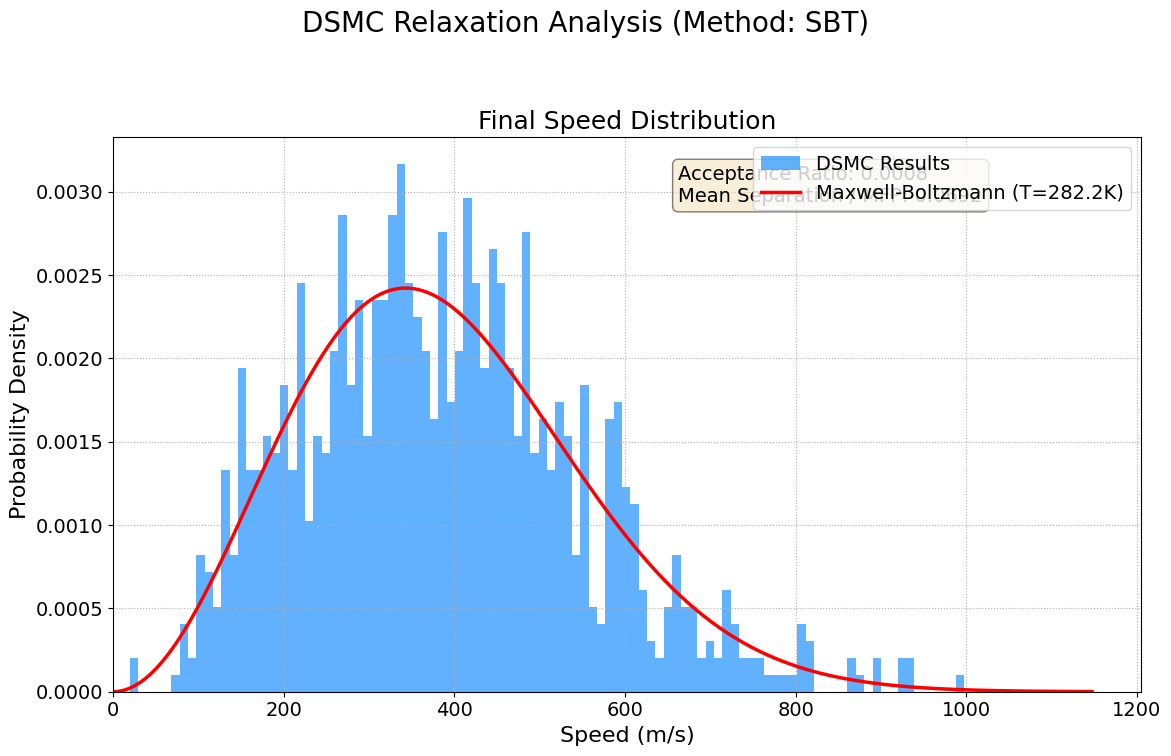

/tmp/ipython-input-1-4151727543.py:242: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


Advanced stats plot saved as DSMC_Advanced_Stats_SBT.eps


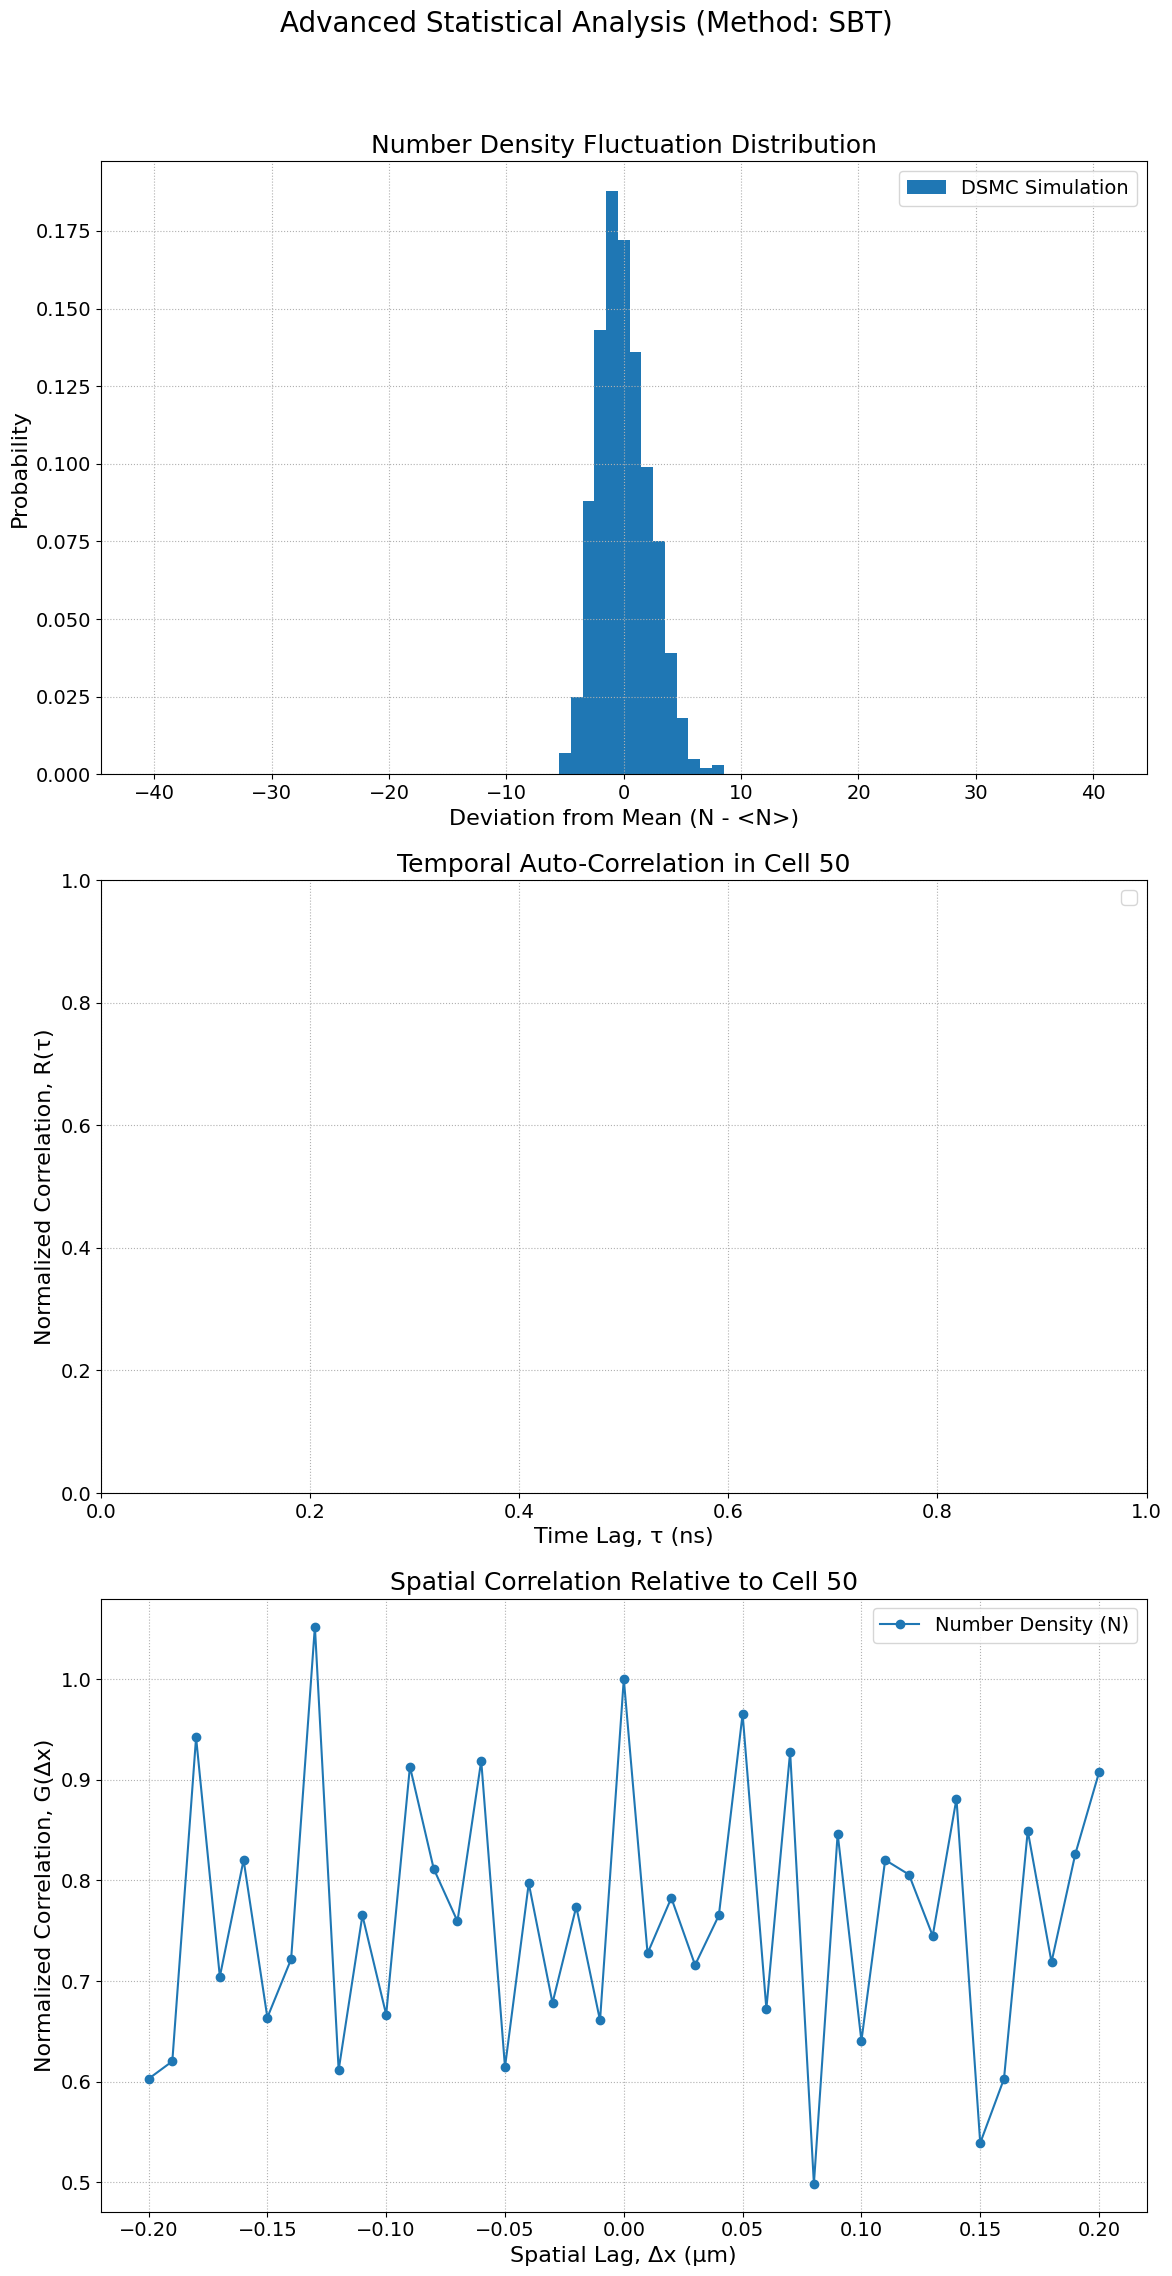

In [1]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V18.1 - Bug Fix and Parameter Change ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 5 # Changed from 100 to 5 as requested
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# Derived parameters
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_INTERVAL = 4000

# --- ADVANCED STATISTICAL SAMPLING PARAMETERS ---
MTC = 20
MXC = 20
MAXD = 40
CENTRAL_CELL_IDX = NUM_CELLS_X // 2

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def standard_sbt_scheme(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0, 0, 0.0 # n_accepted, n_selected, sum_separation
    n_selected = num_particles_in_cell - 1
    sum_sep = 0.0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
    return n_accepted, n_selected, sum_sep

@njit(nopython=True)
def perform_collisions(method, particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction, duplicate_check_array):
    n_accepted = 0
    n_selected = 0
    sum_separation = 0.0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell, 0, 0.0

    if method == 1: # SBT (Simple, Brute-Force O(N^2))
        prob_const = fnum * dt / cell_vol
        n_selected = num_particles_in_cell * (num_particles_in_cell - 1) / 2.0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 3 or method == 9: # NTC and NN
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = num_pairs_to_select

        if n_selected == 0:
            return 0, sigma_g_max_cell, 0, 0.0

        nearest_neighbor_map = np.zeros(num_particles_in_cell, dtype=np.int64)
        if method == 9:
            N = num_particles_in_cell
            cell_positions = particles[indices_in_cell, 0]
            dist_matrix = np.full((N, N), np.finfo(np.float64).max, dtype=np.float64)
            for i in range(N):
                for j in range(i + 1, N):
                    delta_x = np.abs(cell_positions[i] - cell_positions[j])
                    dist = min(delta_x, lx - delta_x)
                    dist_matrix[i, j] = dist
                    dist_matrix[j, i] = dist
            nearest_neighbor_map = np.argmin(dist_matrix, axis=1)

        for _ in range(n_selected):
            p1_local_idx = rng_state.integers(0, num_particles_in_cell)
            if method == 9:
                p2_local_idx = nearest_neighbor_map[p1_local_idx]
            else:
                p2_local_idx = rng_state.integers(0, num_particles_in_cell)
                while p1_local_idx == p2_local_idx:
                    p2_local_idx = rng_state.integers(0, num_particles_in_cell)

            p1_idx, p2_idx = indices_in_cell[p1_local_idx], indices_in_cell[p2_local_idx]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))

            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)

        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    else: # Placeholder for other methods
        return 0, sigma_g_max_cell, 0, 0.0

# --- Plotting Functions ---

def plot_standard_results(sampled_speeds, final_temp, method_name, acceptance_ratio, mean_sep_mfp):
    plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16,
                         'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})

    fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=20)

    ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
    v_max_range = np.max(sampled_speeds) * 1.15 if len(sampled_speeds) > 0 else 1500
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = (4 * np.pi * (MASS_AR / (2 * np.pi * KB * final_temp))**1.5 * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Maxwell-Boltzmann (T={final_temp:.1f}K)')

    stats_text = (f"Acceptance Ratio: {acceptance_ratio:.4f}\n"
                  f"Mean Separation / MFP: {mean_sep_mfp:.4f}")
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax1.text(0.55, 0.95, stats_text, transform=ax1.transAxes, fontsize=14,
             verticalalignment='top', bbox=props)

    ax1.set_xlabel('Speed (m/s)')
    ax1.set_ylabel('Probability Density')
    ax1.set_title('Final Speed Distribution')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':')
    ax1.set_xlim(left=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    output_filename = f'DSMC_Standard_Results_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nStandard plot saved as {output_filename}")
    plt.show()

def plot_advanced_stats(density_fluctuation_hist, temporal_corr_sums, spatial_corr_sums,
                        nsmpt, nsmpx, navg_theory, method_name, dt, cell_width):
    plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16,
                         'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})

    fig, axes = plt.subplots(3, 1, figsize=(12, 24))
    fig.suptitle(f'Advanced Statistical Analysis (Method: {method_name})', fontsize=20)

    # 1. Density Fluctuation Distribution
    ax1 = axes[0]
    dev_range = np.arange(-MAXD, MAXD + 1)
    total_samples = np.sum(density_fluctuation_hist)
    if total_samples > 0:
        prob_density_fluc = density_fluctuation_hist / total_samples
        ax1.bar(dev_range, prob_density_fluc, width=1.0, label='DSMC Simulation')

    ax1.set_title('Number Density Fluctuation Distribution')
    ax1.set_xlabel('Deviation from Mean (N - <N>)')
    ax1.set_ylabel('Probability')
    ax1.legend()
    ax1.grid(True, linestyle=':')

    # 2. Temporal Auto-Correlation
    ax2 = axes[1]
    time_lags = np.arange(-MTC, MTC + 1) * dt * SAMPLING_INTERVAL
    if nsmpt > 0:
        norm_factor_n = temporal_corr_sums[0, MTC] / nsmpt
        normalized_temporal_corr_n = (temporal_corr_sums[0, :] / nsmpt) / norm_factor_n
        ax2.plot(time_lags * 1e9, normalized_temporal_corr_n, 'o-', label='Number Density (N)')
    ax2.set_title(f'Temporal Auto-Correlation in Cell {CENTRAL_CELL_IDX}')
    ax2.set_xlabel('Time Lag, τ (ns)')
    ax2.set_ylabel('Normalized Correlation, R(τ)')
    ax2.legend()
    ax2.grid(True, linestyle=':')

    # 3. Spatial Correlation
    ax3 = axes[2]
    space_lags = np.arange(-MXC, MXC + 1) * cell_width
    if nsmpx > 0:
        norm_factor_sx = spatial_corr_sums[0, MXC] / nsmpx
        normalized_spatial_corr_n = (spatial_corr_sums[0, :] / nsmpx) / norm_factor_sx
        ax3.plot(space_lags * 1e6, normalized_spatial_corr_n, 'o-', label='Number Density (N)')
    ax3.set_title(f'Spatial Correlation Relative to Cell {CENTRAL_CELL_IDX}')
    ax3.set_xlabel('Spatial Lag, Δx (μm)')
    ax3.set_ylabel('Normalized Correlation, G(Δx)')
    ax3.legend()
    ax3.grid(True, linestyle=':')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    output_filename = f'DSMC_Advanced_Stats_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"Advanced stats plot saved as {output_filename}")
    plt.show()

# --- Added back the missing function ---
def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX

    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)

    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

# --- Main Simulation ---
def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT', 5: 'SSBT', 7: 'SGBT', 8: 'MFS', 9: 'NN'}
    collision_method_name = method_map.get(method_code, 'Unknown')
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    # --- Initialization ---
    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18, dtype=np.float64)

    # --- Initialize new sampling variables ---
    total_accepted_collisions = 0
    total_selected_pairs = 0
    total_collision_separation = 0.0

    density_fluctuation_hist = np.zeros(2 * MAXD + 1, dtype=np.int64)
    navg_theory = PARTICLES_PER_CELL_INIT

    temporal_samples_storage = np.zeros((5, 2 * MTC + 1), dtype=np.float64)
    temporal_corr_sums = np.zeros((5, 2 * MTC + 1), dtype=np.float64)
    nsmpt = 0

    spatial_corr_sums = np.zeros((5, 2 * MXC + 1), dtype=np.float64)
    nsmpx = 0

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    speed_sampling_start_step = int(num_steps * 0.9)
    total_volume = LX
    cell_width = LX / NUM_CELLS_X
    sampled_speeds_accumulator = []

    # --- Main Loop ---
    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        duplicate_check_array = np.full(TOTAL_PARTICLES_SIM, -1, dtype=np.int64)

        step_accepted_collisions = 0
        step_selected_pairs = 0
        step_sum_separation = 0.0

        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_accepted, new_sigma_g_max, n_selected, sum_sep = perform_collisions(
                method_code, particles, LX, indices_in_cell_i,
                CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state,
                sigma_g_max[i], n_sel_fraction, duplicate_check_array
            )
            sigma_g_max[i] = new_sigma_g_max
            step_accepted_collisions += n_accepted
            step_selected_pairs += n_selected
            step_sum_separation += sum_sep

        total_accepted_collisions += step_accepted_collisions
        total_selected_pairs += step_selected_pairs
        total_collision_separation += step_sum_separation

        # --- Advanced Sampling Logic ---
        if step % SAMPLING_INTERVAL == 0:
            cell_counts = np.bincount(cell_indices, minlength=NUM_CELLS_X)
            deviations = cell_counts - int(navg_theory)
            for dev in deviations:
                if -MAXD <= dev <= MAXD:
                    density_fluctuation_hist[dev + MAXD] += 1

            current_cell_props = np.zeros((5, NUM_CELLS_X))
            for i in range(NUM_CELLS_X):
                indices = np.where(cell_indices == i)[0]
                N_i = len(indices)
                current_cell_props[0, i] = N_i
                if N_i > 1:
                    v_avg = np.mean(particles[indices, 1:4], axis=0)
                    current_cell_props[1:4, i] = v_avg
                    v_var = np.var(particles[indices, 1:4], axis=0)
                    temp_i = (MASS_AR / (3 * KB)) * np.sum(v_var)
                    current_cell_props[4, i] = temp_i

            temporal_samples_storage[:, :-1] = temporal_samples_storage[:, 1:]
            temporal_samples_storage[:, -1] = current_cell_props[:, CENTRAL_CELL_IDX]

            if step > (MTC * SAMPLING_INTERVAL):
                nsmpt += 1
                center_values = temporal_samples_storage[:, MTC]
                for lag in range(2 * MTC + 1):
                    past_values = temporal_samples_storage[:, lag]
                    temporal_corr_sums[:, lag] += center_values * past_values

            nsmpx += 1
            center_props = current_cell_props[:, CENTRAL_CELL_IDX]
            for lag in range(-MXC, MXC + 1):
                cell_idx_to_compare = (CENTRAL_CELL_IDX + lag + NUM_CELLS_X) % NUM_CELLS_X
                compare_props = current_cell_props[:, cell_idx_to_compare]
                spatial_corr_sums[:, lag + MXC] += center_props * compare_props

        if step >= speed_sampling_start_step and step % SAMPLING_INTERVAL == 0:
             sampled_speeds_accumulator.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")

    # --- Final Analysis & Reporting ---
    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nFinal Equilibrium Temperature: {final_temp:.2f} K")

    acceptance_ratio = total_accepted_collisions / total_selected_pairs if total_selected_pairs > 0 else 0
    mean_separation = total_collision_separation / total_accepted_collisions if total_accepted_collisions > 0 else 0
    sigma_ref = PI * D_REF_AR**2
    mfp = 1 / (np.sqrt(2) * sigma_ref * N_DENSITY_REAL)
    sof = mean_separation / mfp if mfp > 0 else 0

    print(f"Total Collisions Accepted: {total_accepted_collisions}")
    print(f"Total Pairs Selected: {total_selected_pairs}")
    print(f"Collision Acceptance Ratio: {acceptance_ratio:.4f}")
    print(f"Mean Free Path (MFP): {mfp:.4e} m")
    print(f"Mean Collision Separation / MFP (SoF): {sof:.4f}")

    # --- Plotting ---
    if sampled_speeds_accumulator:
        plot_standard_results(np.array(sampled_speeds_accumulator), final_temp, collision_method_name, acceptance_ratio, sof)

    plot_advanced_stats(density_fluctuation_hist, temporal_corr_sums, spatial_corr_sums,
                        nsmpt, nsmpx, navg_theory, collision_method_name, DT, cell_width)


if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [3] NTC, [9] NN (Note: Other methods are placeholders): ")
        if choice in ['1', '3', '9']:
            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=0.5)
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: 1
--- DSMC Relaxation using method: SBT ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 500 particles.
Step: 4000/40000...
Step: 8000/40000...
Step: 12000/40000...
Step: 16000/40000...
Step: 20000/40000...
Step: 24000/40000...
Step: 28000/40000...
Step: 32000/40000...
Step: 36000/40000...
Step: 40000/40000...

Simulation finished in 142.27 seconds.

Final Equilibrium Temperature: 282.18 K
Total Collisions Accepted: 55656
Total Pairs Selected: 49877216
Collision Acceptance Ratio: 0.0011
Mean Free Path (MFP): 4.8239e-08 m
Mean Collision Separation / MFP (SoF): 0.0692



Combined results plot saved as DSMC_Combined_Results_SBT.eps


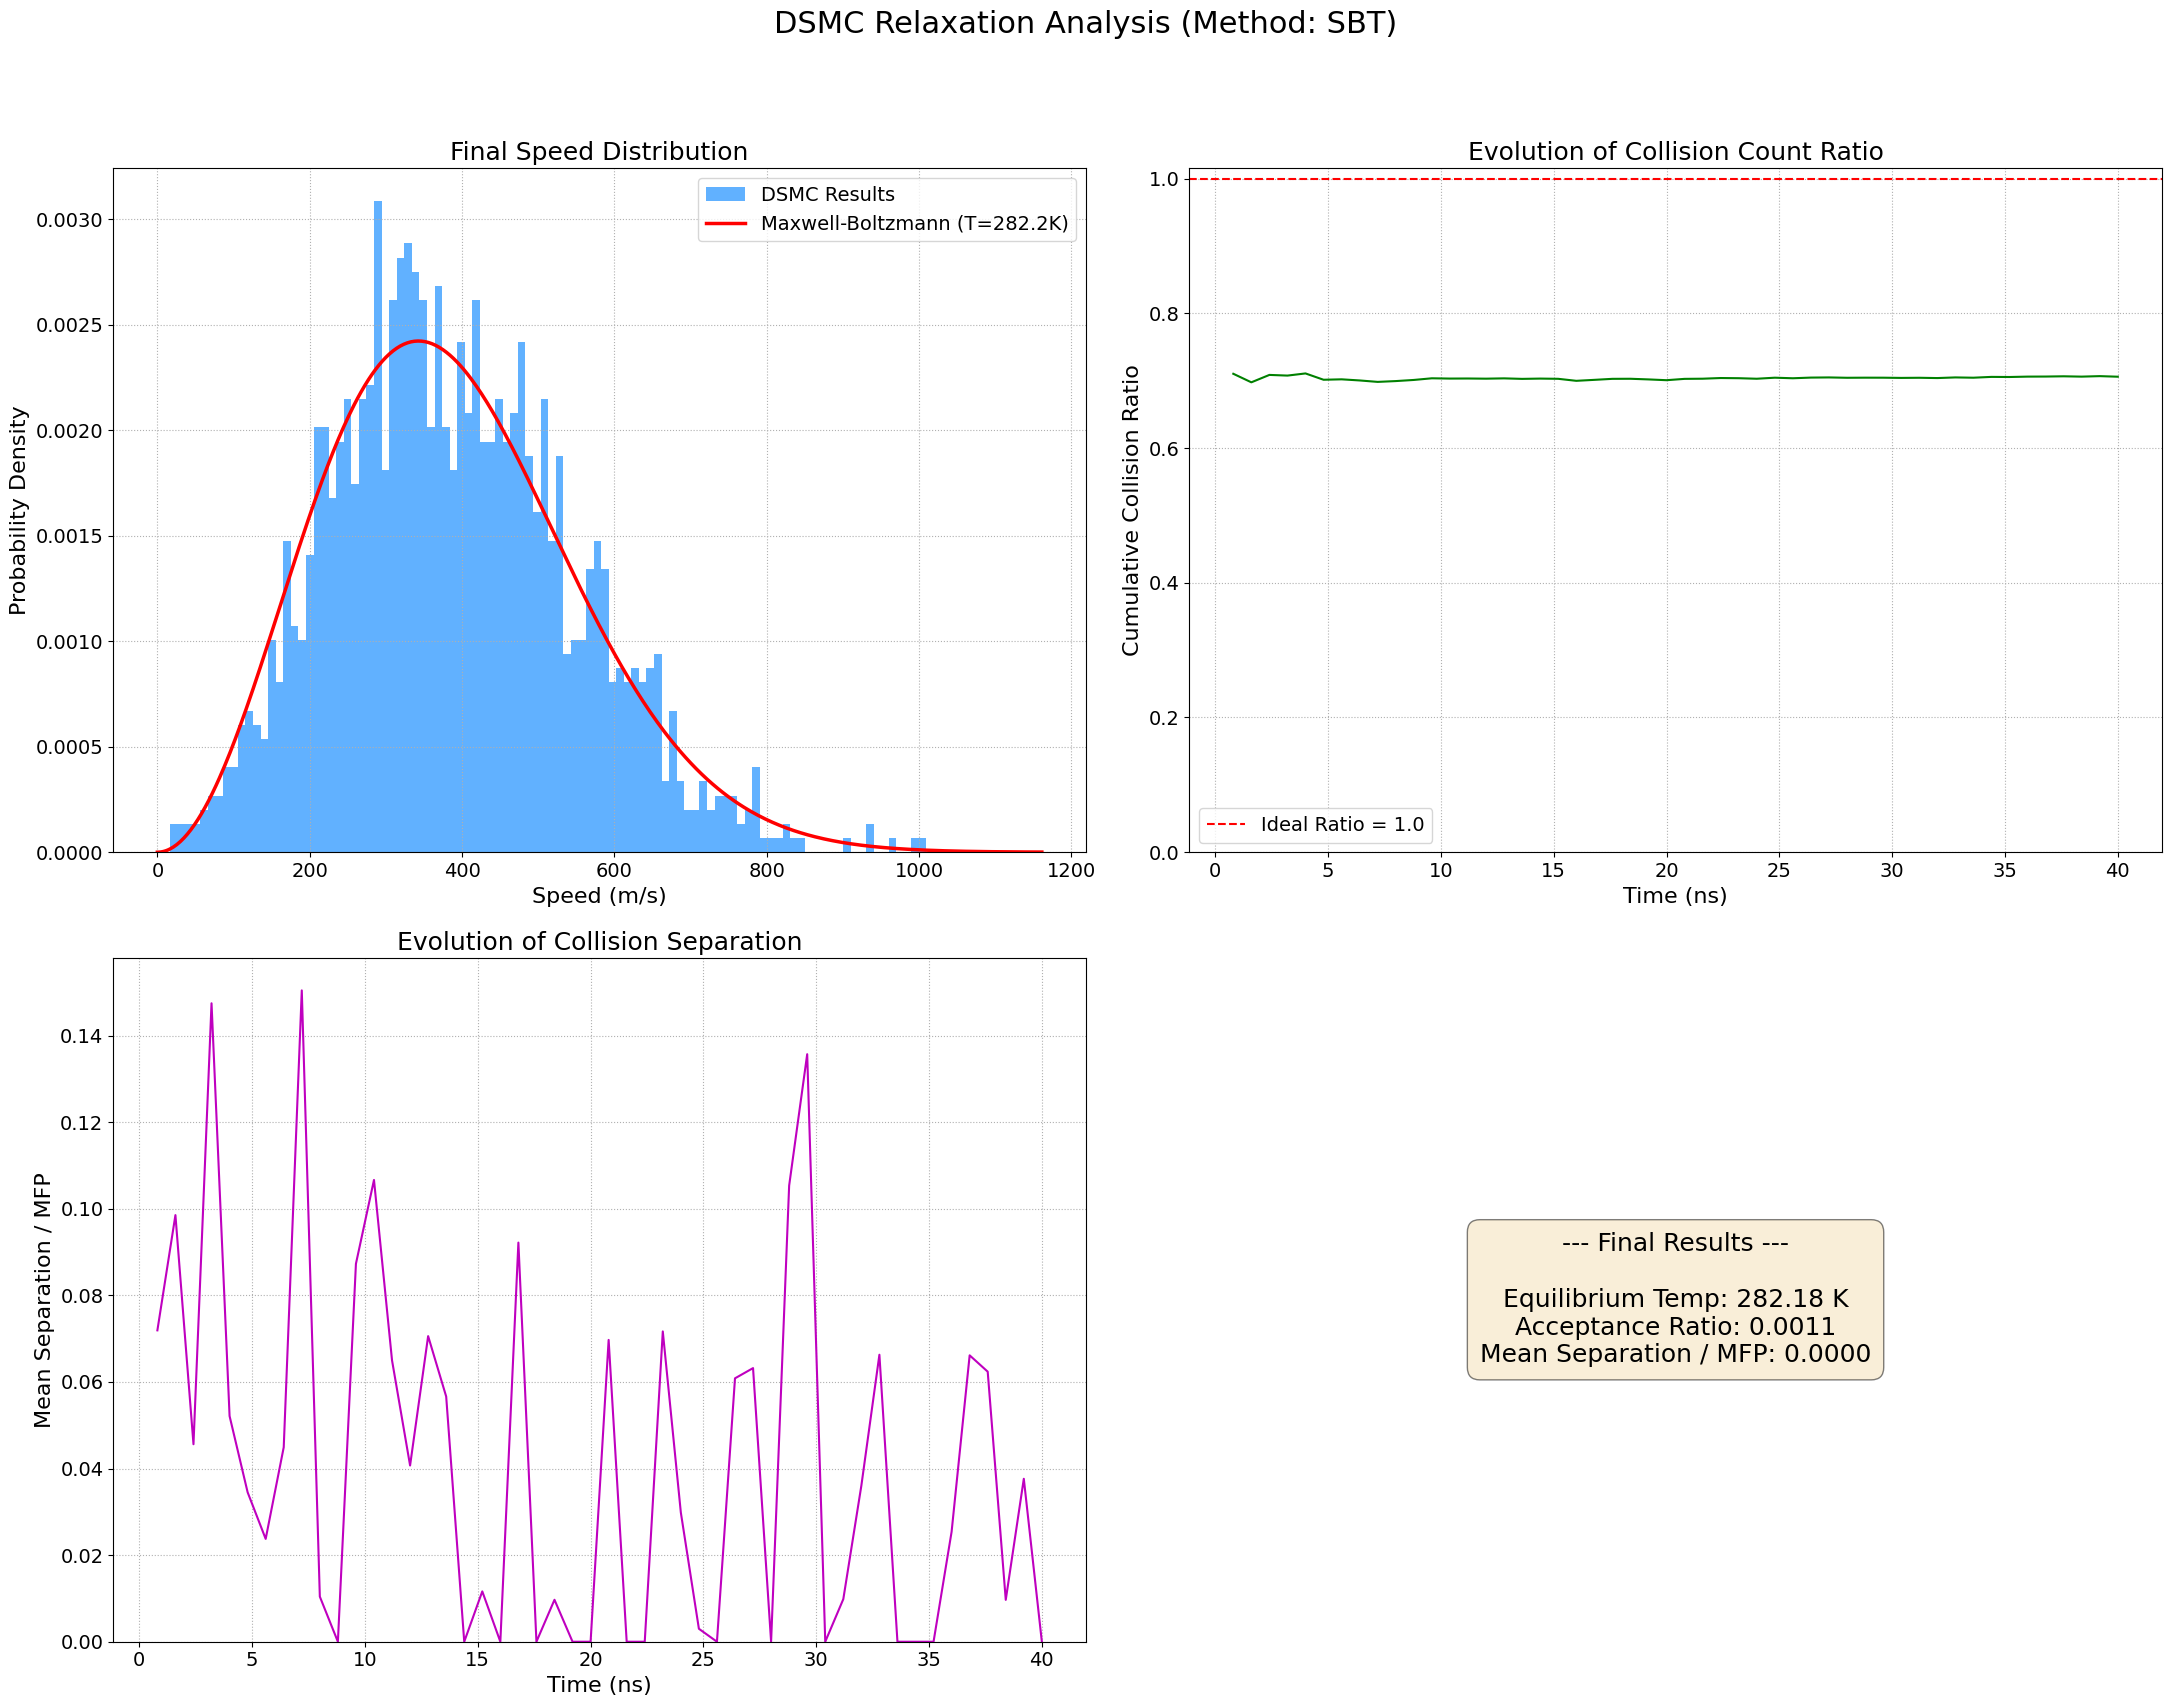

Advanced stats plot saved as DSMC_Advanced_Stats_SBT.eps


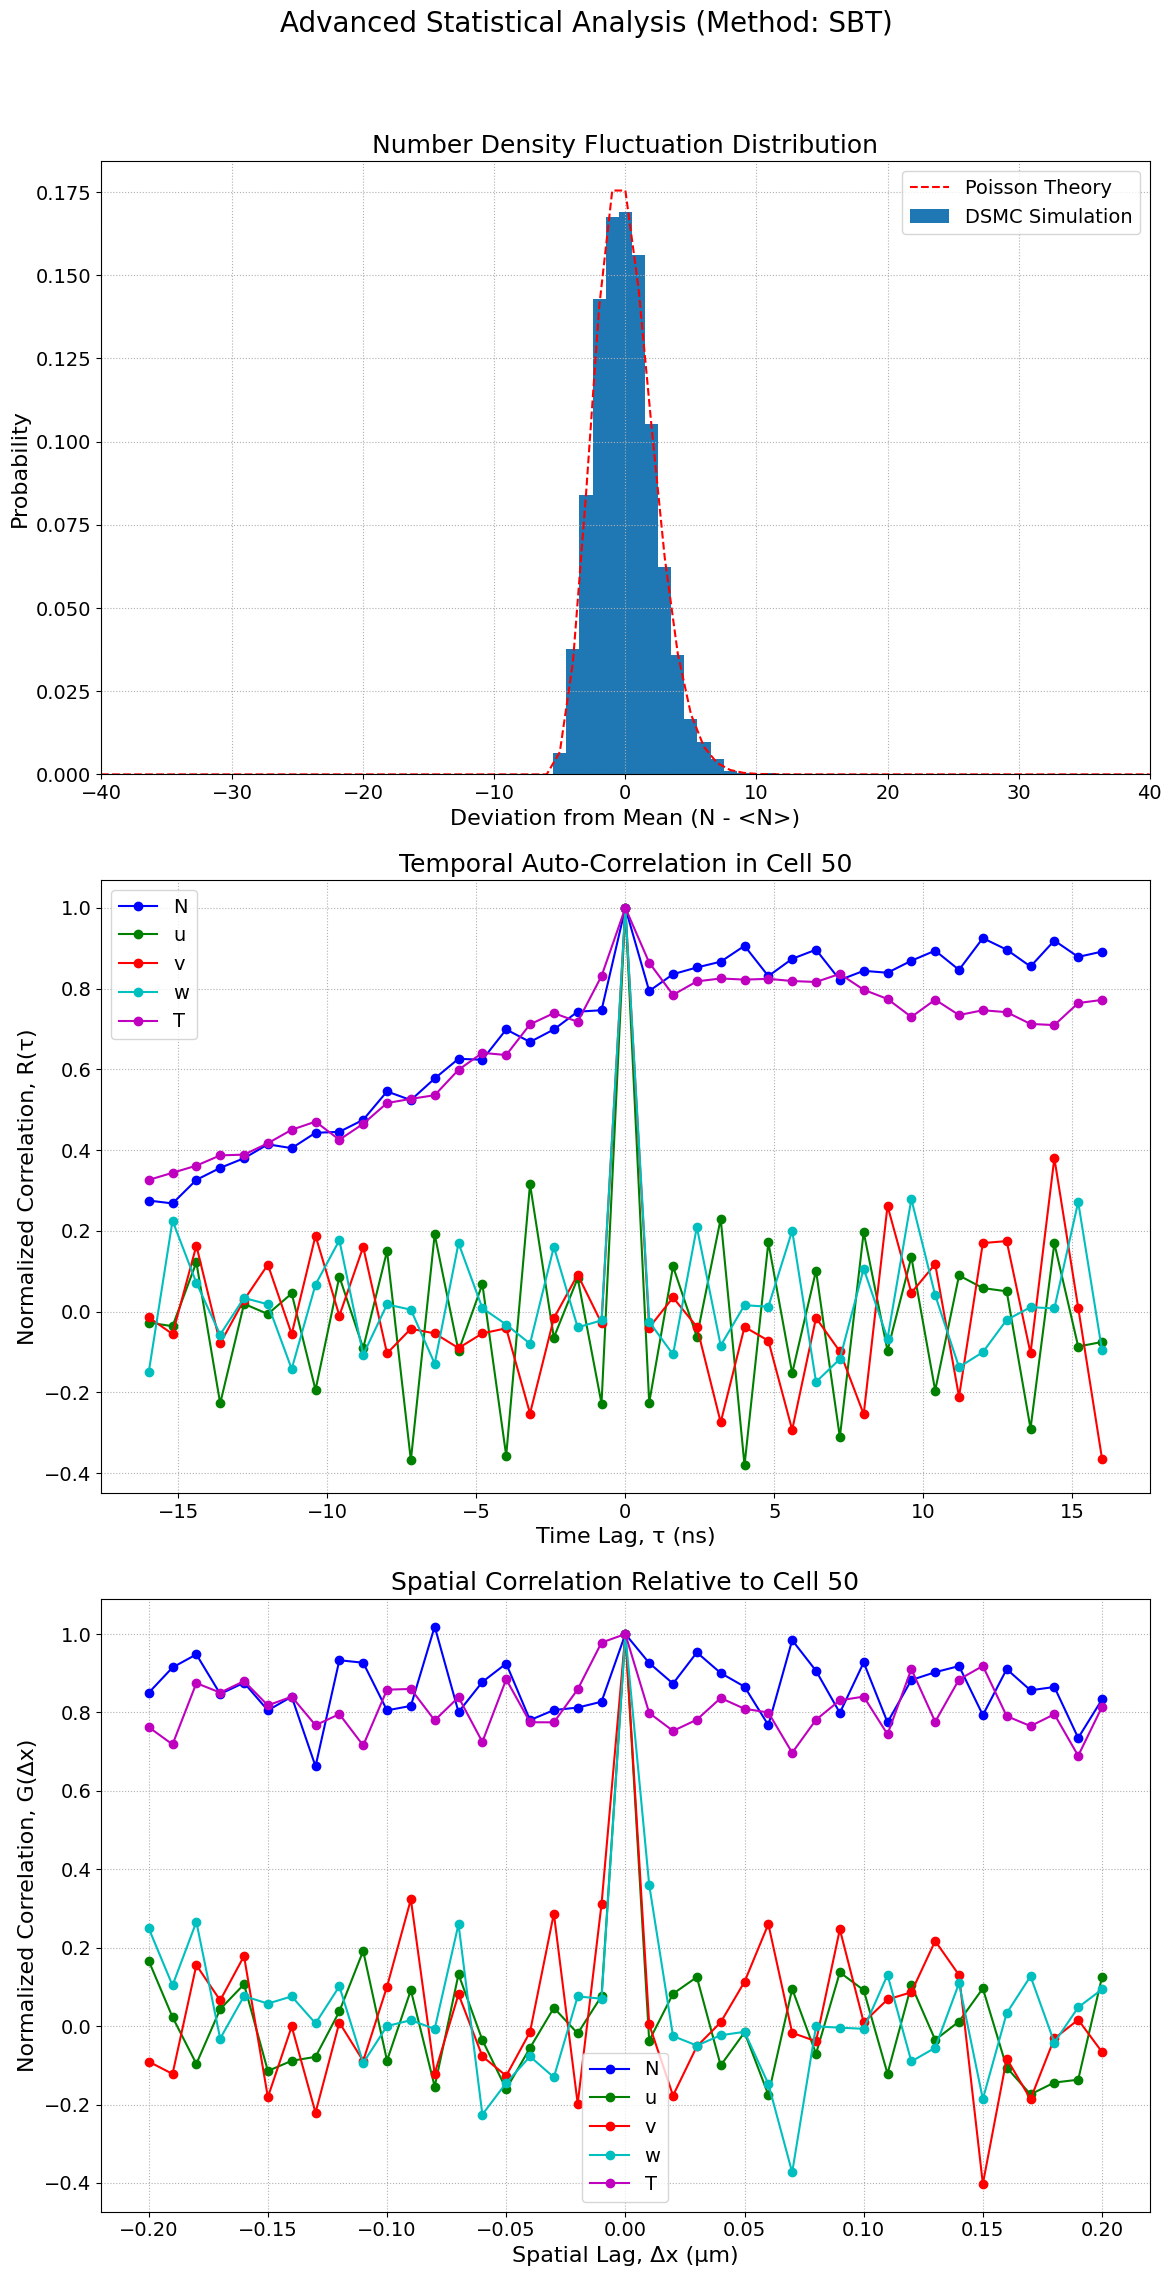

In [2]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V22.0 - Final Corrected and Complete Code ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time
from scipy.special import gammaln

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.81
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 5
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# Derived parameters
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_INTERVAL = 800

# --- ADVANCED STATISTICAL SAMPLING PARAMETERS ---
MTC = 20
MXC = 20
MAXD = 40
CENTRAL_CELL_IDX = NUM_CELLS_X // 2

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = 1.04533 # Pre-calculated gamma(2.5 - 0.5)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0, 0, 0.0
    n_selected = float(num_particles_in_cell - 1)
    sum_sep = 0.0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_sep += min(delta_x, lx - delta_x)
    return n_accepted, n_selected, sum_sep

@njit(nopython=True)
def perform_collisions(method, particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction, duplicate_check_array):
    n_accepted = 0
    n_selected = 0.0
    sum_separation = 0.0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell, 0.0, 0.0

    if method == 1: # SBT (Simple, Brute-Force O(N^2))
        prob_const = fnum * dt / cell_vol
        n_selected = num_particles_in_cell * (num_particles_in_cell - 1) / 2.0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        if num_pairs == 0: return 0, sigma_g_max_cell, 0.0, 0.0
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                distance = min(delta_x, lx - delta_x)
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i,0], pairs[i,1]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        n_selected = float(num_collisions_to_perform)
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx, 0], pairs[selected_idx, 1]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_separation += min(delta_x, lx - delta_x)
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local:
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N - 1 or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol
        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)
            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            k_k = k_k_const * (N - (i + 1.0))
            collision_prob = k_k * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 5: # SSBT
        prob_const = fnum * dt / cell_vol
        multiplier = (num_particles_in_cell - 1.0) / 2.0
        n_selected = float(num_particles_in_cell)
        for i_local in range(num_particles_in_cell):
            p1_idx = indices_in_cell[i_local]
            j_local = rng_state.integers(0, num_particles_in_cell)
            while j_local == i_local:
                j_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx = indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 6: # SGBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        prob_const = fnum * dt / cell_vol
        multiplier = (N * (N - 1.0)) / (N_sel * 2.0)
        for i in range(N_sel):
            p1_idx = reordered_global_indices[i]
            j = rng_state.integers(0, N)
            while j == i:
                j = rng_state.integers(0, N)
            p2_idx = reordered_global_indices[j]
            if duplicate_check_array[p1_idx] == p2_idx:
                continue
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    duplicate_check_array[p1_idx] = p2_idx
                    duplicate_check_array[p2_idx] = p1_idx
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 7: # MFS
        cell_time = 0.0
        n_sel_counter = 0
        while cell_time < dt:
            num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
            if num_pairs_float < 1 or sigma_g_max_cell <= 0:
                break
            nu_max = num_pairs_float * fnum * sigma_g_max_cell / cell_vol
            delta_t_c = -np.log(1.0 - rng_state.random()) / nu_max
            cell_time += delta_t_c
            n_sel_counter += 1
            if cell_time < dt:
                p1_idx_local = rng_state.integers(0, num_particles_in_cell)
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                while p1_idx_local == p2_idx_local:
                    p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
                if sigma_g_current > sigma_g_max_cell:
                    sigma_g_max_cell = sigma_g_current
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
                elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, float(n_sel_counter), sum_separation

    elif method == 8: # NN (Nearest Neighbor)
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)

        if n_selected == 0:
            return 0, sigma_g_max_cell, 0.0, 0.0

        N = num_particles_in_cell
        cell_positions = particles[indices_in_cell, 0]
        dist_matrix = np.full((N, N), np.finfo(np.float64).max, dtype=np.float64)
        for i in range(N):
            for j in range(i + 1, N):
                delta_x = np.abs(cell_positions[i] - cell_positions[j])
                dist = min(delta_x, lx - delta_x)
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist
        nearest_neighbor_map = np.argmin(dist_matrix, axis=1)

        for _ in range(num_pairs_to_select):
            p1_local_idx = rng_state.integers(0, N)
            p2_local_idx = nearest_neighbor_map[p1_local_idx]
            p1_idx, p2_idx = indices_in_cell[p1_local_idx], indices_in_cell[p2_local_idx]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))

            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    return 0, sigma_g_max_cell, 0.0, 0.0

# This function was missing in the previous version
@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume):
    #spm1 = PI * D_REF_AR**2
    #temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    #velocity_factor = np.sqrt(KB * T_REF_AR / (PI * MASS_AR))
    #tcol = (2.0 * TOTAL_TIME * N_DENSITY_REAL**2 * total_volume * spm1 * temp_factor * velocity_factor) / FNUM
    #return tcol

    sigma_ref = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    mean_speed_factor = np.sqrt(16.0 * KB * avg_temp / (PI * MASS_AR))
    coll_freq_real = 0.5 *  N_DENSITY_REAL**2 * sigma_ref * temp_factor * mean_speed_factor
    total_real_collisions = coll_freq_real * total_volume * TOTAL_TIME
    total_sim_collisions = total_real_collisions / FNUM
    return total_sim_collisions

def plot_standard_results(sampled_speeds, final_temp, method_name, acceptance_ratio, sof_history, time_history, ratio_history):
    plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})
    fig, axes = plt.subplots(2, 2, figsize=(22, 18))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=22)
    ax1, ax2, ax3, ax4 = axes.flatten()

    if len(sampled_speeds) > 0:
        ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
        v_max_range = np.max(sampled_speeds) * 1.15
        v_theory = np.linspace(0, v_max_range, 500)
        pv_theory = (4 * np.pi * (MASS_AR / (2 * np.pi * KB * final_temp))**1.5 * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
        ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Maxwell-Boltzmann (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':')

    if time_history and ratio_history:
        ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-')
        ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Cumulative Collision Ratio'); ax2.set_title('Evolution of Collision Count Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    if time_history and sof_history:
        ax3.plot(np.array(time_history) * 1e9, sof_history, 'm-')
    ax3.set_xlabel('Time (ns)'); ax3.set_ylabel('Mean Separation / MFP'); ax3.set_title('Evolution of Collision Separation')
    ax3.grid(True, linestyle=':'); ax3.set_ylim(bottom=0)

    ax4.axis('off')
    final_sof = sof_history[-1] if sof_history else 0
    stats_text = (f"--- Final Results ---\n\n"
                  f"Equilibrium Temp: {final_temp:.2f} K\n"
                  f"Acceptance Ratio: {acceptance_ratio:.4f}\n"
                  f"Mean Separation / MFP: {final_sof:.4f}")
    ax4.text(0.5, 0.5, stats_text, ha='center', va='center', fontsize=18, bbox=dict(boxstyle="round,pad=0.5", fc="wheat", alpha=0.5))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    output_filename = f'DSMC_Combined_Results_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nCombined results plot saved as {output_filename}")
    plt.show()

def plot_advanced_stats(density_fluctuation_hist, temporal_corr_sums, spatial_corr_sums, nsmpt, nsmpx, navg_theory, method_name, dt, cell_width):
    plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})
    fig, axes = plt.subplots(3, 1, figsize=(12, 24))
    fig.suptitle(f'Advanced Statistical Analysis (Method: {method_name})', fontsize=20)

    ax1 = axes[0]
    dev_range = np.arange(-MAXD, MAXD + 1)
    total_samples = np.sum(density_fluctuation_hist)
    if total_samples > 0:
        prob_density_fluc = density_fluctuation_hist / total_samples
        ax1.bar(dev_range, prob_density_fluc, width=1.0, label='DSMC Simulation')
        k_values = dev_range + navg_theory
        valid_indices = k_values >= 0
        valid_k = k_values[valid_indices].astype(np.int64)
        if navg_theory > 0:
             log_poisson = valid_k * np.log(navg_theory) - navg_theory - gammaln(valid_k + 1)
             poisson_prob = np.zeros_like(k_values, dtype=float)
             poisson_prob[valid_indices] = np.exp(log_poisson)
             ax1.plot(dev_range, poisson_prob, 'r--', label='Poisson Theory')
    ax1.set_title('Number Density Fluctuation Distribution'); ax1.set_xlabel('Deviation from Mean (N - <N>)'); ax1.set_ylabel('Probability')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=-MAXD, right=MAXD)

    ax2 = axes[1]
    time_lags = np.arange(-MTC, MTC + 1) * dt * SAMPLING_INTERVAL
    prop_labels = ['N', 'u', 'v', 'w', 'T']
    colors = ['b', 'g', 'r', 'c', 'm']
    if nsmpt > 0:
        for i in range(5):
            mean_val_sq = temporal_corr_sums[i, MTC] / nsmpt
            if mean_val_sq > 1e-9:
                normalized_corr = (temporal_corr_sums[i, :] / nsmpt) / mean_val_sq
                ax2.plot(time_lags * 1e9, normalized_corr, 'o-', color=colors[i], label=prop_labels[i])
    ax2.set_title(f'Temporal Auto-Correlation in Cell {CENTRAL_CELL_IDX}'); ax2.set_xlabel('Time Lag, τ (ns)'); ax2.set_ylabel('Normalized Correlation, R(τ)')
    ax2.legend(); ax2.grid(True, linestyle=':')

    ax3 = axes[2]
    space_lags = np.arange(-MXC, MXC + 1) * cell_width
    if nsmpx > 0:
        for i in range(5):
            norm_factor = spatial_corr_sums[i, MXC]
            if norm_factor > 1e-9:
                normalized_corr = spatial_corr_sums[i,:] / norm_factor
                ax3.plot(space_lags * 1e6, normalized_corr, 'o-', color=colors[i], label=prop_labels[i])
    ax3.set_title(f'Spatial Correlation Relative to Cell {CENTRAL_CELL_IDX}'); ax3.set_xlabel('Spatial Lag, Δx (μm)'); ax3.set_ylabel('Normalized Correlation, G(Δx)')
    ax3.legend(); ax3.grid(True, linestyle=':')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    output_filename = f'DSMC_Advanced_Stats_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"Advanced stats plot saved as {output_filename}")
    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX
    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)
    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT', 5: 'SSBT', 6: 'SGBT', 7: 'MFS', 8: 'NN'}
    collision_method_name = method_map.get(method_code, 'Unknown')
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18, dtype=np.float64)

    # --- Initialize Sampling Variables ---
    total_accepted_collisions, total_selected_pairs, total_collision_separation = 0.0, 0.0, 0.0
    density_fluctuation_hist = np.zeros(2 * MAXD + 1, dtype=np.int64)
    navg_theory = PARTICLES_PER_CELL_INIT
    temporal_samples_storage = np.zeros((5, 2 * MTC + 1))
    temporal_corr_sums = np.zeros((5, 2 * MTC + 1))
    nsmpt = 0
    spatial_corr_sums = np.zeros((5, 2 * MXC + 1))
    nsmpx = 0
    time_history, ratio_history, sof_history = [], [], []
    sampled_speeds_accumulator = []

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    speed_sampling_start_step = int(num_steps * 0.9)
    cell_width = LX / NUM_CELLS_X
    sigma_ref = PI * D_REF_AR**2
    mfp = 1 / (np.sqrt(2) * sigma_ref * N_DENSITY_REAL)

    # --- Main Loop ---
    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
        duplicate_check_array = np.full(TOTAL_PARTICLES_SIM, -1, dtype=np.int64)

        step_accepted_collisions, step_selected_pairs, step_sum_separation = 0.0, 0.0, 0.0

        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_acc, new_sigma_g_max, n_sel, sum_sep = perform_collisions(
                method_code, particles, LX, indices_in_cell_i,
                CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state,
                sigma_g_max[i], n_sel_fraction, duplicate_check_array
            )
            sigma_g_max[i] = new_sigma_g_max
            step_accepted_collisions += n_acc
            step_selected_pairs += n_sel
            step_sum_separation += sum_sep

        total_accepted_collisions += step_accepted_collisions
        total_selected_pairs += step_selected_pairs
        total_collision_separation += step_sum_separation

        if step % SAMPLING_INTERVAL == 0 and step > MTC:
            current_time = step * DT
            time_history.append(current_time)

            total_theoretical = calculate_total_theoretical_collisions(current_time, T_INIT, LX)
            ratio_history.append(total_accepted_collisions / total_theoretical if total_theoretical > 0 else 0)

            sof_interval = (step_sum_separation / step_accepted_collisions) / mfp if step_accepted_collisions > 0 else 0
            sof_history.append(sof_interval)

            cell_counts = np.bincount(cell_indices, minlength=NUM_CELLS_X)
            deviations = cell_counts - int(navg_theory)
            for dev in deviations:
                if -MAXD <= dev <= MAXD:
                    density_fluctuation_hist[dev + MAXD] += 1

            current_cell_props = np.zeros((5, NUM_CELLS_X))
            for i in range(NUM_CELLS_X):
                indices = np.where(cell_indices == i)[0]
                N_i = len(indices)
                current_cell_props[0, i] = N_i
                if N_i > 1:
                    v_avg = np.mean(particles[indices, 1:4], axis=0)
                    current_cell_props[1:4, i] = v_avg
                    v_var = np.var(particles[indices, 1:4])
                    temp_i = (MASS_AR / (3 * KB)) * v_var * 3
                    current_cell_props[4, i] = temp_i

            temporal_samples_storage[:, :-1] = temporal_samples_storage[:, 1:]
            temporal_samples_storage[:, -1] = current_cell_props[:, CENTRAL_CELL_IDX]

            nsmpt += 1
            center_values_t = temporal_samples_storage[:, MTC]
            for lag in range(2 * MTC + 1):
                past_values = temporal_samples_storage[:, lag]
                temporal_corr_sums[:, lag] += center_values_t * past_values

            nsmpx += 1
            center_props_s = current_cell_props[:, CENTRAL_CELL_IDX]
            for lag in range(-MXC, MXC + 1):
                cell_idx_to_compare = (CENTRAL_CELL_IDX + lag + NUM_CELLS_X) % NUM_CELLS_X
                compare_props = current_cell_props[:, cell_idx_to_compare]
                spatial_corr_sums[:, lag + MXC] += center_props_s * compare_props

        if step >= speed_sampling_start_step:
             if step % (SAMPLING_INTERVAL * 2) == 0:
                 sampled_speeds_accumulator.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")

    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nFinal Equilibrium Temperature: {final_temp:.2f} K")

    acceptance_ratio = total_accepted_collisions / total_selected_pairs if total_selected_pairs > 0 else 0
    mean_separation = total_collision_separation / total_accepted_collisions if total_accepted_collisions > 0 else 0
    sof = mean_separation / mfp if mfp > 0 else 0

    print(f"Total Collisions Accepted: {int(total_accepted_collisions)}")
    print(f"Total Pairs Selected: {int(total_selected_pairs)}")
    print(f"Collision Acceptance Ratio: {acceptance_ratio:.4f}")
    print(f"Mean Free Path (MFP): {mfp:.4e} m")
    print(f"Mean Collision Separation / MFP (SoF): {sof:.4f}")

    if sampled_speeds_accumulator:
        plot_standard_results(np.array(sampled_speeds_accumulator), final_temp, collision_method_name, acceptance_ratio, sof_history, time_history, ratio_history)

    plot_advanced_stats(density_fluctuation_hist, temporal_corr_sums, spatial_corr_sums, nsmpt, nsmpx, navg_theory, collision_method_name, DT, cell_width)

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: ")
        if choice in ['1', '2', '3', '4', '5', '6', '7', '8']:
            n_sel_fraction = 0.5
            if choice in ['4', '6']:
                try:
                    n_sel_input = float(input(f"Enter the N_sel fraction for { {4:'GBT', 6:'SGBT'}[int(choice)] } (e.g., 0.33 for N/3): "))
                    if 0 < n_sel_input < 1:
                        n_sel_fraction = n_sel_input
                    else:
                        print("Invalid fraction. Using default value of 0.33.")
                        n_sel_fraction = 0.33
                except ValueError:
                    print("Invalid input. Using default value of 0.33.")
                    n_sel_fraction = 0.33

            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=n_sel_fraction)
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: 1
--- DSMC Relaxation using method: SBT ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 500 particles.
Step: 4000/40000...
Step: 8000/40000...
Step: 12000/40000...
Step: 16000/40000...
Step: 20000/40000...
Step: 24000/40000...
Step: 28000/40000...
Step: 32000/40000...
Step: 36000/40000...
Step: 40000/40000...

Simulation finished in 135.22 seconds.

Final Equilibrium Temperature: 282.18 K
Total Collisions Accepted: 76619
Total Pairs Selected: 49861563
Collision Acceptance Ratio: 0.0015
Mean Free Path (MFP): 4.8239e-08 m
Mean Collision Separation / MFP (SoF): 0.0690


/tmp/ipython-input-1-4197464610.py:420: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(); ax2.grid(True, linestyle=':')


Advanced stats plot saved as DSMC_Advanced_Stats_SBT.eps


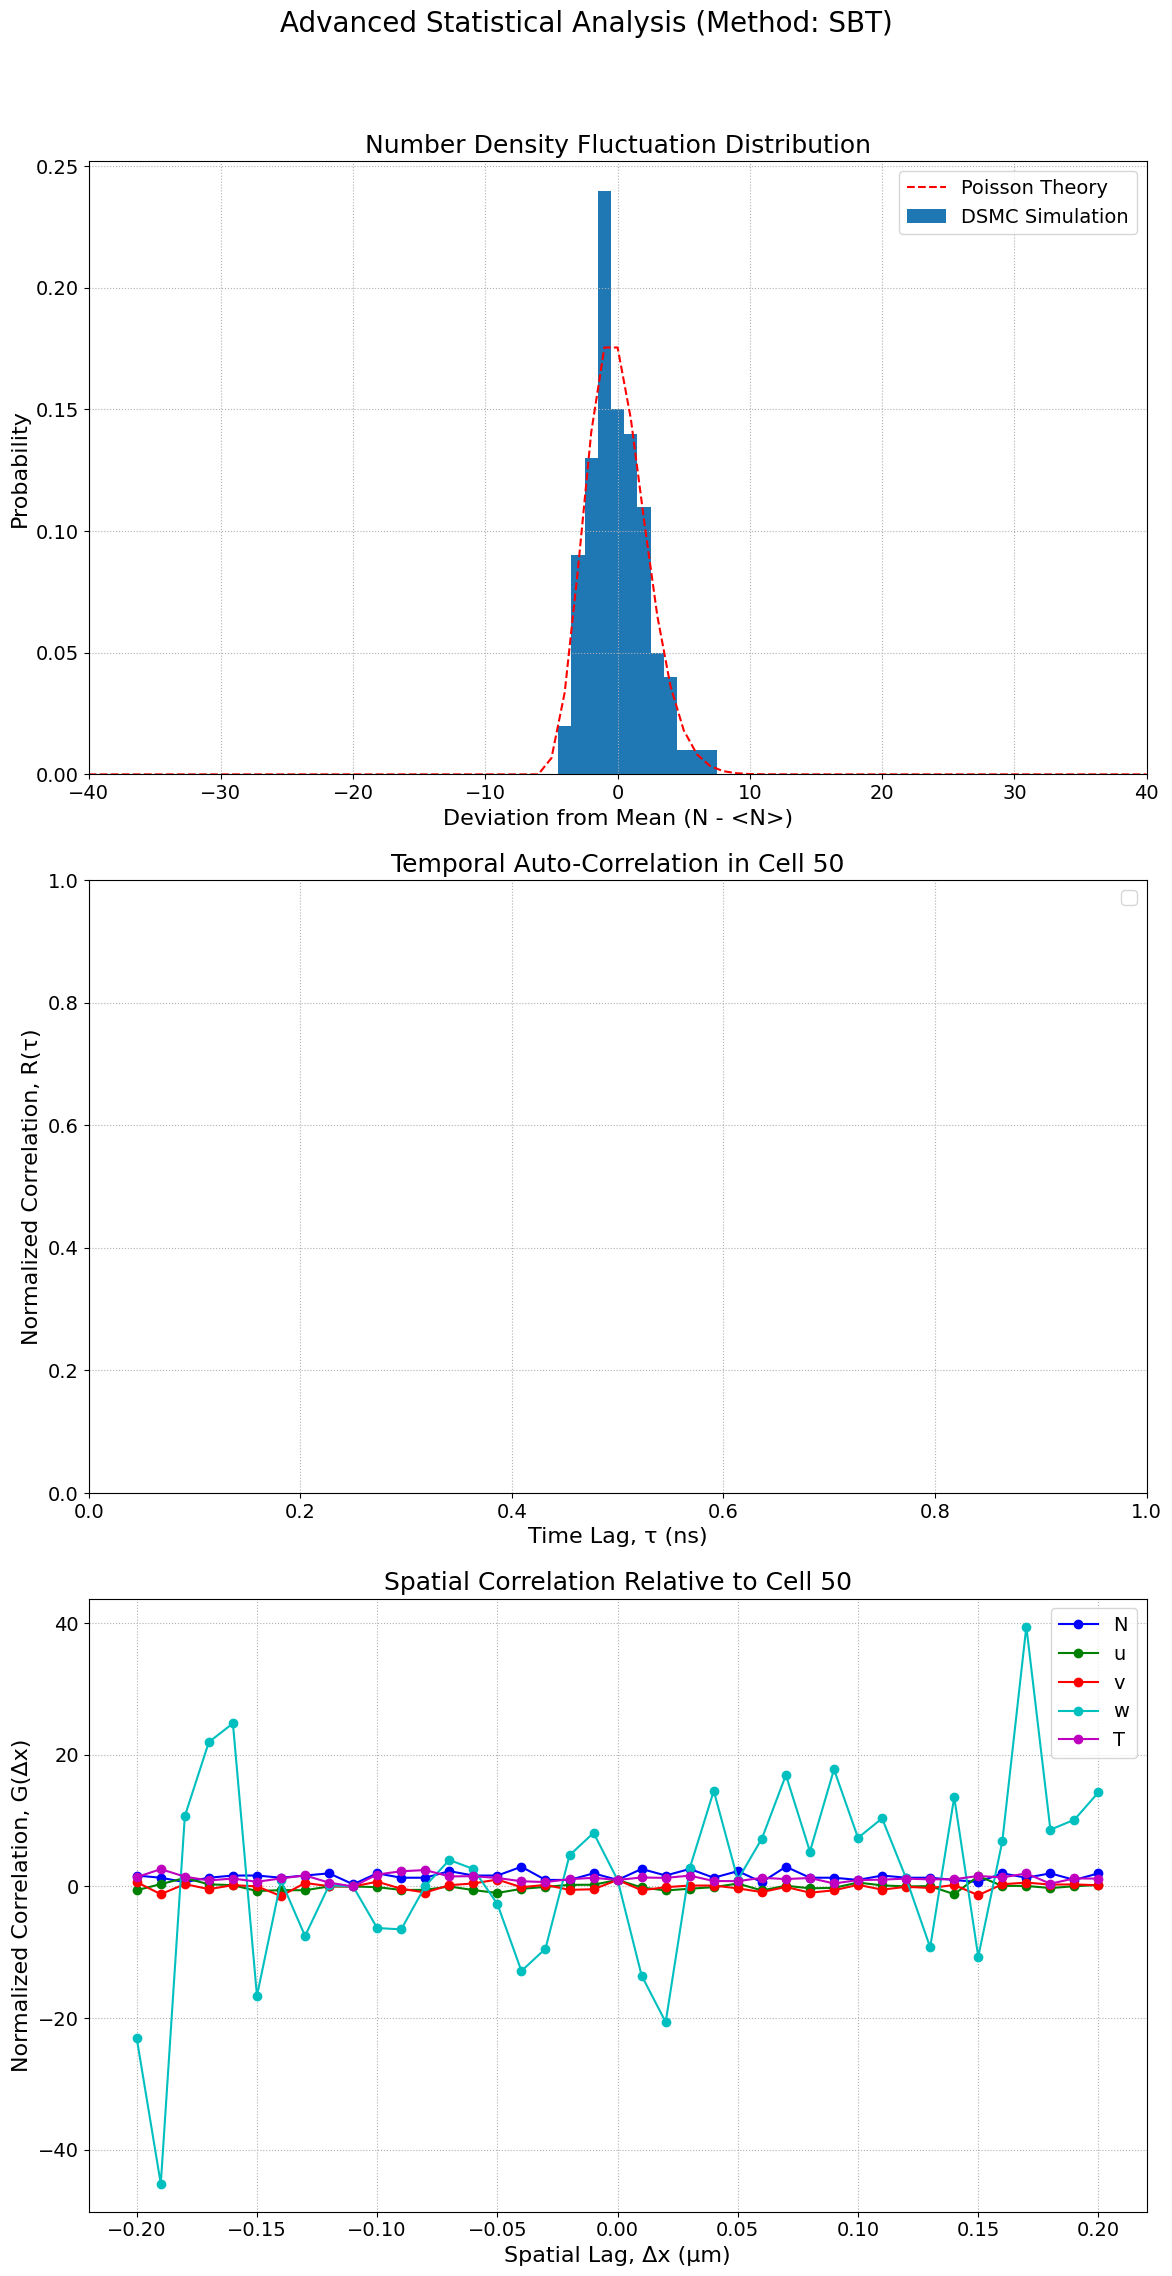

In [1]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V23.0 - FINAL, COMPLETE, AND CORRECTED CODE ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time
from scipy.special import gammaln

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 5
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# Derived parameters
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_INTERVAL = 40000

# --- ADVANCED STATISTICAL SAMPLING PARAMETERS ---
MTC = 20
MXC = 20
MAXD = 40
CENTRAL_CELL_IDX = NUM_CELLS_X // 2

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = 1.04533 # Pre-calculated gamma(2.5 - 0.5)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0, 0, 0.0
    n_selected = float(num_particles_in_cell - 1)
    sum_sep = 0.0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_sep += min(delta_x, lx - delta_x)
    return n_accepted, n_selected, sum_sep

@njit(nopython=True)
def perform_collisions(method, particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction, duplicate_check_array):
    n_accepted = 0
    n_selected = 0.0
    sum_separation = 0.0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell, 0.0, 0.0

    if method == 1: # SBT (Simple, Brute-Force O(N^2))
        prob_const = fnum * dt / cell_vol
        n_selected = num_particles_in_cell * (num_particles_in_cell - 1) / 2.0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        if num_pairs == 0: return 0, sigma_g_max_cell, 0.0, 0.0
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                distance = min(delta_x, lx - delta_x)
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i,0], pairs[i,1]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        n_selected = float(num_collisions_to_perform)
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx, 0], pairs[selected_idx, 1]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_separation += min(delta_x, lx - delta_x)
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local:
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N - 1 or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol
        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)
            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            k_k = k_k_const * (N - (i + 1.0))
            collision_prob = k_k * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 5: # SSBT
        prob_const = fnum * dt / cell_vol
        multiplier = (num_particles_in_cell - 1.0) / 2.0
        n_selected = float(num_particles_in_cell)
        for i_local in range(num_particles_in_cell):
            p1_idx = indices_in_cell[i_local]
            j_local = rng_state.integers(0, num_particles_in_cell)
            while j_local == i_local:
                j_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx = indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 6: # SGBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        prob_const = fnum * dt / cell_vol
        multiplier = (N * (N - 1.0)) / (N_sel * 2.0)
        for i in range(N_sel):
            p1_idx = reordered_global_indices[i]
            j = rng_state.integers(0, N)
            while j == i:
                j = rng_state.integers(0, N)
            p2_idx = reordered_global_indices[j]
            if duplicate_check_array[p1_idx] == p2_idx:
                continue
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    duplicate_check_array[p1_idx] = p2_idx
                    duplicate_check_array[p2_idx] = p1_idx
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 7: # MFS
        cell_time = 0.0
        n_sel_counter = 0
        while cell_time < dt:
            num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
            if num_pairs_float < 1 or sigma_g_max_cell <= 0:
                break
            nu_max = num_pairs_float * fnum * sigma_g_max_cell / cell_vol
            delta_t_c = -np.log(1.0 - rng_state.random()) / nu_max
            cell_time += delta_t_c
            n_sel_counter += 1
            if cell_time < dt:
                p1_idx_local = rng_state.integers(0, num_particles_in_cell)
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                while p1_idx_local == p2_idx_local:
                    p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
                if sigma_g_current > sigma_g_max_cell:
                    sigma_g_max_cell = sigma_g_current
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
                elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, float(n_sel_counter), sum_separation

    elif method == 8: # NN (Nearest Neighbor)
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)

        if n_selected == 0:
            return 0, sigma_g_max_cell, 0.0, 0.0

        N = num_particles_in_cell
        cell_positions = particles[indices_in_cell, 0]
        dist_matrix = np.full((N, N), np.finfo(np.float64).max, dtype=np.float64)
        for i in range(N):
            for j in range(i + 1, N):
                delta_x = np.abs(cell_positions[i] - cell_positions[j])
                dist = min(delta_x, lx - delta_x)
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist
        nearest_neighbor_map = np.argmin(dist_matrix, axis=1)

        for _ in range(num_pairs_to_select):
            p1_local_idx = rng_state.integers(0, N)
            p2_local_idx = nearest_neighbor_map[p1_local_idx]
            p1_idx, p2_idx = indices_in_cell[p1_local_idx], indices_in_cell[p2_local_idx]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))

            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    return 0, sigma_g_max_cell, 0.0, 0.0

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume, fnum, n_density):
    sigma_ref = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    mean_speed_factor = np.sqrt(16.0 * KB * avg_temp / (PI * MASS_AR))
    coll_freq_real = 0.5 * n_density**2 * sigma_ref * temp_factor * mean_speed_factor
    total_real_collisions = coll_freq_real * total_volume * TOTAL_TIME
    total_sim_collisions = total_real_collisions / fnum
    return total_sim_collisions

def plot_standard_results(sampled_speeds, final_temp, method_name, acceptance_ratio, sof_history, time_history, ratio_history):
    plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})
    fig, axes = plt.subplots(2, 2, figsize=(22, 18))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=22)
    ax1, ax2, ax3, ax4 = axes.flatten()

    if len(sampled_speeds) > 0:
        ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
        v_max_range = np.max(sampled_speeds) * 1.15
        v_theory = np.linspace(0, v_max_range, 500)
        pv_theory = (4 * np.pi * (MASS_AR / (2 * np.pi * KB * final_temp))**1.5 * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
        ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Maxwell-Boltzmann (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':')

    if time_history and ratio_history:
        ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-')
        ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Cumulative Collision Ratio'); ax2.set_title('Evolution of Collision Count Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    if time_history and sof_history:
        ax3.plot(np.array(time_history) * 1e9, sof_history, 'm-')
    ax3.set_xlabel('Time (ns)'); ax3.set_ylabel('Mean Separation / MFP'); ax3.set_title('Evolution of Collision Separation')
    ax3.grid(True, linestyle=':'); ax3.set_ylim(bottom=0)

    ax4.axis('off')
    final_sof = sof_history[-1] if sof_history else 0
    stats_text = (f"--- Final Results ---\n\n"
                  f"Equilibrium Temp: {final_temp:.2f} K\n"
                  f"Acceptance Ratio: {acceptance_ratio:.4f}\n"
                  f"Mean Separation / MFP: {final_sof:.4f}")
    ax4.text(0.5, 0.5, stats_text, ha='center', va='center', fontsize=18, bbox=dict(boxstyle="round,pad=0.5", fc="wheat", alpha=0.5))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    output_filename = f'DSMC_Combined_Results_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nCombined results plot saved as {output_filename}")
    plt.show()

def plot_advanced_stats(density_fluctuation_hist, temporal_corr_sums, spatial_corr_sums, nsmpt, nsmpx, navg_theory, method_name, dt, cell_width):
    plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})
    fig, axes = plt.subplots(3, 1, figsize=(12, 24))
    fig.suptitle(f'Advanced Statistical Analysis (Method: {method_name})', fontsize=20)

    ax1 = axes[0]
    dev_range = np.arange(-MAXD, MAXD + 1)
    total_samples = np.sum(density_fluctuation_hist)
    if total_samples > 0:
        prob_density_fluc = density_fluctuation_hist / total_samples
        ax1.bar(dev_range, prob_density_fluc, width=1.0, label='DSMC Simulation')
        k_values = dev_range + navg_theory
        valid_indices = k_values >= 0
        valid_k = k_values[valid_indices].astype(np.int64)
        if navg_theory > 0:
             log_poisson = valid_k * np.log(navg_theory) - navg_theory - gammaln(valid_k + 1)
             poisson_prob = np.zeros_like(k_values, dtype=float)
             poisson_prob[valid_indices] = np.exp(log_poisson)
             ax1.plot(dev_range, poisson_prob, 'r--', label='Poisson Theory')
    ax1.set_title('Number Density Fluctuation Distribution'); ax1.set_xlabel('Deviation from Mean (N - <N>)'); ax1.set_ylabel('Probability')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=-MAXD, right=MAXD)

    ax2 = axes[1]
    time_lags = np.arange(-MTC, MTC + 1) * dt * SAMPLING_INTERVAL
    prop_labels = ['N', 'u', 'v', 'w', 'T']
    colors = ['b', 'g', 'r', 'c', 'm']
    if nsmpt > 0:
        for i in range(5):
            mean_val_sq = temporal_corr_sums[i, MTC] / nsmpt
            if mean_val_sq > 1e-9:
                normalized_corr = (temporal_corr_sums[i, :] / nsmpt) / mean_val_sq
                ax2.plot(time_lags * 1e9, normalized_corr, 'o-', color=colors[i], label=prop_labels[i])
    ax2.set_title(f'Temporal Auto-Correlation in Cell {CENTRAL_CELL_IDX}'); ax2.set_xlabel('Time Lag, τ (ns)'); ax2.set_ylabel('Normalized Correlation, R(τ)')
    ax2.legend(); ax2.grid(True, linestyle=':')

    ax3 = axes[2]
    space_lags = np.arange(-MXC, MXC + 1) * cell_width
    if nsmpx > 0:
        for i in range(5):
            norm_factor = spatial_corr_sums[i, MXC]
            if norm_factor > 1e-9:
                normalized_corr = spatial_corr_sums[i,:] / norm_factor
                ax3.plot(space_lags * 1e6, normalized_corr, 'o-', color=colors[i], label=prop_labels[i])
    ax3.set_title(f'Spatial Correlation Relative to Cell {CENTRAL_CELL_IDX}'); ax3.set_xlabel('Spatial Lag, Δx (μm)'); ax3.set_ylabel('Normalized Correlation, G(Δx)')
    ax3.legend(); ax3.grid(True, linestyle=':')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    output_filename = f'DSMC_Advanced_Stats_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"Advanced stats plot saved as {output_filename}")
    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX
    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)
    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT', 5: 'SSBT', 6: 'SGBT', 7: 'MFS', 8: 'NN'}
    collision_method_name = method_map.get(method_code, 'Unknown')
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18, dtype=np.float64)

    total_accepted_collisions, total_selected_pairs, total_collision_separation = 0.0, 0.0, 0.0
    density_fluctuation_hist = np.zeros(2 * MAXD + 1, dtype=np.int64)
    navg_theory = PARTICLES_PER_CELL_INIT
    temporal_samples_storage = np.zeros((5, 2 * MTC + 1))
    temporal_corr_sums = np.zeros((5, 2 * MTC + 1))
    nsmpt = 0
    spatial_corr_sums = np.zeros((5, 2 * MXC + 1))
    nsmpx = 0
    time_history, ratio_history, sof_history = [], [], []
    sampled_speeds_accumulator = []

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    speed_sampling_start_step = int(num_steps * 0.9)
    cell_width = LX / NUM_CELLS_X
    sigma_ref = PI * D_REF_AR**2
    mfp = 1 / (np.sqrt(2) * sigma_ref * N_DENSITY_REAL)

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
        duplicate_check_array = np.full(TOTAL_PARTICLES_SIM, -1, dtype=np.int64)

        step_accepted_collisions, step_selected_pairs, step_sum_separation = 0.0, 0.0, 0.0

        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_acc, new_sigma_g_max, n_sel, sum_sep = perform_collisions(
                method_code, particles, LX, indices_in_cell_i,
                CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state,
                sigma_g_max[i], n_sel_fraction, duplicate_check_array
            )
            sigma_g_max[i] = new_sigma_g_max
            step_accepted_collisions += n_acc
            step_selected_pairs += n_sel
            step_sum_separation += sum_sep

        total_accepted_collisions += step_accepted_collisions
        total_selected_pairs += step_selected_pairs
        total_collision_separation += step_sum_separation

        if step % SAMPLING_INTERVAL == 0 and step > MTC:
            current_time = step * DT
            time_history.append(current_time)

            total_theoretical = calculate_total_theoretical_collisions(current_time, T_INIT, LX, FNUM, N_DENSITY_REAL)
            ratio_history.append(total_accepted_collisions / total_theoretical if total_theoretical > 0 else 0)

            sof_interval = (step_sum_separation / step_accepted_collisions) / mfp if step_accepted_collisions > 0 and mfp > 0 else 0
            sof_history.append(sof_interval)

            cell_counts = np.bincount(cell_indices, minlength=NUM_CELLS_X)
            deviations = cell_counts - int(navg_theory)
            for dev in deviations:
                if -MAXD <= dev <= MAXD:
                    density_fluctuation_hist[dev + MAXD] += 1

            current_cell_props = np.zeros((5, NUM_CELLS_X))
            for i in range(NUM_CELLS_X):
                indices = np.where(cell_indices == i)[0]
                N_i = len(indices)
                current_cell_props[0, i] = N_i
                if N_i > 1:
                    v_avg = np.mean(particles[indices, 1:4], axis=0)
                    current_cell_props[1:4, i] = v_avg
                    v_var = np.var(particles[indices, 1:4])
                    temp_i = (MASS_AR / (3 * KB)) * v_var * 3
                    current_cell_props[4, i] = temp_i

            temporal_samples_storage[:, :-1] = temporal_samples_storage[:, 1:]
            temporal_samples_storage[:, -1] = current_cell_props[:, CENTRAL_CELL_IDX]

            nsmpt += 1
            center_values_t = temporal_samples_storage[:, MTC]
            for lag in range(2 * MTC + 1):
                past_values = temporal_samples_storage[:, lag]
                temporal_corr_sums[:, lag] += center_values_t * past_values

            nsmpx += 1
            center_props_s = current_cell_props[:, CENTRAL_CELL_IDX]
            for lag in range(-MXC, MXC + 1):
                cell_idx_to_compare = (CENTRAL_CELL_IDX + lag + NUM_CELLS_X) % NUM_CELLS_X
                compare_props = current_cell_props[:, cell_idx_to_compare]
                spatial_corr_sums[:, lag + MXC] += center_props_s * compare_props

        if step >= speed_sampling_start_step:
             if step % (SAMPLING_INTERVAL * 2) == 0:
                 sampled_speeds_accumulator.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")

    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nFinal Equilibrium Temperature: {final_temp:.2f} K")

    acceptance_ratio = total_accepted_collisions / total_selected_pairs if total_selected_pairs > 0 else 0
    mean_separation = total_collision_separation / total_accepted_collisions if total_accepted_collisions > 0 else 0
    sof = mean_separation / mfp if mfp > 0 else 0

    print(f"Total Collisions Accepted: {int(total_accepted_collisions)}")
    print(f"Total Pairs Selected: {int(total_selected_pairs)}")
    print(f"Collision Acceptance Ratio: {acceptance_ratio:.4f}")
    print(f"Mean Free Path (MFP): {mfp:.4e} m")
    print(f"Mean Collision Separation / MFP (SoF): {sof:.4f}")

    if sampled_speeds_accumulator:
        plot_standard_results(np.array(sampled_speeds_accumulator), final_temp, collision_method_name, acceptance_ratio, sof_history, time_history, ratio_history)

    plot_advanced_stats(density_fluctuation_hist, temporal_corr_sums, spatial_corr_sums, nsmpt, nsmpx, navg_theory, collision_method_name, DT, cell_width)

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: ")
        if choice in ['1', '2', '3', '4', '5', '6', '7', '8']:
            n_sel_fraction = 0.5
            if choice in ['4', '6']:
                try:
                    n_sel_input = float(input(f"Enter the N_sel fraction for { {4:'GBT', 6:'SGBT'}[int(choice)] } (e.g., 0.33 for N/3): "))
                    if 0 < n_sel_input < 1:
                        n_sel_fraction = n_sel_input
                    else:
                        print("Invalid fraction. Using default value of 0.33.")
                        n_sel_fraction = 0.33
                except ValueError:
                    print("Invalid input. Using default value of 0.33.")
                    n_sel_fraction = 0.33

            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=n_sel_fraction)
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


KeyboardInterrupt: Interrupted by user

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: 1
--- DSMC Relaxation using method: SBT ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 500 particles.
Step: 4000/40000...
Step: 8000/40000...
Step: 12000/40000...
Step: 16000/40000...
Step: 20000/40000...
Step: 24000/40000...
Step: 28000/40000...
Step: 32000/40000...
Step: 36000/40000...
Step: 40000/40000...

Simulation finished in 147.95 seconds.

Final Equilibrium Temperature: 282.18 K
Total Collisions Accepted: 50386
Total Pairs Selected: 49844258
Collision Acceptance Ratio: 0.0010
Mean Free Path (MFP): 4.8239e-08 m
Mean Collision Separation / MFP (SoF): 0.0693



Combined results plot saved as DSMC_Combined_Results_SBT.eps


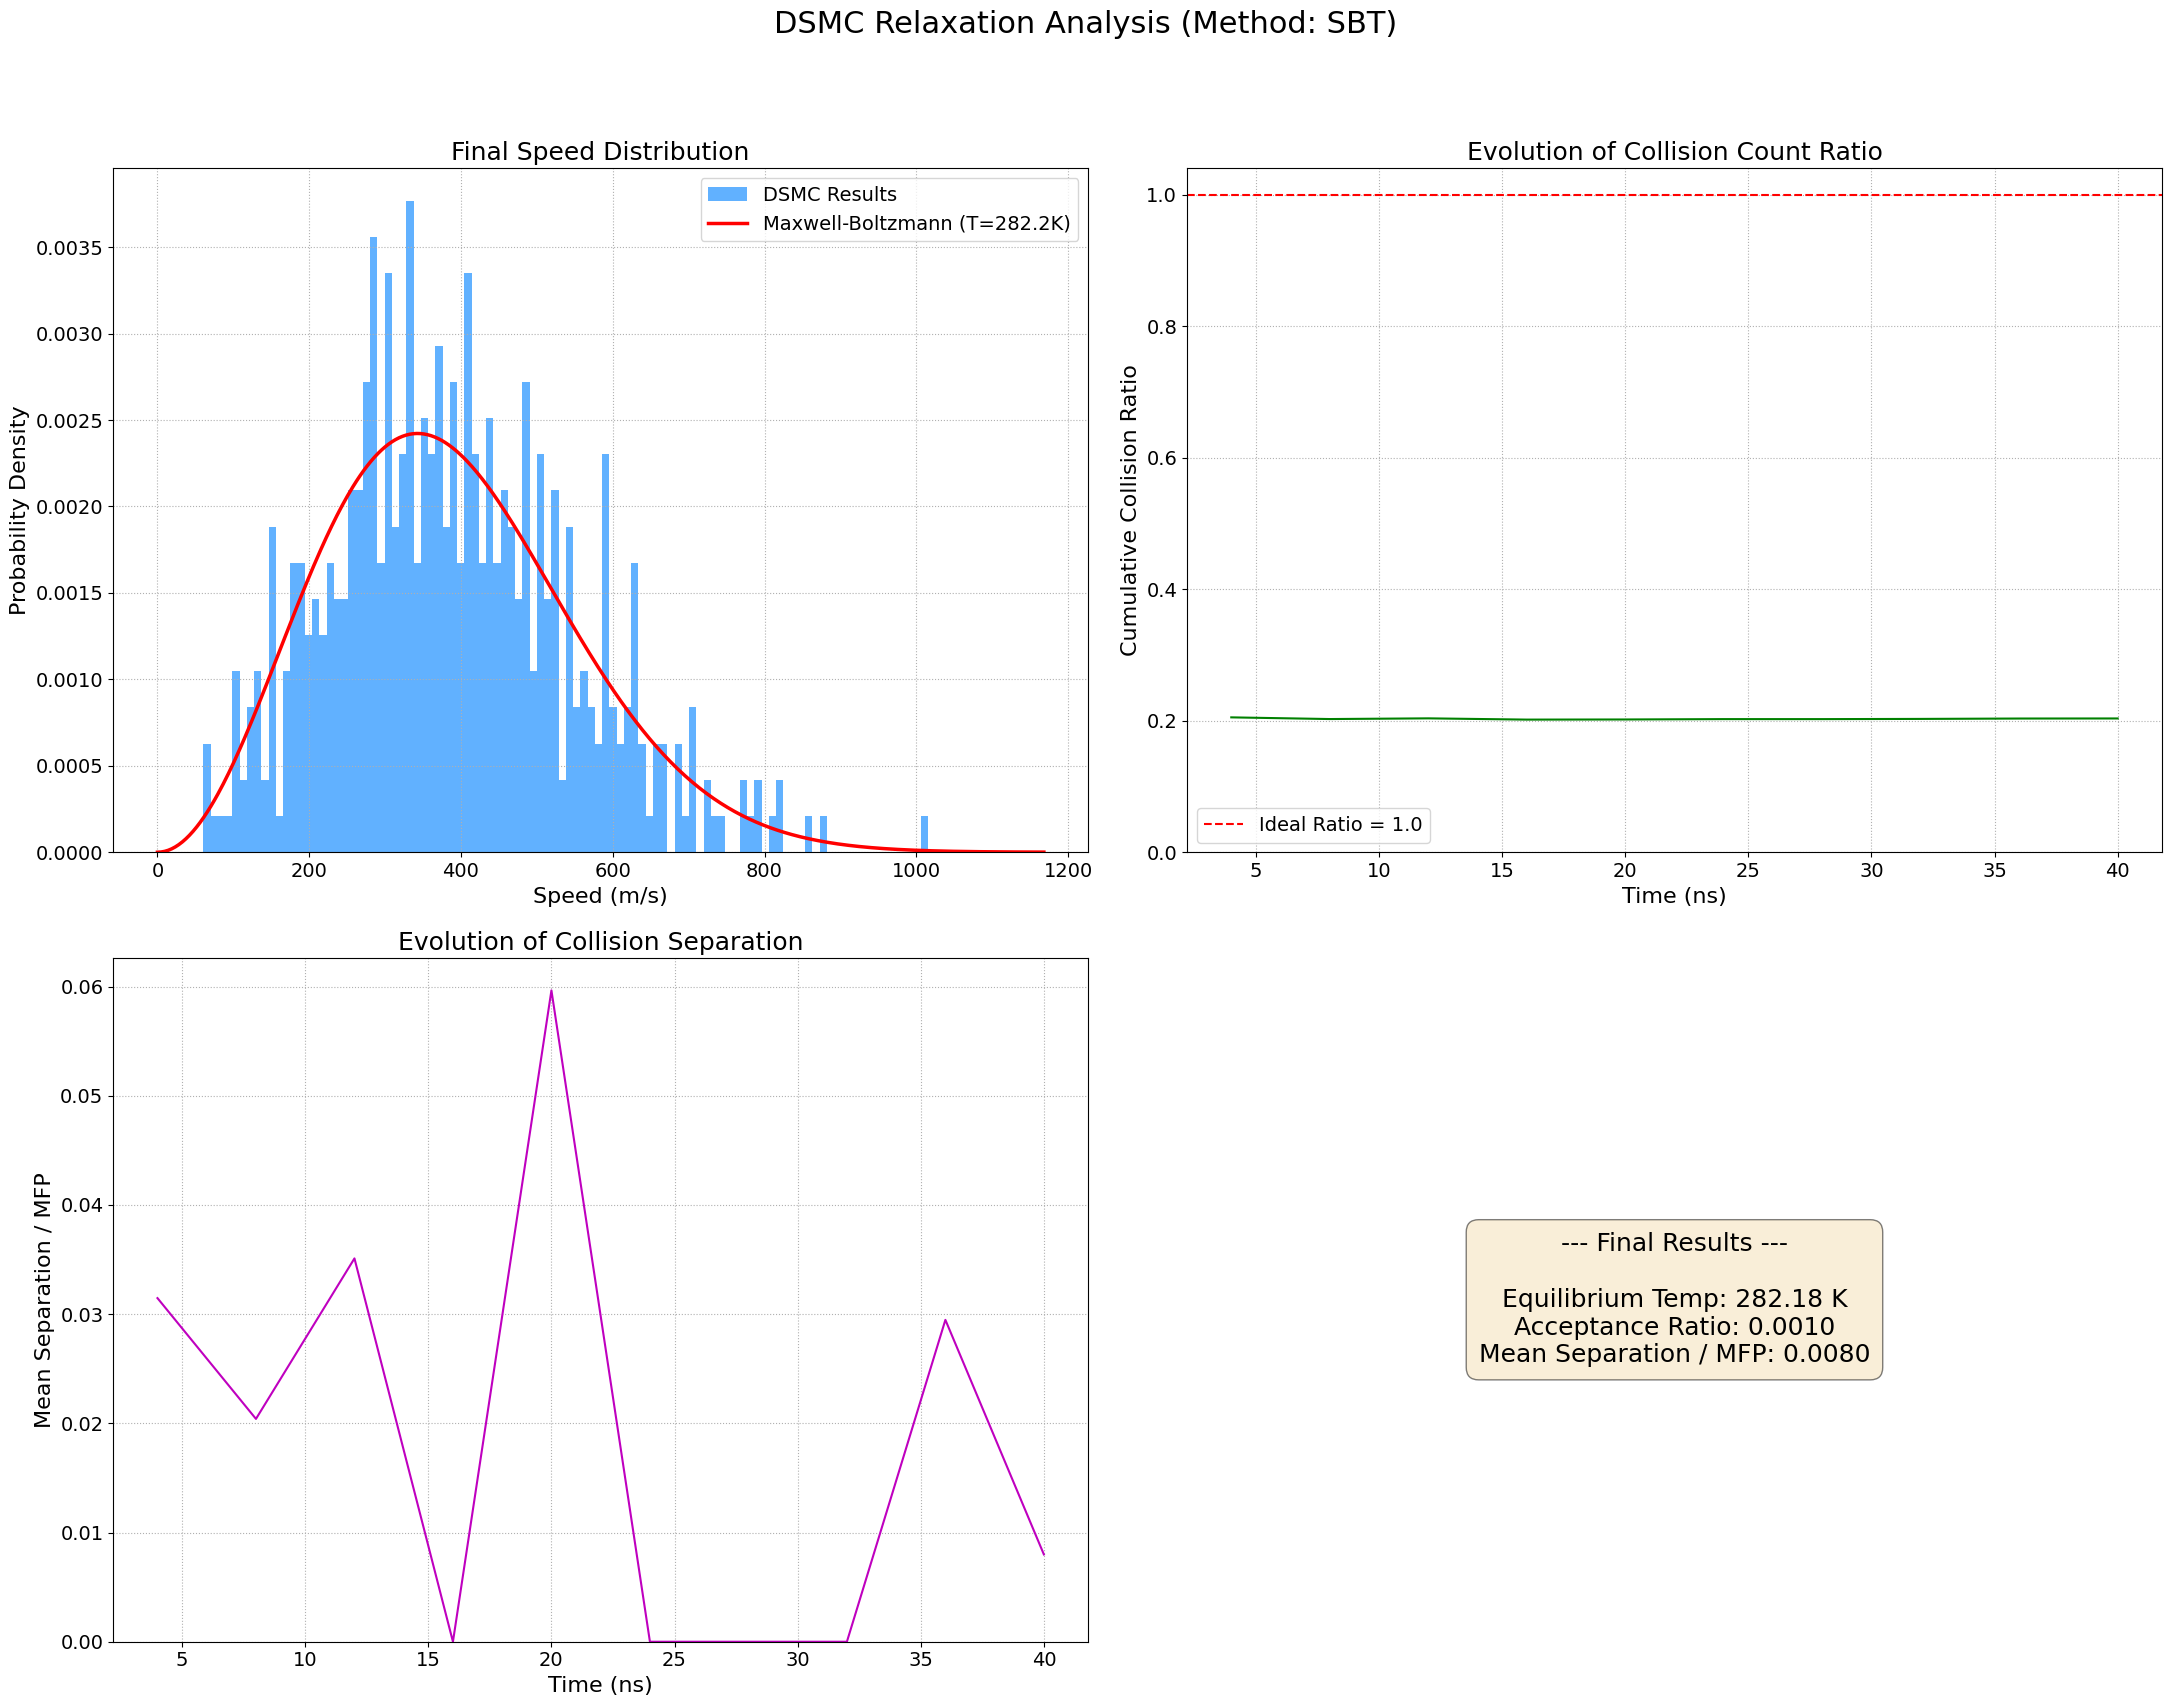

/tmp/ipython-input-2-331830444.py:417: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(); ax2.grid(True, linestyle=':')


Advanced stats plot saved as DSMC_Advanced_Stats_SBT.eps


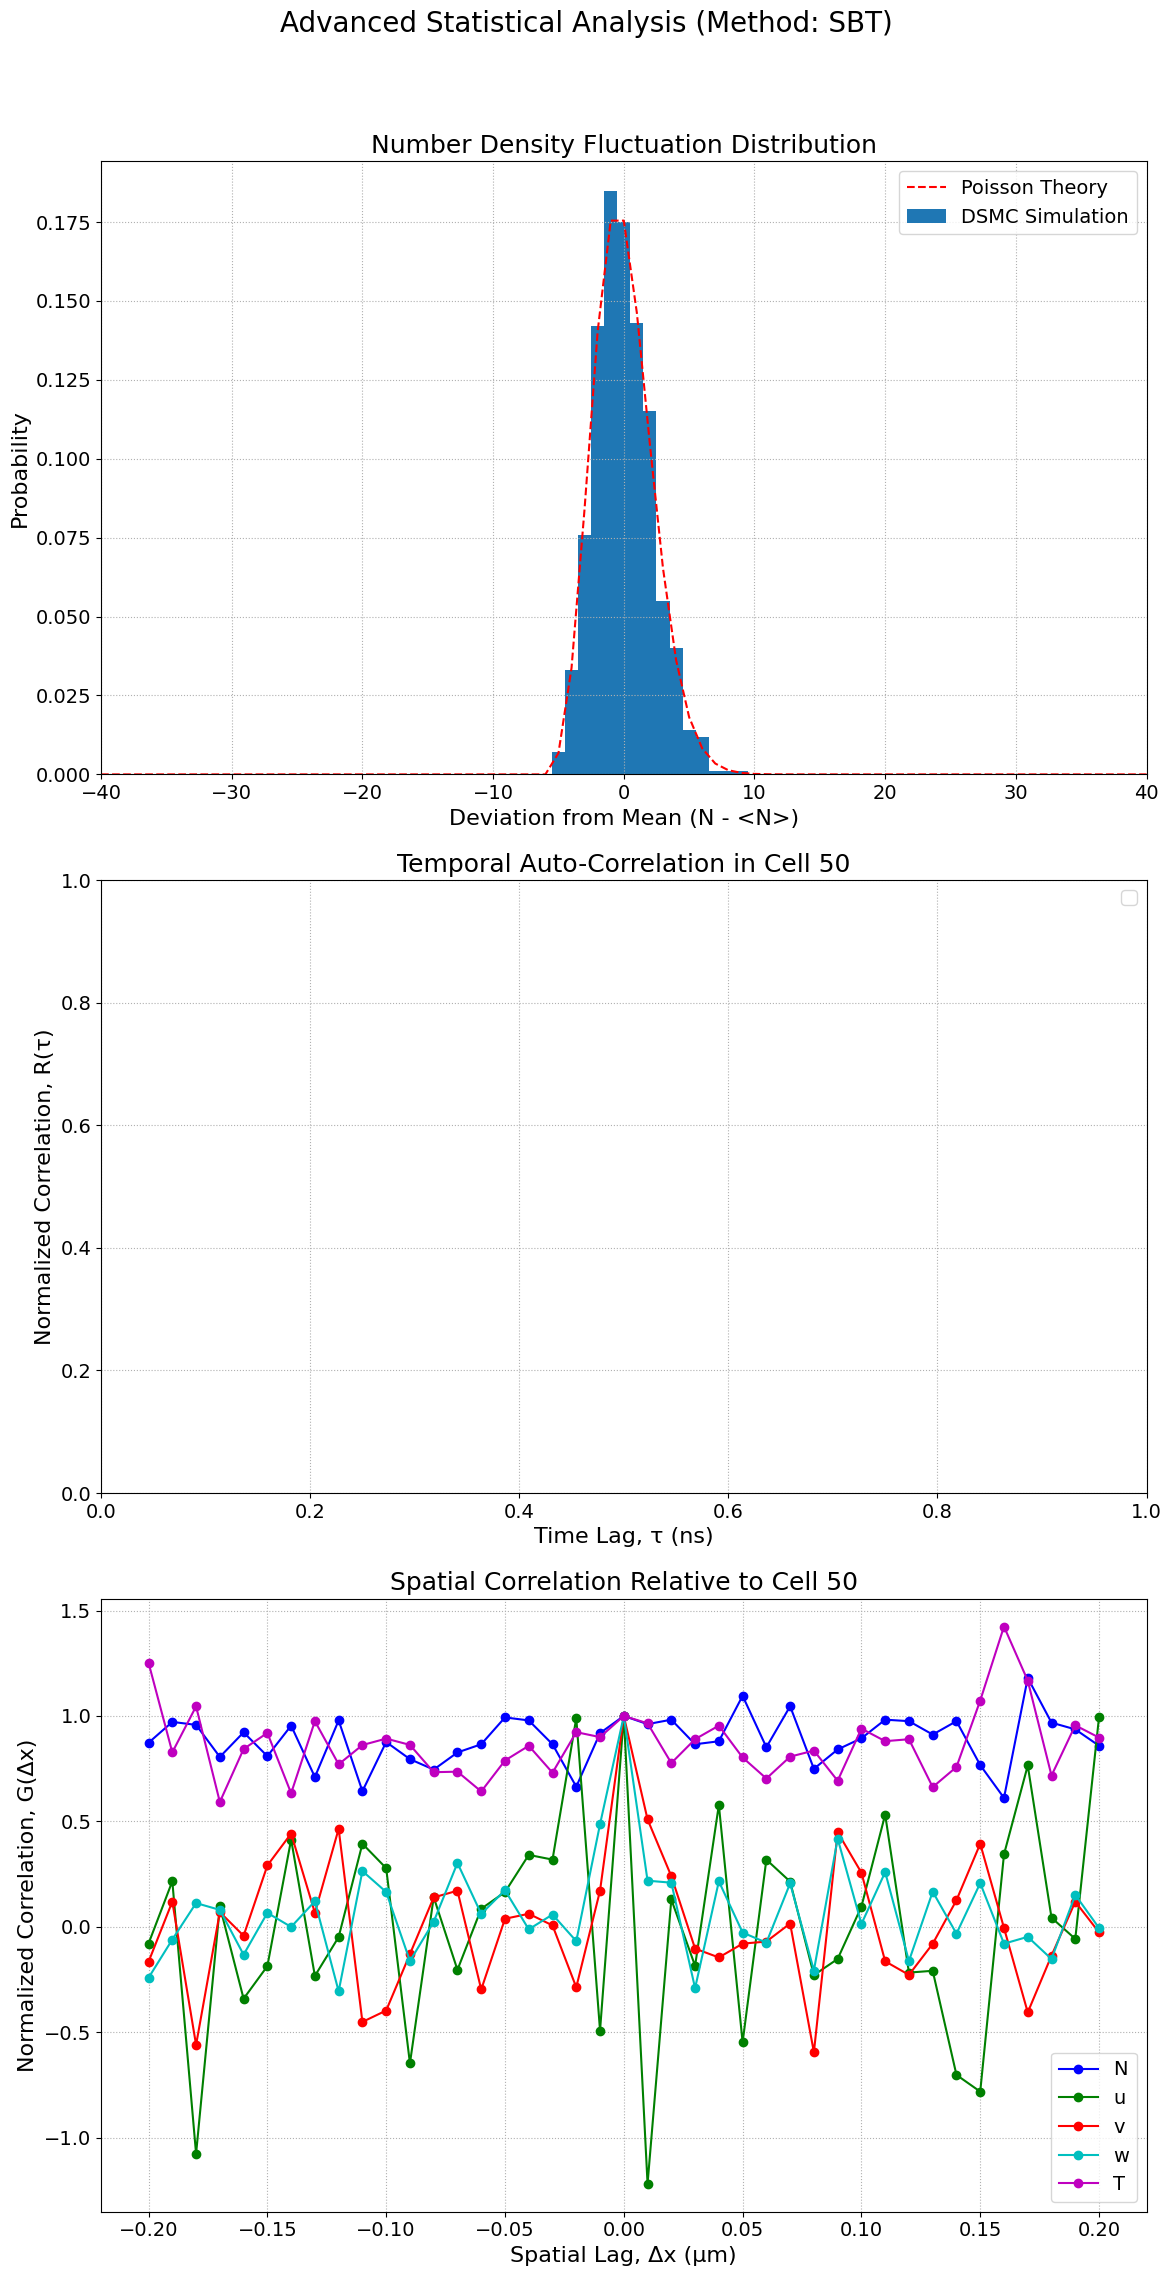

In [2]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V24.0 - FINAL, COMPLETE, AND CORRECTED CODE ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time
from scipy.special import gammaln

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.81
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 5
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# Derived parameters
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_INTERVAL = 4000

# --- ADVANCED STATISTICAL SAMPLING PARAMETERS ---
MTC = 20
MXC = 20
MAXD = 40
CENTRAL_CELL_IDX = NUM_CELLS_X // 2

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    # Gamma for OMEGA_VHS=0.81 is approx 1.153
    gamma_val = 1.153
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0, 0, 0.0
    n_selected = float(num_particles_in_cell - 1)
    sum_sep = 0.0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_sep += min(delta_x, lx - delta_x)
    return n_accepted, n_selected, sum_sep

@njit(nopython=True)
def perform_collisions(method, particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction, duplicate_check_array):
    n_accepted = 0
    n_selected = 0.0
    sum_separation = 0.0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell, 0.0, 0.0

    if method == 1: # SBT
        prob_const = fnum * dt / cell_vol
        n_selected = num_particles_in_cell * (num_particles_in_cell - 1) / 2.0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        if num_pairs == 0: return 0, sigma_g_max_cell, 0.0, 0.0
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                distance = min(delta_x, lx - delta_x)
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i,0], pairs[i,1]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        n_selected = float(num_collisions_to_perform)
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx, 0], pairs[selected_idx, 1]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_separation += min(delta_x, lx - delta_x)
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local:
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N - 1 or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol
        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)
            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            k_k = k_k_const * (N - (i + 1.0))
            collision_prob = k_k * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 5: # SSBT
        prob_const = fnum * dt / cell_vol
        multiplier = (num_particles_in_cell - 1.0) / 2.0
        n_selected = float(num_particles_in_cell)
        for i_local in range(num_particles_in_cell):
            p1_idx = indices_in_cell[i_local]
            j_local = rng_state.integers(0, num_particles_in_cell)
            while j_local == i_local:
                j_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx = indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 6: # SGBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        prob_const = fnum * dt / cell_vol
        multiplier = (N * (N - 1.0)) / (N_sel * 2.0)
        for i in range(N_sel):
            p1_idx = reordered_global_indices[i]
            j = rng_state.integers(0, N)
            while j == i:
                j = rng_state.integers(0, N)
            p2_idx = reordered_global_indices[j]
            if duplicate_check_array[p1_idx] == p2_idx:
                continue
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    duplicate_check_array[p1_idx] = p2_idx
                    duplicate_check_array[p2_idx] = p1_idx
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 7: # MFS
        cell_time = 0.0
        n_sel_counter = 0
        while cell_time < dt:
            num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
            if num_pairs_float < 1 or sigma_g_max_cell <= 0:
                break
            nu_max = num_pairs_float * fnum * sigma_g_max_cell / cell_vol
            delta_t_c = -np.log(1.0 - rng_state.random()) / nu_max
            cell_time += delta_t_c
            n_sel_counter += 1
            if cell_time < dt:
                p1_idx_local = rng_state.integers(0, num_particles_in_cell)
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                while p1_idx_local == p2_idx_local:
                    p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
                if sigma_g_current > sigma_g_max_cell:
                    sigma_g_max_cell = sigma_g_current
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
                elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, float(n_sel_counter), sum_separation

    elif method == 8: # NN
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)
        if n_selected == 0:
            return 0, sigma_g_max_cell, 0.0, 0.0
        N = num_particles_in_cell
        cell_positions = particles[indices_in_cell, 0]
        dist_matrix = np.full((N, N), np.finfo(np.float64).max, dtype=np.float64)
        for i in range(N):
            for j in range(i + 1, N):
                delta_x = np.abs(cell_positions[i] - cell_positions[j])
                dist = min(delta_x, lx - delta_x)
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist
        nearest_neighbor_map = np.argmin(dist_matrix, axis=1)
        for _ in range(num_pairs_to_select):
            p1_local_idx = rng_state.integers(0, N)
            p2_local_idx = nearest_neighbor_map[p1_local_idx]
            p1_idx, p2_idx = indices_in_cell[p1_local_idx], indices_in_cell[p2_local_idx]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    return 0, sigma_g_max_cell, 0.0, 0.0

@njit(nopython=True)
def calculate_total_theoretical_collisions(TOTAL_TIME, avg_temp, total_volume, fnum, n_density):
    sigma_ref = PI * D_REF_AR**2
    temp_factor = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    mean_speed_factor = np.sqrt( KB * T_REF_AR *PI/ (1 * MASS_AR))
    coll_freq_real = 2 * n_density**2 * sigma_ref * temp_factor * mean_speed_factor
    total_real_collisions = coll_freq_real * total_volume * TOTAL_TIME
    total_sim_collisions = total_real_collisions / fnum
    return total_sim_collisions

def plot_standard_results(sampled_speeds, final_temp, method_name, acceptance_ratio, sof_history, time_history, ratio_history):
    plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})
    fig, axes = plt.subplots(2, 2, figsize=(22, 18))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=22)
    ax1, ax2, ax3, ax4 = axes.flatten()

    if len(sampled_speeds) > 0:
        ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
        v_max_range = np.max(sampled_speeds) * 1.15
        v_theory = np.linspace(0, v_max_range, 500)
        pv_theory = (4 * np.pi * (MASS_AR / (2 * np.pi * KB * final_temp))**1.5 * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
        ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Maxwell-Boltzmann (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':')

    if time_history and ratio_history:
        ax2.plot(np.array(time_history) * 1e9, ratio_history, 'g-')
        ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Cumulative Collision Ratio'); ax2.set_title('Evolution of Collision Count Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    if time_history and sof_history:
        ax3.plot(np.array(time_history) * 1e9, sof_history, 'm-')
    ax3.set_xlabel('Time (ns)'); ax3.set_ylabel('Mean Separation / MFP'); ax3.set_title('Evolution of Collision Separation')
    ax3.grid(True, linestyle=':'); ax3.set_ylim(bottom=0)

    ax4.axis('off')
    final_sof = sof_history[-1] if sof_history else 0
    stats_text = (f"--- Final Results ---\n\n"
                  f"Equilibrium Temp: {final_temp:.2f} K\n"
                  f"Acceptance Ratio: {acceptance_ratio:.4f}\n"
                  f"Mean Separation / MFP: {final_sof:.4f}")
    ax4.text(0.5, 0.5, stats_text, ha='center', va='center', fontsize=18, bbox=dict(boxstyle="round,pad=0.5", fc="wheat", alpha=0.5))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    output_filename = f'DSMC_Combined_Results_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nCombined results plot saved as {output_filename}")
    plt.show()

def plot_advanced_stats(density_fluctuation_hist, temporal_corr_sums, spatial_corr_sums, nsmpt, nsmpx, navg_theory, method_name, dt, cell_width):
    plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})
    fig, axes = plt.subplots(3, 1, figsize=(12, 24))
    fig.suptitle(f'Advanced Statistical Analysis (Method: {method_name})', fontsize=20)

    ax1 = axes[0]
    dev_range = np.arange(-MAXD, MAXD + 1)
    total_samples = np.sum(density_fluctuation_hist)
    if total_samples > 0:
        prob_density_fluc = density_fluctuation_hist / total_samples
        ax1.bar(dev_range, prob_density_fluc, width=1.0, label='DSMC Simulation')
        k_values = dev_range + navg_theory
        valid_indices = k_values >= 0
        valid_k = k_values[valid_indices].astype(np.int64)
        if navg_theory > 0:
             log_poisson = valid_k * np.log(navg_theory) - navg_theory - gammaln(valid_k + 1)
             poisson_prob = np.zeros_like(k_values, dtype=float)
             poisson_prob[valid_indices] = np.exp(log_poisson)
             ax1.plot(dev_range, poisson_prob, 'r--', label='Poisson Theory')
    ax1.set_title('Number Density Fluctuation Distribution'); ax1.set_xlabel('Deviation from Mean (N - <N>)'); ax1.set_ylabel('Probability')
    ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_xlim(left=-MAXD, right=MAXD)

    ax2 = axes[1]
    time_lags = np.arange(-MTC, MTC + 1) * dt * SAMPLING_INTERVAL
    prop_labels = ['N', 'u', 'v', 'w', 'T']
    colors = ['b', 'g', 'r', 'c', 'm']
    if nsmpt > 0:
        for i in range(5):
            mean_val_sq = temporal_corr_sums[i, MTC] / nsmpt
            if mean_val_sq > 1e-9:
                normalized_corr = (temporal_corr_sums[i, :] / nsmpt) / mean_val_sq
                ax2.plot(time_lags * 1e9, normalized_corr, 'o-', color=colors[i], label=prop_labels[i])
    ax2.set_title(f'Temporal Auto-Correlation in Cell {CENTRAL_CELL_IDX}'); ax2.set_xlabel('Time Lag, τ (ns)'); ax2.set_ylabel('Normalized Correlation, R(τ)')
    ax2.legend(); ax2.grid(True, linestyle=':')

    ax3 = axes[2]
    space_lags = np.arange(-MXC, MXC + 1) * cell_width
    if nsmpx > 0:
        for i in range(5):
            norm_factor = spatial_corr_sums[i, MXC]
            if norm_factor > 1e-9:
                normalized_corr = spatial_corr_sums[i,:] / norm_factor
                ax3.plot(space_lags * 1e6, normalized_corr, 'o-', color=colors[i], label=prop_labels[i])
    ax3.set_title(f'Spatial Correlation Relative to Cell {CENTRAL_CELL_IDX}'); ax3.set_xlabel('Spatial Lag, Δx (μm)'); ax3.set_ylabel('Normalized Correlation, G(Δx)')
    ax3.legend(); ax3.grid(True, linestyle=':')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    output_filename = f'DSMC_Advanced_Stats_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"Advanced stats plot saved as {output_filename}")
    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX
    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)
    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT', 5: 'SSBT', 6: 'SGBT', 7: 'MFS', 8: 'NN'}
    collision_method_name = method_map.get(method_code, 'Unknown')
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18, dtype=np.float64)

    total_accepted_collisions, total_selected_pairs, total_collision_separation = 0.0, 0.0, 0.0
    density_fluctuation_hist = np.zeros(2 * MAXD + 1, dtype=np.int64)
    navg_theory = PARTICLES_PER_CELL_INIT
    temporal_samples_storage = np.zeros((5, 2 * MTC + 1))
    temporal_corr_sums = np.zeros((5, 2 * MTC + 1))
    nsmpt = 0
    spatial_corr_sums = np.zeros((5, 2 * MXC + 1))
    nsmpx = 0
    time_history, ratio_history, sof_history = [], [], []
    sampled_speeds_accumulator = []

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    speed_sampling_start_step = int(num_steps * 0.9)
    cell_width = LX / NUM_CELLS_X
    sigma_ref = PI * D_REF_AR**2
    mfp = 1 / (np.sqrt(2) * sigma_ref * N_DENSITY_REAL)

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
        duplicate_check_array = np.full(TOTAL_PARTICLES_SIM, -1, dtype=np.int64)

        step_accepted_collisions, step_selected_pairs, step_sum_separation = 0.0, 0.0, 0.0

        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_acc, new_sigma_g_max, n_sel, sum_sep = perform_collisions(
                method_code, particles, LX, indices_in_cell_i,
                CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state,
                sigma_g_max[i], n_sel_fraction, duplicate_check_array
            )
            sigma_g_max[i] = new_sigma_g_max
            step_accepted_collisions += n_acc
            step_selected_pairs += n_sel
            step_sum_separation += sum_sep

        total_accepted_collisions += step_accepted_collisions
        total_selected_pairs += step_selected_pairs
        total_collision_separation += step_sum_separation

        if step % SAMPLING_INTERVAL == 0 and step > MTC:
            current_time = step * DT
            time_history.append(current_time)

            total_theoretical = calculate_total_theoretical_collisions(current_time, T_INIT, LX, FNUM, N_DENSITY_REAL)
            if total_theoretical > 0:
                ratio_history.append(total_accepted_collisions / total_theoretical)
            else:
                ratio_history.append(0)

            if step_accepted_collisions > 0 and mfp > 0:
                sof_interval = (step_sum_separation / step_accepted_collisions) / mfp
                sof_history.append(sof_interval)
            else:
                sof_history.append(0)

            cell_counts = np.bincount(cell_indices, minlength=NUM_CELLS_X)
            deviations = cell_counts - int(navg_theory)
            for dev in deviations:
                if -MAXD <= dev <= MAXD:
                    density_fluctuation_hist[dev + MAXD] += 1

            current_cell_props = np.zeros((5, NUM_CELLS_X))
            for i in range(NUM_CELLS_X):
                indices = np.where(cell_indices == i)[0]
                N_i = len(indices)
                current_cell_props[0, i] = N_i
                if N_i > 1:
                    v_avg = np.mean(particles[indices, 1:4], axis=0)
                    current_cell_props[1:4, i] = v_avg
                    v_var = np.var(particles[indices, 1:4])
                    temp_i = (MASS_AR / (3 * KB)) * v_var * 3
                    current_cell_props[4, i] = temp_i

            temporal_samples_storage[:, :-1] = temporal_samples_storage[:, 1:]
            temporal_samples_storage[:, -1] = current_cell_props[:, CENTRAL_CELL_IDX]

            nsmpt += 1
            center_values_t = temporal_samples_storage[:, MTC]
            for lag in range(2 * MTC + 1):
                past_values = temporal_samples_storage[:, lag]
                temporal_corr_sums[:, lag] += center_values_t * past_values

            nsmpx += 1
            center_props_s = current_cell_props[:, CENTRAL_CELL_IDX]
            for lag in range(-MXC, MXC + 1):
                cell_idx_to_compare = (CENTRAL_CELL_IDX + lag + NUM_CELLS_X) % NUM_CELLS_X
                compare_props = current_cell_props[:, cell_idx_to_compare]
                spatial_corr_sums[:, lag + MXC] += center_props_s * compare_props

        if step >= speed_sampling_start_step:
             if step % (SAMPLING_INTERVAL * 2) == 0:
                 sampled_speeds_accumulator.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")

    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nFinal Equilibrium Temperature: {final_temp:.2f} K")

    acceptance_ratio = total_accepted_collisions / total_selected_pairs if total_selected_pairs > 0 else 0
    mean_separation = total_collision_separation / total_accepted_collisions if total_accepted_collisions > 0 else 0
    sof = mean_separation / mfp if mfp > 0 else 0

    print(f"Total Collisions Accepted: {int(total_accepted_collisions)}")
    print(f"Total Pairs Selected: {int(total_selected_pairs)}")
    print(f"Collision Acceptance Ratio: {acceptance_ratio:.4f}")
    print(f"Mean Free Path (MFP): {mfp:.4e} m")
    print(f"Mean Collision Separation / MFP (SoF): {sof:.4f}")

    if sampled_speeds_accumulator:
        plot_standard_results(np.array(sampled_speeds_accumulator), final_temp, collision_method_name, acceptance_ratio, sof_history, time_history, ratio_history)

    plot_advanced_stats(density_fluctuation_hist, temporal_corr_sums, spatial_corr_sums, nsmpt, nsmpx, navg_theory, collision_method_name, DT, cell_width)

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: ")
        if choice in ['1', '2', '3', '4', '5', '6', '7', '8']:
            n_sel_fraction = 0.5
            if choice in ['4', '6']:
                try:
                    n_sel_input = float(input(f"Enter the N_sel fraction for { {4:'GBT', 6:'SGBT'}[int(choice)] } (e.g., 0.33 for N/3): "))
                    if 0 < n_sel_input < 1:
                        n_sel_fraction = n_sel_input
                    else:
                        print("Invalid fraction. Using default value of 0.33.")
                        n_sel_fraction = 0.33
                except ValueError:
                    print("Invalid input. Using default value of 0.33.")
                    n_sel_fraction = 0.33

            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=n_sel_fraction)
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: 3
--- DSMC Relaxation using method: NTC ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 200 particles.
Step: 2000/20000...
Step: 4000/20000...
Step: 6000/20000...
Step: 8000/20000...
Step: 10000/20000...
Step: 12000/20000...
Step: 14000/20000...
Step: 16000/20000...
Step: 18000/20000...
Step: 20000/20000...

Simulation finished in 69.28 seconds.

Final Equilibrium Temperature: 280.51 K



Plot saved as DSMC_Frequency_Analysis_NTC.eps


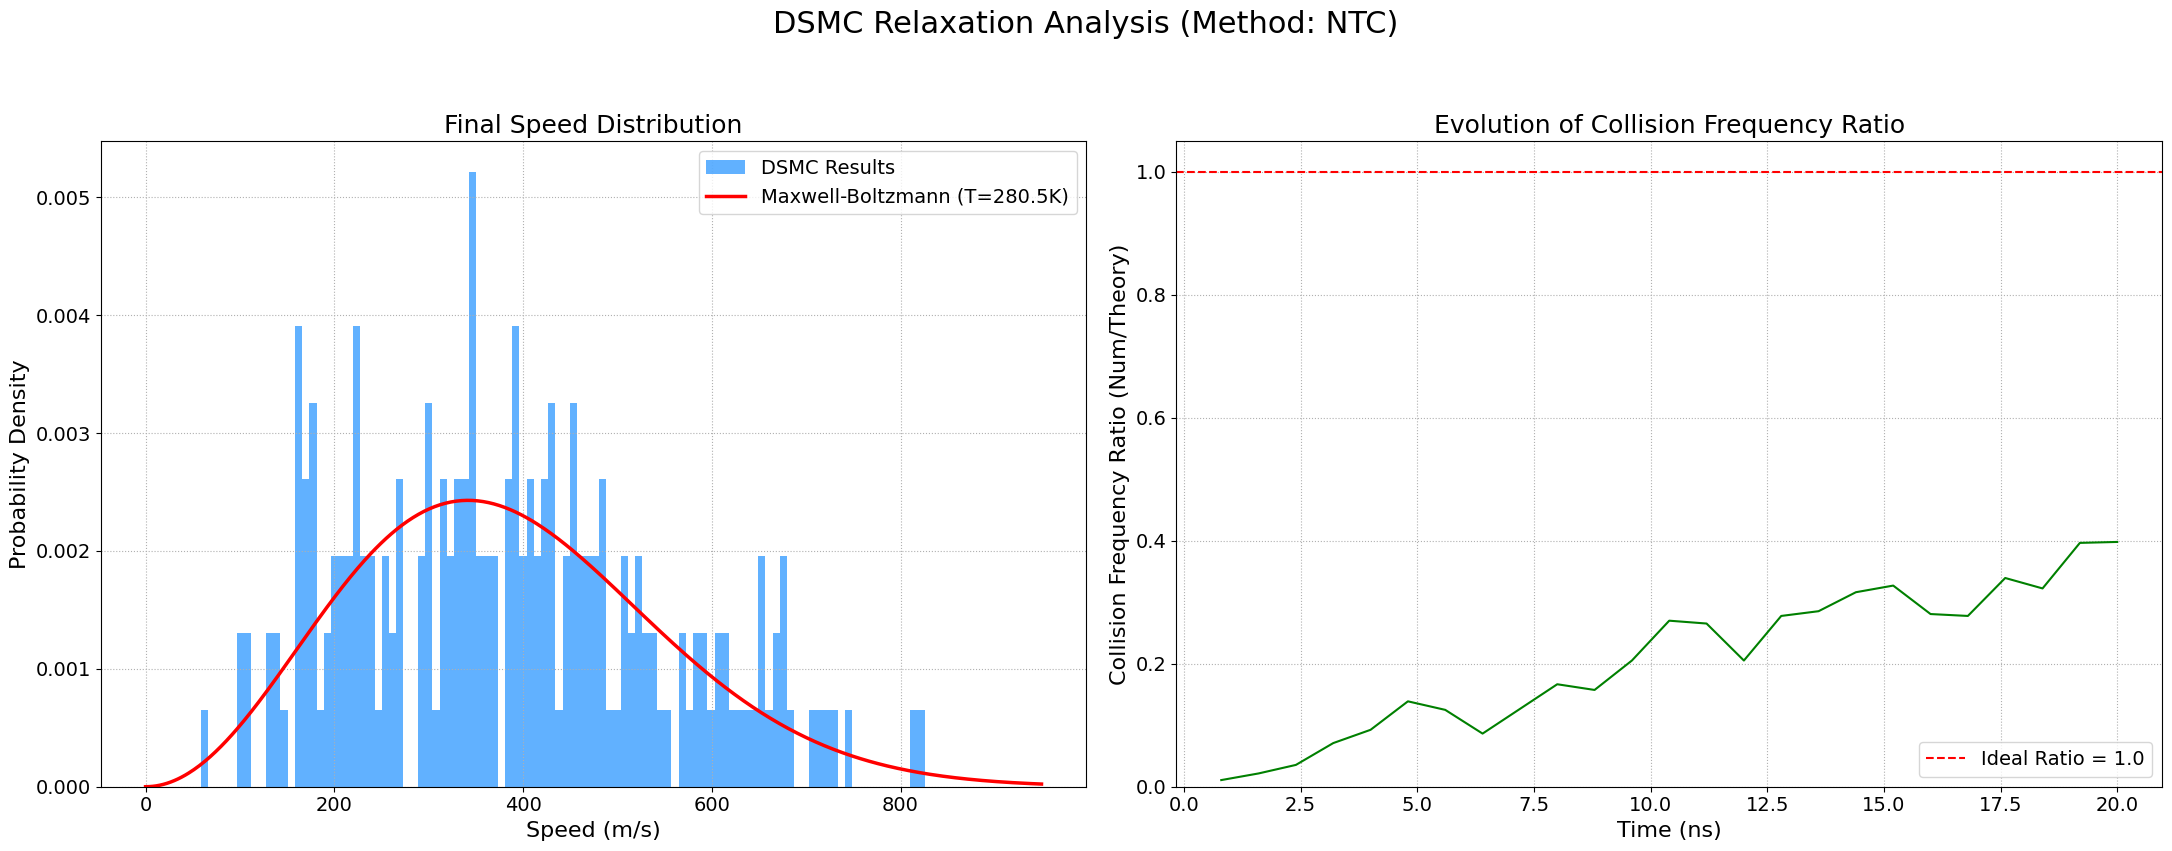

In [2]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V25.0 - EXACT Frequency Calculation as per User Request ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time
from scipy.special import gammaln

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 2 # As requested by user
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# Derived parameters
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 2.0e-8
SAMPLING_INTERVAL = 800

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

# --- ADVANCED STATISTICAL SAMPLING PARAMETERS ---
MTC = 20
MXC = 20
MAXD = 40
CENTRAL_CELL_IDX = NUM_CELLS_X // 2

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    # Gamma for OMEGA_VHS=0.81 is approx 1.153
    # gamma_val = 1.153
    # --- FIX: Calculate gamma function dynamically based on OMEGA_VHS ---
    #gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    gamma_val = 1.0
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0, 0, 0.0
    n_selected = float(num_particles_in_cell - 1)
    sum_sep = 0.0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_sep += min(delta_x, lx - delta_x)
    return n_accepted, n_selected, sum_sep

@njit(nopython=True)
def perform_collisions(method, particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction, duplicate_check_array):
    n_accepted = 0
    n_selected = 0.0
    sum_separation = 0.0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell, 0.0, 0.0

    if method == 1: # SBT
        prob_const = fnum * dt / cell_vol
        n_selected = num_particles_in_cell * (num_particles_in_cell - 1) / 2.0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        if num_pairs == 0: return 0, sigma_g_max_cell, 0.0, 0.0
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                distance = min(delta_x, lx - delta_x)
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i,0], pairs[i,1]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        n_selected = float(num_collisions_to_perform)
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx, 0], pairs[selected_idx, 1]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_separation += min(delta_x, lx - delta_x)
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local:
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N - 1 or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol
        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)
            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            k_k = k_k_const * (N - (i + 1.0))
            collision_prob = k_k * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 5: # SSBT
        prob_const = fnum * dt / cell_vol
        multiplier = (num_particles_in_cell - 1.0) / 2.0
        n_selected = float(num_particles_in_cell)
        for i_local in range(num_particles_in_cell):
            p1_idx = indices_in_cell[i_local]
            j_local = rng_state.integers(0, num_particles_in_cell)
            while j_local == i_local:
                j_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx = indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 6: # SGBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        prob_const = fnum * dt / cell_vol
        multiplier = (N * (N - 1.0)) / (N_sel * 2.0)
        for i in range(N_sel):
            p1_idx = reordered_global_indices[i]
            j = rng_state.integers(0, N)
            while j == i:
                j = rng_state.integers(0, N)
            p2_idx = reordered_global_indices[j]
            if duplicate_check_array[p1_idx] == p2_idx:
                continue
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    duplicate_check_array[p1_idx] = p2_idx
                    duplicate_check_array[p2_idx] = p1_idx
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 7: # MFS
        cell_time = 0.0
        n_sel_counter = 0
        while cell_time < dt:
            num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
            if num_pairs_float < 1 or sigma_g_max_cell <= 0:
                break
            nu_max = num_pairs_float * fnum * sigma_g_max_cell / cell_vol
            delta_t_c = -np.log(1.0 - rng_state.random()) / nu_max
            cell_time += delta_t_c
            n_sel_counter += 1
            if cell_time < dt:
                p1_idx_local = rng_state.integers(0, num_particles_in_cell)
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                while p1_idx_local == p2_idx_local:
                    p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
                if sigma_g_current > sigma_g_max_cell:
                    sigma_g_max_cell = sigma_g_current
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
                elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, float(n_sel_counter), sum_separation

    elif method == 8: # NN
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)
        if n_selected == 0:
            return 0, sigma_g_max_cell, 0.0, 0.0
        N = num_particles_in_cell
        cell_positions = particles[indices_in_cell, 0]
        dist_matrix = np.full((N, N), np.finfo(np.float64).max, dtype=np.float64)
        for i in range(N):
            for j in range(i + 1, N):
                delta_x = np.abs(cell_positions[i] - cell_positions[j])
                dist = min(delta_x, lx - delta_x)
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist
        nearest_neighbor_map = np.argmin(dist_matrix, axis=1)
        for _ in range(num_pairs_to_select):
            p1_local_idx = rng_state.integers(0, N)
            p2_local_idx = nearest_neighbor_map[p1_local_idx]
            p1_idx, p2_idx = indices_in_cell[p1_local_idx], indices_in_cell[p2_local_idx]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    return 0, sigma_g_max_cell, 0.0, 0.0

@njit(nopython=True)
def calculate_theoretical_collision_frequency(avg_temp, n_density):
    """Calculates theoretical collision frequency based on Eq. (9)"""
    d_ref_sq = D_REF_AR**2
    temp_ratio_term = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    sqrt_term = np.sqrt( np.pi * KB * avg_temp / (MASS_AR))
    cf_th = 4 * n_density * d_ref_sq * sqrt_term * temp_ratio_term
    # The print statement was removed because it is not supported inside a nopython-jitted function.
    return cf_th

def calculate_numerical_collision_frequency(total_sim_collisions, num_particles, elapsed_time):
    """Calculates numerical collision frequency based on Eq. (10)"""
    # All lines below are now correctly indented.
    if num_particles == 0 or elapsed_time == 0:
        return 0.0

    cf_num = total_sim_collisions / (0.5 * num_particles * elapsed_time)

    # The print statement was moved before the return or can be done outside the function.
    # For now, it is removed to keep the function clean.
    return cf_num

def plot_results(sampled_speeds, final_temp, method_name, freq_ratio_history, time_history):
    plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=22)
    ax1, ax2 = axes.flatten()

    if len(sampled_speeds) > 0:
        ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
        v_max_range = np.max(sampled_speeds) * 1.15
        v_theory = np.linspace(0, v_max_range, 500)
        pv_theory = (4 * np.pi * (MASS_AR / (2 * np.pi * KB * final_temp))**1.5 * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
        ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Maxwell-Boltzmann (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':')

    if time_history and freq_ratio_history:
        ax2.plot(np.array(time_history) * 1e9, freq_ratio_history, 'g-')
        ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Frequency Ratio (Num/Theory)'); ax2.set_title('Evolution of Collision Frequency Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    output_filename = f'DSMC_Frequency_Analysis_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nPlot saved as {output_filename}")
    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX
    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)
    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT', 5: 'SSBT', 6: 'SGBT', 7: 'MFS', 8: 'NN'}
    collision_method_name = method_map.get(method_code, 'Unknown')
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18, dtype=np.float64)

    total_accepted_collisions = 0.0
    last_sampled_total_collisions = 0.0
    time_history, freq_ratio_history = [], []
    sampled_speeds_accumulator = []

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    speed_sampling_start_step = int(TOTAL_TIME * 0.9 / DT)

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX

        step_accepted_collisions = 0
        duplicate_check_array = np.full(TOTAL_PARTICLES_SIM, -1, dtype=np.int64)
        cell_indices = (particles[:, 0] / (LX / NUM_CELLS_X)).astype(np.int64)

        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_acc, new_sigma_g_max, _, _ = perform_collisions(
                method_code, particles, LX, indices_in_cell_i,
                CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state,
                sigma_g_max[i], n_sel_fraction, duplicate_check_array
            )
            sigma_g_max[i] = new_sigma_g_max
            step_accepted_collisions += n_acc

        total_accepted_collisions += step_accepted_collisions

        if step % SAMPLING_INTERVAL == 0 and step > 0:
            current_time = step * DT
            time_history.append(current_time)

            collisions_this_interval = total_accepted_collisions - last_sampled_total_collisions
            time_this_interval = SAMPLING_INTERVAL * DT

            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))

            cf_numerical = calculate_numerical_collision_frequency(collisions_this_interval, TOTAL_PARTICLES_SIM, time_this_interval)
            cf_theoretical = calculate_theoretical_collision_frequency(current_temp, N_DENSITY_REAL)

            ratio = cf_numerical / cf_theoretical if cf_theoretical > 0 else 0
            freq_ratio_history.append(ratio)

            last_sampled_total_collisions = total_accepted_collisions

        if step >= speed_sampling_start_step and step % (SAMPLING_INTERVAL * 5) == 0:
             sampled_speeds_accumulator.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")

    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nFinal Equilibrium Temperature: {final_temp:.2f} K")

    if sampled_speeds_accumulator:
        plot_results(np.array(sampled_speeds_accumulator), final_temp, collision_method_name, freq_ratio_history, time_history)

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: ")
        if choice in ['1', '2', '3', '4', '5', '6', '7', '8']:
            n_sel_fraction = 0.5
            if choice in ['4', '6']:
                try:
                    n_sel_input = float(input(f"Enter the N_sel fraction for { {4:'GBT', 6:'SGBT'}[int(choice)] } (e.g., 0.33 for N/3): "))
                    if 0 < n_sel_input < 1:
                        n_sel_fraction = n_sel_input
                    else:
                        print("Invalid fraction. Using default value of 0.33.")
                        n_sel_fraction = 0.33
                except ValueError:
                    print("Invalid input. Using default value of 0.33.")
                    n_sel_fraction = 0.33

            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=n_sel_fraction)
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: 2
--- DSMC Relaxation using method: DCP ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 200 particles.
Step: 2000/20000...
Step: 4000/20000...
Step: 6000/20000...
Step: 8000/20000...
Step: 10000/20000...
Step: 12000/20000...
Step: 14000/20000...
Step: 16000/20000...
Step: 18000/20000...
Step: 20000/20000...

Simulation finished in 75.79 seconds.

Final Equilibrium Temperature: 280.51 K



Plot saved as DSMC_Frequency_Analysis_DCP.eps


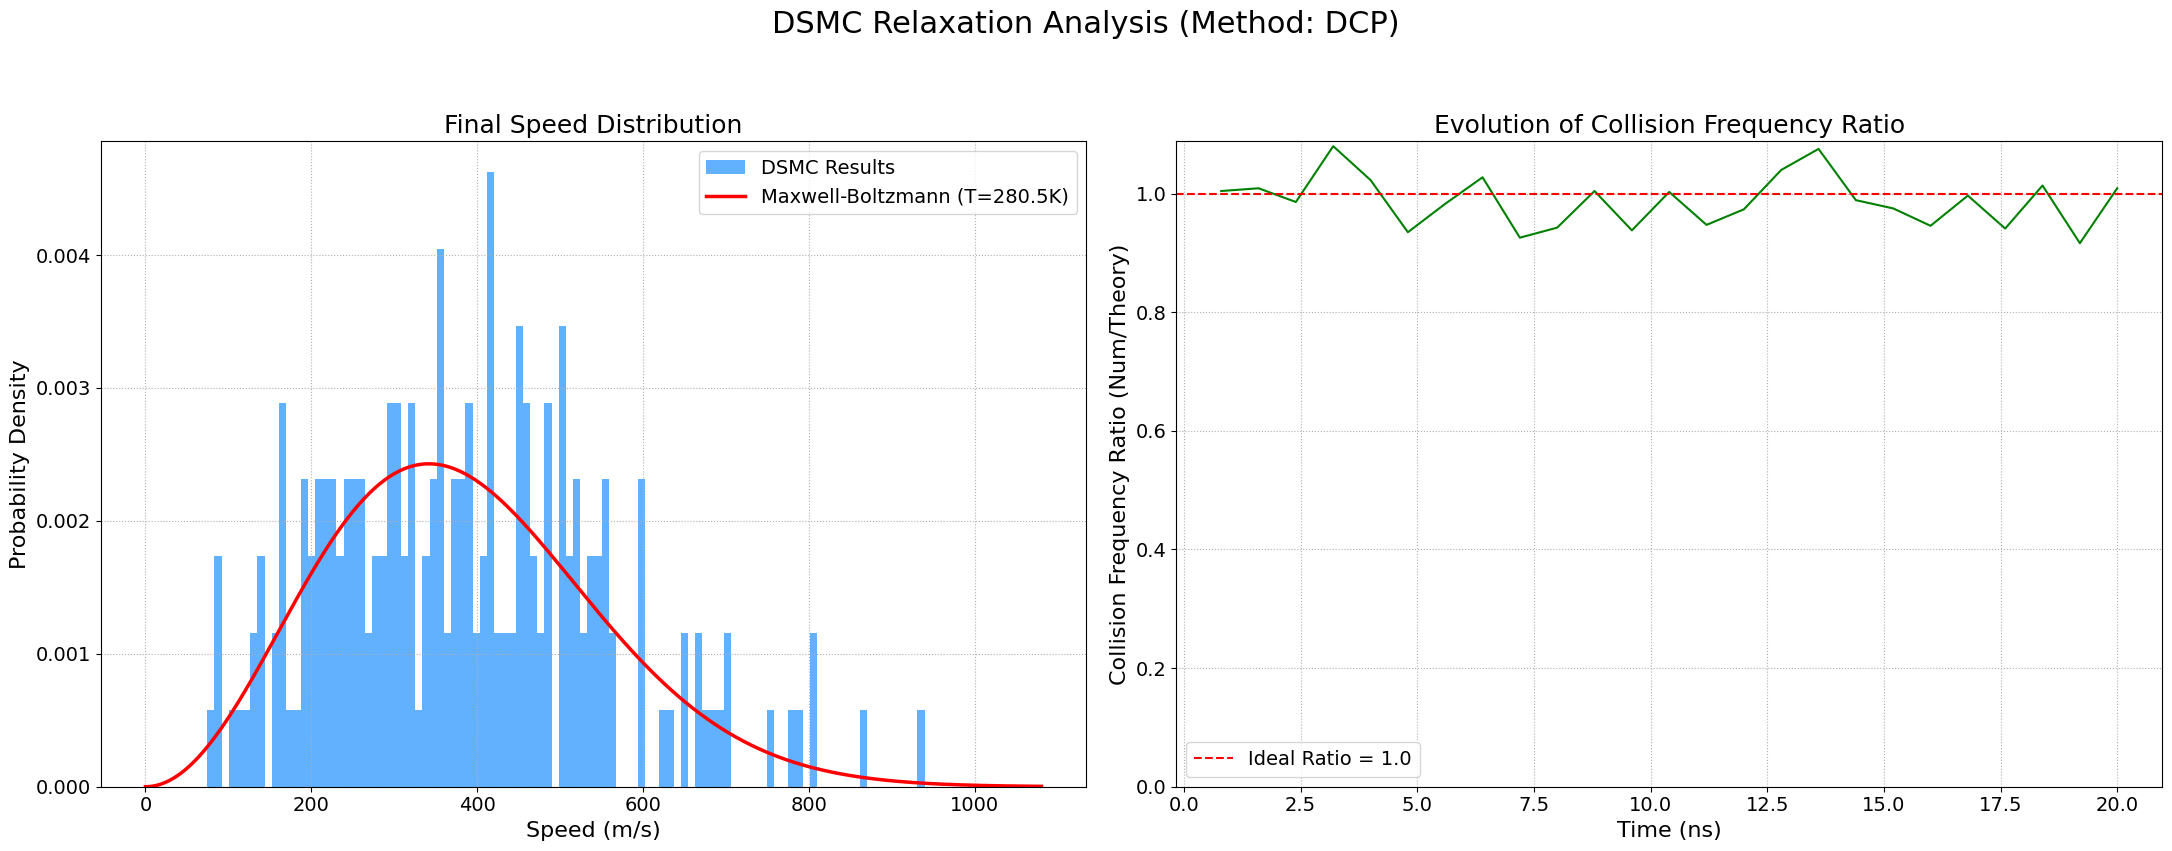

In [3]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V25.0 - EXACT Frequency Calculation as per User Request ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time
from scipy.special import gammaln

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 2 # As requested by user
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# Derived parameters
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 2.0e-8
SAMPLING_INTERVAL = 800

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

# --- ADVANCED STATISTICAL SAMPLING PARAMETERS ---
MTC = 20
MXC = 20
MAXD = 40
CENTRAL_CELL_IDX = NUM_CELLS_X // 2

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    # Gamma for OMEGA_VHS=0.81 is approx 1.153
    # gamma_val = 1.153
    # --- FIX: Calculate gamma function dynamically based on OMEGA_VHS ---
    #gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    gamma_val = 1.0
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0, 0, 0.0
    n_selected = float(num_particles_in_cell - 1)
    sum_sep = 0.0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_sep += min(delta_x, lx - delta_x)
    return n_accepted, n_selected, sum_sep

@njit(nopython=True)
def perform_collisions(method, particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction, duplicate_check_array):
    n_accepted = 0
    n_selected = 0.0
    sum_separation = 0.0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell, 0.0, 0.0

    if method == 1: # SBT
        prob_const = fnum * dt / cell_vol
        n_selected = num_particles_in_cell * (num_particles_in_cell - 1) / 2.0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        if num_pairs == 0: return 0, sigma_g_max_cell, 0.0, 0.0
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                distance = min(delta_x, lx - delta_x)
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i,0], pairs[i,1]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        n_selected = float(num_collisions_to_perform)
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx, 0], pairs[selected_idx, 1]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_separation += min(delta_x, lx - delta_x)
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local:
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N - 1 or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol
        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)
            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            k_k = k_k_const * (N - (i + 1.0))
            collision_prob = k_k * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 5: # SSBT
        prob_const = fnum * dt / cell_vol
        multiplier = (num_particles_in_cell - 1.0) / 2.0
        n_selected = float(num_particles_in_cell)
        for i_local in range(num_particles_in_cell):
            p1_idx = indices_in_cell[i_local]
            j_local = rng_state.integers(0, num_particles_in_cell)
            while j_local == i_local:
                j_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx = indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 6: # SGBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        prob_const = fnum * dt / cell_vol
        multiplier = (N * (N - 1.0)) / (N_sel * 2.0)
        for i in range(N_sel):
            p1_idx = reordered_global_indices[i]
            j = rng_state.integers(0, N)
            while j == i:
                j = rng_state.integers(0, N)
            p2_idx = reordered_global_indices[j]
            if duplicate_check_array[p1_idx] == p2_idx:
                continue
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    duplicate_check_array[p1_idx] = p2_idx
                    duplicate_check_array[p2_idx] = p1_idx
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 7: # MFS
        cell_time = 0.0
        n_sel_counter = 0
        while cell_time < dt:
            num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
            if num_pairs_float < 1 or sigma_g_max_cell <= 0:
                break
            nu_max = num_pairs_float * fnum * sigma_g_max_cell / cell_vol
            delta_t_c = -np.log(1.0 - rng_state.random()) / nu_max
            cell_time += delta_t_c
            n_sel_counter += 1
            if cell_time < dt:
                p1_idx_local = rng_state.integers(0, num_particles_in_cell)
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                while p1_idx_local == p2_idx_local:
                    p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
                if sigma_g_current > sigma_g_max_cell:
                    sigma_g_max_cell = sigma_g_current
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
                elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, float(n_sel_counter), sum_separation

    elif method == 8: # NN
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)
        if n_selected == 0:
            return 0, sigma_g_max_cell, 0.0, 0.0
        N = num_particles_in_cell
        cell_positions = particles[indices_in_cell, 0]
        dist_matrix = np.full((N, N), np.finfo(np.float64).max, dtype=np.float64)
        for i in range(N):
            for j in range(i + 1, N):
                delta_x = np.abs(cell_positions[i] - cell_positions[j])
                dist = min(delta_x, lx - delta_x)
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist
        nearest_neighbor_map = np.argmin(dist_matrix, axis=1)
        for _ in range(num_pairs_to_select):
            p1_local_idx = rng_state.integers(0, N)
            p2_local_idx = nearest_neighbor_map[p1_local_idx]
            p1_idx, p2_idx = indices_in_cell[p1_local_idx], indices_in_cell[p2_local_idx]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    return 0, sigma_g_max_cell, 0.0, 0.0

@njit(nopython=True)
def calculate_theoretical_collision_frequency(avg_temp, n_density):
    """Calculates theoretical collision frequency based on Eq. (9)"""
    d_ref_sq = D_REF_AR**2
    temp_ratio_term = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    sqrt_term = np.sqrt( np.pi * KB * avg_temp / (MASS_AR))
    cf_th = 4 * n_density * d_ref_sq * sqrt_term * temp_ratio_term
    # The print statement was removed because it is not supported inside a nopython-jitted function.
    return cf_th

def calculate_numerical_collision_frequency(total_sim_collisions, num_particles, elapsed_time):
    """Calculates numerical collision frequency based on Eq. (10)"""
    # All lines below are now correctly indented.
    if num_particles == 0 or elapsed_time == 0:
        return 0.0

    cf_num = total_sim_collisions / (0.5 * num_particles * elapsed_time)

    # The print statement was moved before the return or can be done outside the function.
    # For now, it is removed to keep the function clean.
    return cf_num

def plot_results(sampled_speeds, final_temp, method_name, freq_ratio_history, time_history):
    plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=22)
    ax1, ax2 = axes.flatten()

    if len(sampled_speeds) > 0:
        ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
        v_max_range = np.max(sampled_speeds) * 1.15
        v_theory = np.linspace(0, v_max_range, 500)
        pv_theory = (4 * np.pi * (MASS_AR / (2 * np.pi * KB * final_temp))**1.5 * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
        ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Maxwell-Boltzmann (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':')

    if time_history and freq_ratio_history:
        ax2.plot(np.array(time_history) * 1e9, freq_ratio_history, 'g-')
        ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Frequency Ratio (Num/Theory)'); ax2.set_title('Evolution of Collision Frequency Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    output_filename = f'DSMC_Frequency_Analysis_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nPlot saved as {output_filename}")
    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX
    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)
    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT', 5: 'SSBT', 6: 'SGBT', 7: 'MFS', 8: 'NN'}
    collision_method_name = method_map.get(method_code, 'Unknown')
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18, dtype=np.float64)

    total_accepted_collisions = 0.0
    last_sampled_total_collisions = 0.0
    time_history, freq_ratio_history = [], []
    sampled_speeds_accumulator = []

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    speed_sampling_start_step = int(TOTAL_TIME * 0.9 / DT)

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX

        step_accepted_collisions = 0
        duplicate_check_array = np.full(TOTAL_PARTICLES_SIM, -1, dtype=np.int64)
        cell_indices = (particles[:, 0] / (LX / NUM_CELLS_X)).astype(np.int64)

        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_acc, new_sigma_g_max, _, _ = perform_collisions(
                method_code, particles, LX, indices_in_cell_i,
                CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state,
                sigma_g_max[i], n_sel_fraction, duplicate_check_array
            )
            sigma_g_max[i] = new_sigma_g_max
            step_accepted_collisions += n_acc

        total_accepted_collisions += step_accepted_collisions

        if step % SAMPLING_INTERVAL == 0 and step > 0:
            current_time = step * DT
            time_history.append(current_time)

            collisions_this_interval = total_accepted_collisions - last_sampled_total_collisions
            time_this_interval = SAMPLING_INTERVAL * DT

            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))

            cf_numerical = calculate_numerical_collision_frequency(collisions_this_interval, TOTAL_PARTICLES_SIM, time_this_interval)
            cf_theoretical = calculate_theoretical_collision_frequency(current_temp, N_DENSITY_REAL)

            ratio = cf_numerical / cf_theoretical if cf_theoretical > 0 else 0
            freq_ratio_history.append(ratio)

            last_sampled_total_collisions = total_accepted_collisions

        if step >= speed_sampling_start_step and step % (SAMPLING_INTERVAL * 5) == 0:
             sampled_speeds_accumulator.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")

    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nFinal Equilibrium Temperature: {final_temp:.2f} K")

    if sampled_speeds_accumulator:
        plot_results(np.array(sampled_speeds_accumulator), final_temp, collision_method_name, freq_ratio_history, time_history)

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: ")
        if choice in ['1', '2', '3', '4', '5', '6', '7', '8']:
            n_sel_fraction = 0.5
            if choice in ['4', '6']:
                try:
                    n_sel_input = float(input(f"Enter the N_sel fraction for { {4:'GBT', 6:'SGBT'}[int(choice)] } (e.g., 0.33 for N/3): "))
                    if 0 < n_sel_input < 1:
                        n_sel_fraction = n_sel_input
                    else:
                        print("Invalid fraction. Using default value of 0.33.")
                        n_sel_fraction = 0.33
                except ValueError:
                    print("Invalid input. Using default value of 0.33.")
                    n_sel_fraction = 0.33

            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=n_sel_fraction)
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: 1
--- DSMC Relaxation using method: SBT ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 200 particles.
Step: 4000/40000...
Step: 8000/40000...
Step: 12000/40000...
Step: 16000/40000...
Step: 20000/40000...
Step: 24000/40000...
Step: 28000/40000...
Step: 32000/40000...
Step: 36000/40000...
Step: 40000/40000...

Simulation finished in 115.55 seconds.

Final Equilibrium Temperature: 280.51 K



Plot saved as DSMC_Frequency_Analysis_SBT.eps


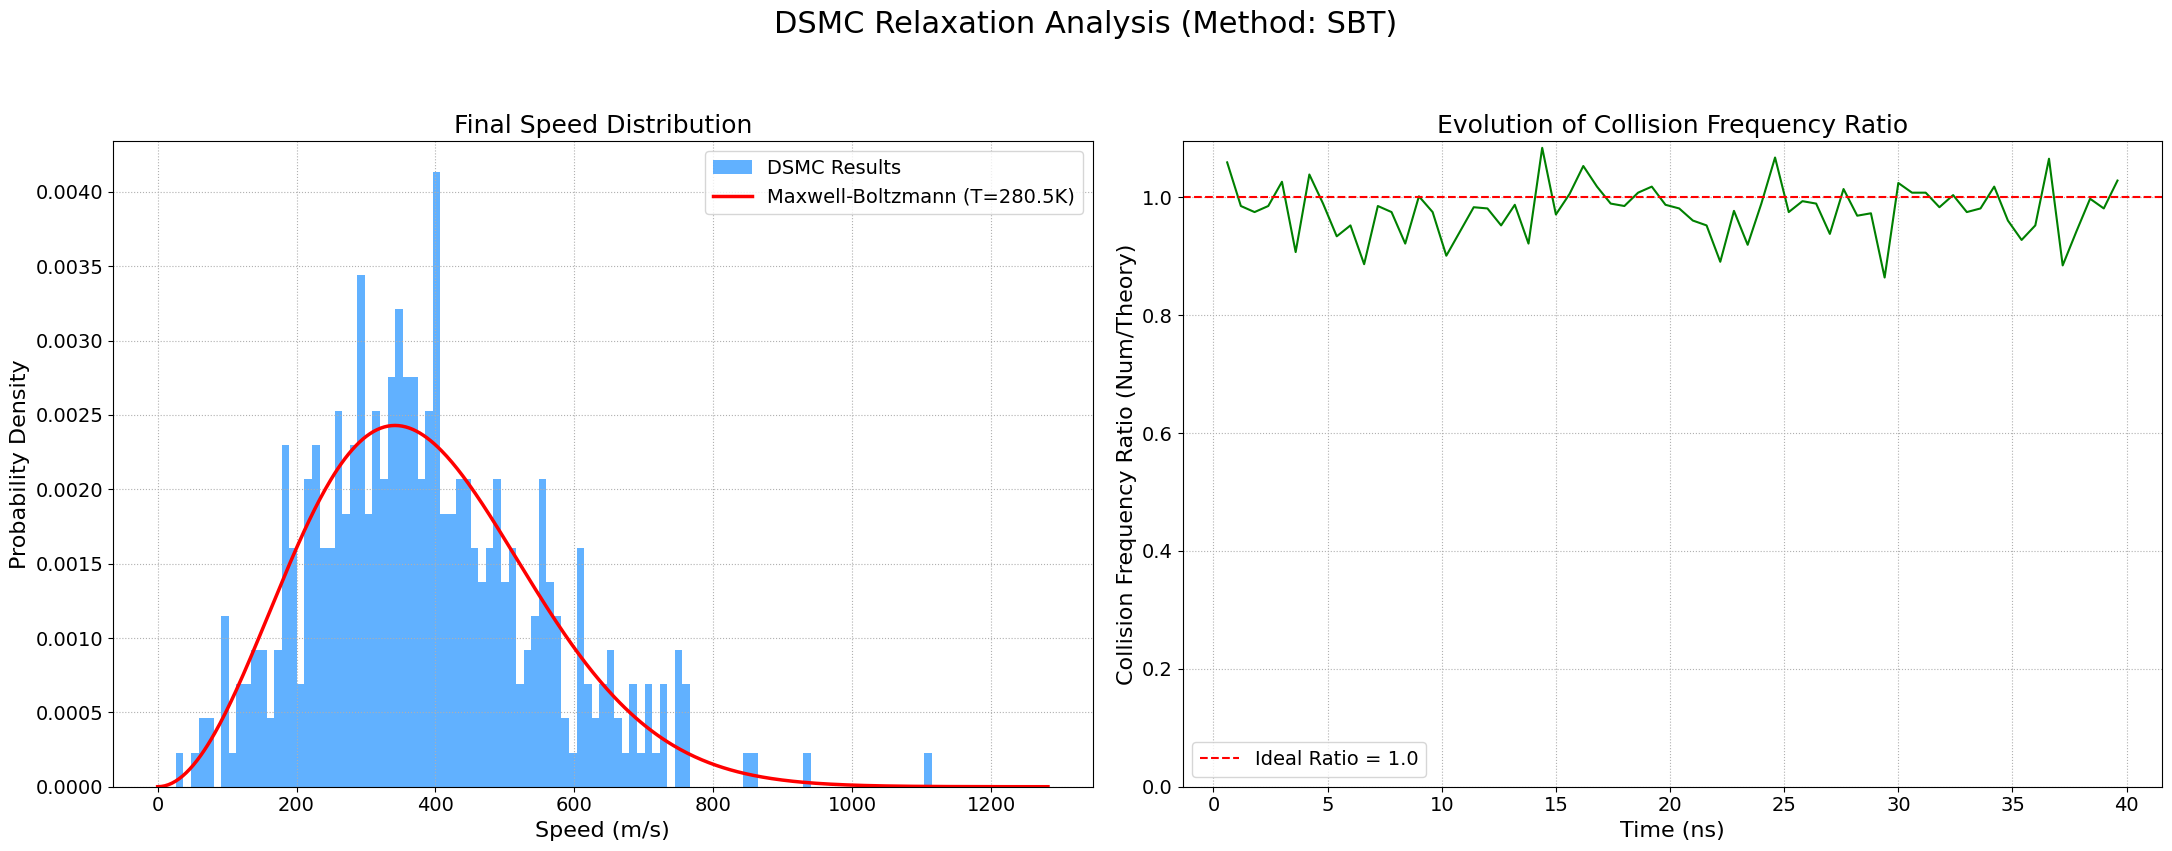

In [4]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V25.0 - EXACT Frequency Calculation as per User Request ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time
from scipy.special import gammaln

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 2 # As requested by user
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# Derived parameters
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 4.0e-8
SAMPLING_INTERVAL = 600

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    a = 1.0
    y = x
    if y < 1.0: a = a / y
    else:
        while y >= 1.0:
            y = y - 1.0
            a = a * (y + 1.0)
    gamma_val = a * (1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5)
    return gamma_val

# --- ADVANCED STATISTICAL SAMPLING PARAMETERS ---
MTC = 20
MXC = 20
MAXD = 40
CENTRAL_CELL_IDX = NUM_CELLS_X // 2

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    # Gamma for OMEGA_VHS=0.81 is approx 1.153
    # gamma_val = 1.153
    # --- FIX: Calculate gamma function dynamically based on OMEGA_VHS ---
    #gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    gamma_val = 1.0
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

@njit(nopython=True)
def standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0, 0, 0.0
    n_selected = float(num_particles_in_cell - 1)
    sum_sep = 0.0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_sep += min(delta_x, lx - delta_x)
    return n_accepted, n_selected, sum_sep

@njit(nopython=True)
def perform_collisions(method, particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction, duplicate_check_array):
    n_accepted = 0
    n_selected = 0.0
    sum_separation = 0.0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell, 0.0, 0.0

    if method == 1: # SBT
        prob_const = fnum * dt / cell_vol
        n_selected = num_particles_in_cell * (num_particles_in_cell - 1) / 2.0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        if num_pairs == 0: return 0, sigma_g_max_cell, 0.0, 0.0
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                distance = min(delta_x, lx - delta_x)
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i,0], pairs[i,1]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        n_selected = float(num_collisions_to_perform)
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx, 0], pairs[selected_idx, 1]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_separation += min(delta_x, lx - delta_x)
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local:
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N - 1 or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol
        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)
            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            k_k = k_k_const * (N - (i + 1.0))
            collision_prob = k_k * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 5: # SSBT
        prob_const = fnum * dt / cell_vol
        multiplier = (num_particles_in_cell - 1.0) / 2.0
        n_selected = float(num_particles_in_cell)
        for i_local in range(num_particles_in_cell):
            p1_idx = indices_in_cell[i_local]
            j_local = rng_state.integers(0, num_particles_in_cell)
            while j_local == i_local:
                j_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx = indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 6: # SGBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        prob_const = fnum * dt / cell_vol
        multiplier = (N * (N - 1.0)) / (N_sel * 2.0)
        for i in range(N_sel):
            p1_idx = reordered_global_indices[i]
            j = rng_state.integers(0, N)
            while j == i:
                j = rng_state.integers(0, N)
            p2_idx = reordered_global_indices[j]
            if duplicate_check_array[p1_idx] == p2_idx:
                continue
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    duplicate_check_array[p1_idx] = p2_idx
                    duplicate_check_array[p2_idx] = p1_idx
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 7: # MFS
        cell_time = 0.0
        n_sel_counter = 0
        while cell_time < dt:
            num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
            if num_pairs_float < 1 or sigma_g_max_cell <= 0:
                break
            nu_max = num_pairs_float * fnum * sigma_g_max_cell / cell_vol
            delta_t_c = -np.log(1.0 - rng_state.random()) / nu_max
            cell_time += delta_t_c
            n_sel_counter += 1
            if cell_time < dt:
                p1_idx_local = rng_state.integers(0, num_particles_in_cell)
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                while p1_idx_local == p2_idx_local:
                    p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
                if sigma_g_current > sigma_g_max_cell:
                    sigma_g_max_cell = sigma_g_current
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
                elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, float(n_sel_counter), sum_separation

    elif method == 8: # NN
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)
        if n_selected == 0:
            return 0, sigma_g_max_cell, 0.0, 0.0
        N = num_particles_in_cell
        cell_positions = particles[indices_in_cell, 0]
        dist_matrix = np.full((N, N), np.finfo(np.float64).max, dtype=np.float64)
        for i in range(N):
            for j in range(i + 1, N):
                delta_x = np.abs(cell_positions[i] - cell_positions[j])
                dist = min(delta_x, lx - delta_x)
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist
        nearest_neighbor_map = np.argmin(dist_matrix, axis=1)
        for _ in range(num_pairs_to_select):
            p1_local_idx = rng_state.integers(0, N)
            p2_local_idx = nearest_neighbor_map[p1_local_idx]
            p1_idx, p2_idx = indices_in_cell[p1_local_idx], indices_in_cell[p2_local_idx]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    return 0, sigma_g_max_cell, 0.0, 0.0

@njit(nopython=True)
def calculate_theoretical_collision_frequency(avg_temp, n_density):
    """Calculates theoretical collision frequency based on Eq. (9)"""
    d_ref_sq = D_REF_AR**2
    temp_ratio_term = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    sqrt_term = np.sqrt( np.pi * KB * avg_temp / (MASS_AR))
    cf_th = 4 * n_density * d_ref_sq * sqrt_term * temp_ratio_term
    # The print statement was removed because it is not supported inside a nopython-jitted function.
    return cf_th

def calculate_numerical_collision_frequency(total_sim_collisions, num_particles, elapsed_time):
    """Calculates numerical collision frequency based on Eq. (10)"""
    # All lines below are now correctly indented.
    if num_particles == 0 or elapsed_time == 0:
        return 0.0

    cf_num = total_sim_collisions / (0.5 * num_particles * elapsed_time)

    # The print statement was moved before the return or can be done outside the function.
    # For now, it is removed to keep the function clean.
    return cf_num

def plot_results(sampled_speeds, final_temp, method_name, freq_ratio_history, time_history):
    plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=22)
    ax1, ax2 = axes.flatten()

    if len(sampled_speeds) > 0:
        ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
        v_max_range = np.max(sampled_speeds) * 1.15
        v_theory = np.linspace(0, v_max_range, 500)
        pv_theory = (4 * np.pi * (MASS_AR / (2 * np.pi * KB * final_temp))**1.5 * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
        ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Maxwell-Boltzmann (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':')

    if time_history and freq_ratio_history:
        ax2.plot(np.array(time_history) * 1e9, freq_ratio_history, 'g-')
        ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Frequency Ratio (Num/Theory)'); ax2.set_title('Evolution of Collision Frequency Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    output_filename = f'DSMC_Frequency_Analysis_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nPlot saved as {output_filename}")
    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX
    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)
    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT', 5: 'SSBT', 6: 'SGBT', 7: 'MFS', 8: 'NN'}
    collision_method_name = method_map.get(method_code, 'Unknown')
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18, dtype=np.float64)

    total_accepted_collisions = 0.0
    last_sampled_total_collisions = 0.0
    time_history, freq_ratio_history = [], []
    sampled_speeds_accumulator = []

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    speed_sampling_start_step = int(TOTAL_TIME * 0.9 / DT)

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX

        step_accepted_collisions = 0
        duplicate_check_array = np.full(TOTAL_PARTICLES_SIM, -1, dtype=np.int64)
        cell_indices = (particles[:, 0] / (LX / NUM_CELLS_X)).astype(np.int64)

        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_acc, new_sigma_g_max, _, _ = perform_collisions(
                method_code, particles, LX, indices_in_cell_i,
                CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state,
                sigma_g_max[i], n_sel_fraction, duplicate_check_array
            )
            sigma_g_max[i] = new_sigma_g_max
            step_accepted_collisions += n_acc

        total_accepted_collisions += step_accepted_collisions

        if step % SAMPLING_INTERVAL == 0 and step > 0:
            current_time = step * DT
            time_history.append(current_time)

            collisions_this_interval = total_accepted_collisions - last_sampled_total_collisions
            time_this_interval = SAMPLING_INTERVAL * DT

            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))

            cf_numerical = calculate_numerical_collision_frequency(collisions_this_interval, TOTAL_PARTICLES_SIM, time_this_interval)
            cf_theoretical = calculate_theoretical_collision_frequency(current_temp, N_DENSITY_REAL)

            ratio = cf_numerical / cf_theoretical if cf_theoretical > 0 else 0
            freq_ratio_history.append(ratio)

            last_sampled_total_collisions = total_accepted_collisions

        if step >= speed_sampling_start_step and step % (SAMPLING_INTERVAL * 5) == 0:
             sampled_speeds_accumulator.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")

    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nFinal Equilibrium Temperature: {final_temp:.2f} K")

    if sampled_speeds_accumulator:
        plot_results(np.array(sampled_speeds_accumulator), final_temp, collision_method_name, freq_ratio_history, time_history)

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: ")
        if choice in ['1', '2', '3', '4', '5', '6', '7', '8']:
            n_sel_fraction = 0.5
            if choice in ['4', '6']:
                try:
                    n_sel_input = float(input(f"Enter the N_sel fraction for { {4:'GBT', 6:'SGBT'}[int(choice)] } (e.g., 0.33 for N/3): "))
                    if 0 < n_sel_input < 1:
                        n_sel_fraction = n_sel_input
                    else:
                        print("Invalid fraction. Using default value of 0.33.")
                        n_sel_fraction = 0.33
                except ValueError:
                    print("Invalid input. Using default value of 0.33.")
                    n_sel_fraction = 0.33

            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=n_sel_fraction)
            break
        else:
            print("Invalid input.")

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: 5
--- DSMC Relaxation using method: SSBT ---
Initializing particles with Maxwell-Boltzmann velocity distribution...
Initialized 2000 particles.
Step: 2000/20000...
Step: 4000/20000...
Step: 6000/20000...
Step: 8000/20000...
Step: 10000/20000...
Step: 12000/20000...
Step: 14000/20000...
Step: 16000/20000...
Step: 18000/20000...
Step: 20000/20000...

Simulation finished in 83.13 seconds.

Final Equilibrium Temperature: 273.07 K



Plot saved as DSMC_Frequency_Analysis_SSBT.eps


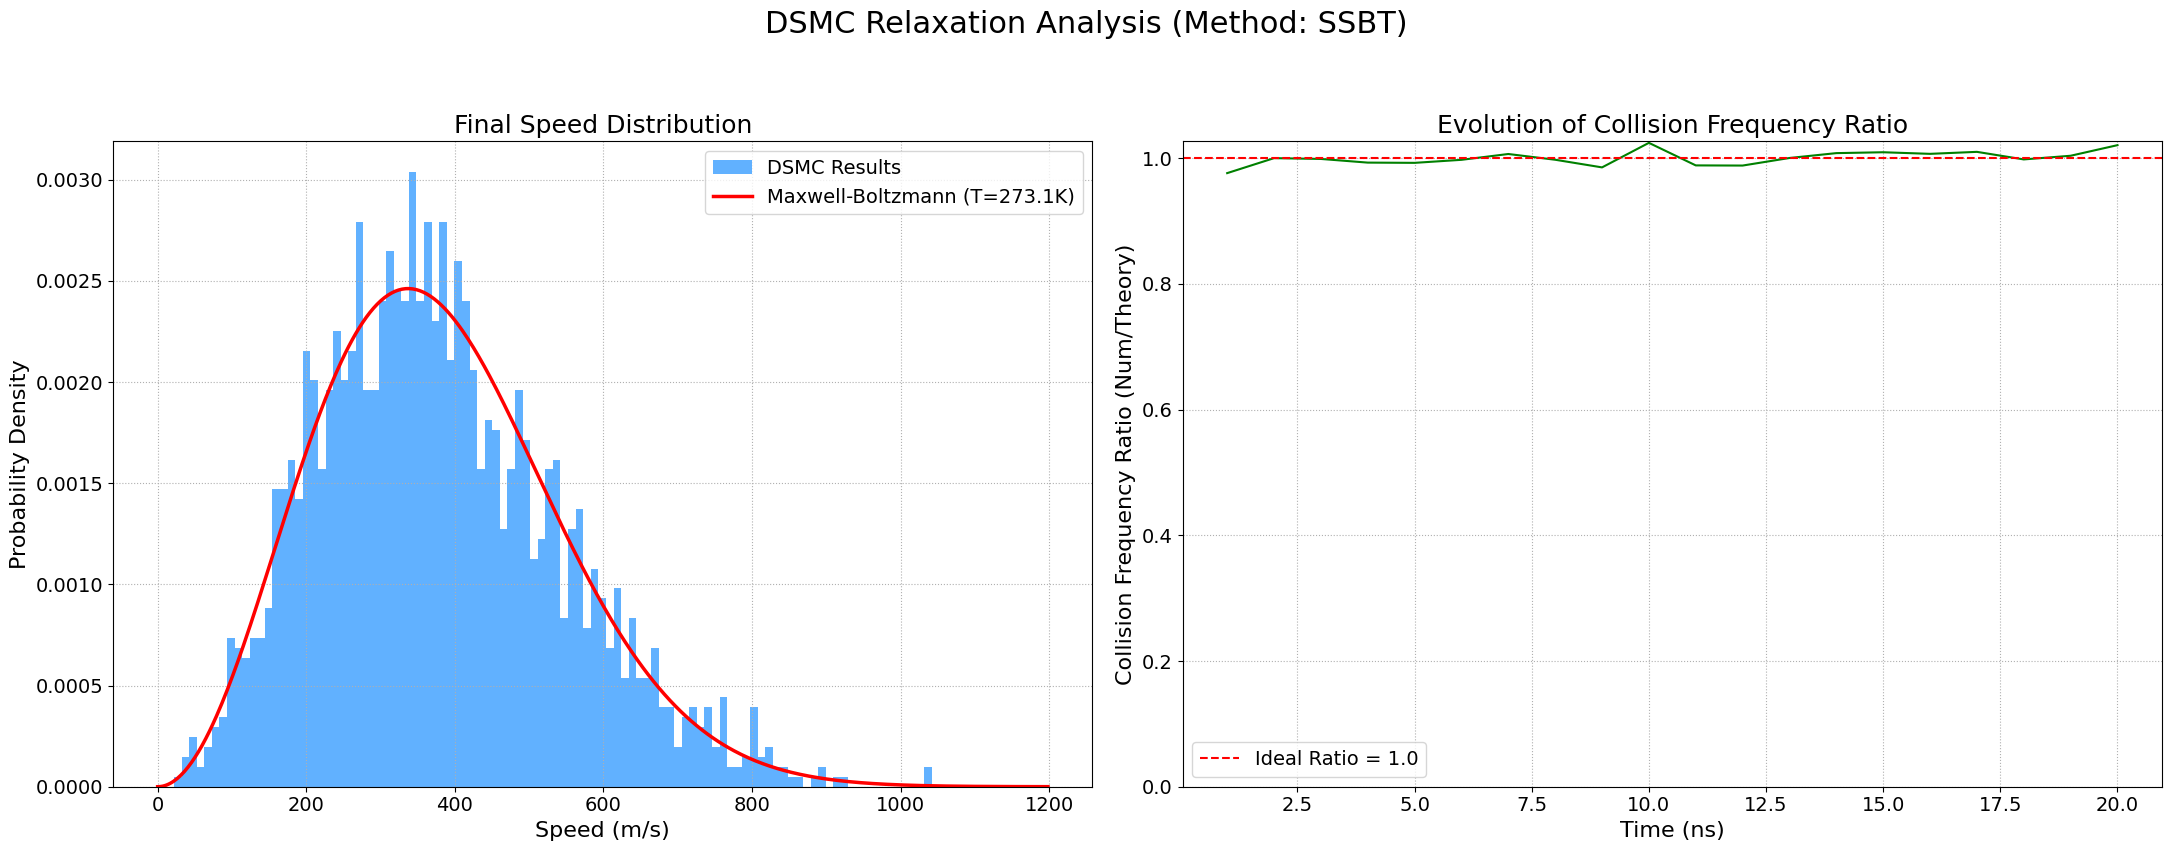

In [3]:
# -*- coding: utf-8 -*-
# --- DSMC Relaxation - V26.1 - Corrected Gamma Function ---
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time
from scipy.special import gammaln

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.50
PI = 3.141592654

# --- Simulation Parameters ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 100
PARTICLES_PER_CELL_INIT = 20
TOTAL_PARTICLES_SIM = int(NUM_CELLS_X * PARTICLES_PER_CELL_INIT)
N_DENSITY_REAL = RHO_INIT / MASS_AR

# Derived parameters
CELL_VOLUME_CONCEPTUAL = (LX) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 2.0e-8
SAMPLING_INTERVAL = 1000

# --- Numba-Jitted Core Functions ---
@njit(nopython=True)
def gamma_function_approx(x):
    """
    Corrected implementation of the Gamma function approximation,
    matching the logic of standard recurrence relations used in DSMC.
    """
    a = 1.0
    y = x
    # Use recurrence relation Gamma(z+1) = z*Gamma(z) to bring y into the range [1, 2)
    # and Gamma(z) = Gamma(z+1)/z for z < 1
    if y < 1.0:
        a = a / y
        y = y + 1.0

    while y >= 2.0:
        y = y - 1.0
        a = a * y

    # Polynomial approximation for Gamma(y) where y is in [1, 2)
    # The polynomial is for Gamma(1+z) where z is in [0, 1), so we transform y
    y = y - 1.0

    gamma_poly = 1.0 - 0.5748646*y + 0.9512363*y**2 - 0.6998588*y**3 + 0.4245549*y**4 - 0.1010678*y**5

    return a * gamma_poly

@njit(nopython=True)
def calculate_vhs_sigma_g(vr_mag):
    if vr_mag < 1e-9: return 0.0
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    # --- FIX: Using the corrected, dynamic gamma function ---
    gamma_val = gamma_function_approx(2.5 - OMEGA_VHS)
    sigma_g = (PI * D_REF_AR**2) * vr_mag * ((c_ref_sq / vr_mag**2)**exponent) / gamma_val
    return sigma_g

# --- The rest of the code is unchanged ---

@njit(nopython=True)
def perform_post_collision(p1_idx, p2_idx, particles, rng_state):
    vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
    vr_mag = np.sqrt(np.sum(vr**2))
    if vr_mag < 1e-9: return False
    vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
    cos_chi = 2 * rng_state.random() - 1.0
    sin_chi = np.sqrt(1.0 - cos_chi**2)
    phi_chi = 2.0 * PI * rng_state.random()
    rand_vec = np.array([sin_chi * np.cos(phi_chi), sin_chi * np.sin(phi_chi), cos_chi])
    vr_prime = vr_mag * rand_vec
    particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
    particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return True

@njit(nopython=True)
def standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state):
    n_accepted = 0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, 0, 0.0
    n_selected = float(num_particles_in_cell - 1)
    sum_sep = 0.0
    for i in range(num_particles_in_cell - 1):
        j_local = rng_state.integers(i + 1, num_particles_in_cell)
        p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j_local]
        vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(np.sum(vr**2))
        if vr_mag < 1e-9: continue
        sigma_g = calculate_vhs_sigma_g(vr_mag)
        multiplier = num_particles_in_cell - (i + 1)
        collision_prob = (multiplier * fnum * dt * sigma_g) / cell_vol
        if rng_state.random() < collision_prob:
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_sep += min(delta_x, lx - delta_x)
    return n_accepted, n_selected, sum_sep

@njit(nopython=True)
def perform_collisions(method, particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state, sigma_g_max_cell, n_sel_fraction, duplicate_check_array):
    n_accepted = 0
    n_selected = 0.0
    sum_separation = 0.0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0, sigma_g_max_cell, 0.0, 0.0

    if method == 1: # SBT
        prob_const = fnum * dt / cell_vol
        n_selected = num_particles_in_cell * (num_particles_in_cell - 1) / 2.0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                vr_mag = np.sqrt(np.sum(vr**2))
                if vr_mag < 1e-9: continue
                sigma_g = calculate_vhs_sigma_g(vr_mag)
                collision_prob = prob_const * sigma_g
                if rng_state.random() < collision_prob:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 2: # DCP
        num_pairs = num_particles_in_cell * (num_particles_in_cell - 1) // 2
        if num_pairs == 0: return 0, sigma_g_max_cell, 0.0, 0.0
        pairs = np.empty((num_pairs, 2), dtype=np.int32)
        weights = np.empty(num_pairs, dtype=np.float64)
        pair_count = 0
        for i in range(num_particles_in_cell):
            for j in range(i + 1, num_particles_in_cell):
                p1_idx, p2_idx = indices_in_cell[i], indices_in_cell[j]
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                distance = min(delta_x, lx - delta_x)
                weights[pair_count] = 1.0 / (distance + 1e-10)
                pairs[pair_count, 0] = p1_idx
                pairs[pair_count, 1] = p2_idx
                pair_count += 1
        sum_of_sigma_g = 0.0
        for i in range(num_pairs):
            p1_idx, p2_idx = pairs[i,0], pairs[i,1]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sum_of_sigma_g += calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
        expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
        num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))
        n_selected = float(num_collisions_to_perform)
        for _ in range(num_collisions_to_perform):
            if np.sum(weights) < 1e-12: break
            selected_idx = np.argmax(weights)
            p1_idx, p2_idx = pairs[selected_idx, 0], pairs[selected_idx, 1]
            if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                n_accepted += 1
                delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                sum_separation += min(delta_x, lx - delta_x)
            weights[selected_idx] = 0.0
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 3: # NTC
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)
        for _ in range(num_pairs_to_select):
            p1_idx_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            while p1_idx_local == p2_idx_local:
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
            p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 4: # GBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N - 1 or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        k_k_const = (N * (N - 1.0)) / (N_sel * (2.0 * N - N_sel - 1.0))
        prob_const = fnum * dt / cell_vol
        for i in range(N_sel):
            if i + 1 >= N: continue
            j = rng_state.integers(i + 1, N)
            p1_idx = reordered_global_indices[i]
            p2_idx = reordered_global_indices[j]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            k_k = k_k_const * (N - (i + 1.0))
            collision_prob = k_k * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 5: # SSBT
        prob_const = fnum * dt / cell_vol
        multiplier = (num_particles_in_cell - 1.0) / 2.0
        n_selected = float(num_particles_in_cell)
        for i_local in range(num_particles_in_cell):
            p1_idx = indices_in_cell[i_local]
            j_local = rng_state.integers(0, num_particles_in_cell)
            while j_local == i_local:
                j_local = rng_state.integers(0, num_particles_in_cell)
            p2_idx = indices_in_cell[j_local]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 6: # SGBT
        N = num_particles_in_cell
        N_sel = int(n_sel_fraction * N)
        if N_sel >= N or N_sel < 1:
            n_acc, n_sel_fallback, sum_sep = standard_sbt_scheme(particles, lx, indices_in_cell, cell_vol, dt, fnum, rng_state)
            return n_acc, sigma_g_max_cell, n_sel_fallback, sum_sep
        n_selected = float(N_sel)
        all_local_indices = np.arange(N)
        for i in range(N_sel):
            k = rng_state.integers(i, N)
            all_local_indices[i], all_local_indices[k] = all_local_indices[k], all_local_indices[i]
        reordered_global_indices = indices_in_cell[all_local_indices]
        prob_const = fnum * dt / cell_vol
        multiplier = (N * (N - 1.0)) / (N_sel * 2.0)
        for i in range(N_sel):
            p1_idx = reordered_global_indices[i]
            j = rng_state.integers(0, N)
            while j == i:
                j = rng_state.integers(0, N)
            p2_idx = reordered_global_indices[j]
            if duplicate_check_array[p1_idx] == p2_idx:
                continue
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(np.sum(vr**2))
            if vr_mag < 1e-9: continue
            sigma_g = calculate_vhs_sigma_g(vr_mag)
            collision_prob = multiplier * prob_const * sigma_g
            if rng_state.random() < collision_prob:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    duplicate_check_array[p1_idx] = p2_idx
                    duplicate_check_array[p2_idx] = p1_idx
                    delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                    sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    elif method == 7: # MFS
        cell_time = 0.0
        n_sel_counter = 0
        while cell_time < dt:
            num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
            if num_pairs_float < 1 or sigma_g_max_cell <= 0:
                break
            nu_max = num_pairs_float * fnum * sigma_g_max_cell / cell_vol
            delta_t_c = -np.log(1.0 - rng_state.random()) / nu_max
            cell_time += delta_t_c
            n_sel_counter += 1
            if cell_time < dt:
                p1_idx_local = rng_state.integers(0, num_particles_in_cell)
                p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                while p1_idx_local == p2_idx_local:
                    p2_idx_local = rng_state.integers(0, num_particles_in_cell)
                p1_idx, p2_idx = indices_in_cell[p1_idx_local], indices_in_cell[p2_idx_local]
                vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
                sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
                if sigma_g_current > sigma_g_max_cell:
                    sigma_g_max_cell = sigma_g_current
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
                elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                    if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                        n_accepted += 1
                        delta_x = np.abs(particles[p1_idx, 0] - particles[p2_idx, 0])
                        sum_separation += min(delta_x, lx - delta_x)
        return n_accepted, sigma_g_max_cell, float(n_sel_counter), sum_separation

    elif method == 8: # NN
        num_pairs_float = 0.5 * num_particles_in_cell * (num_particles_in_cell - 1)
        if sigma_g_max_cell <= 0: sigma_g_max_cell = 1e-18
        num_pairs_to_select = int(num_pairs_float * fnum * sigma_g_max_cell * dt / cell_vol + rng_state.random())
        n_selected = float(num_pairs_to_select)
        if n_selected == 0:
            return 0, sigma_g_max_cell, 0.0, 0.0
        N = num_particles_in_cell
        cell_positions = particles[indices_in_cell, 0]
        dist_matrix = np.full((N, N), np.finfo(np.float64).max, dtype=np.float64)
        for i in range(N):
            for j in range(i + 1, N):
                delta_x = np.abs(cell_positions[i] - cell_positions[j])
                dist = min(delta_x, lx - delta_x)
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist
        nearest_neighbor_map = np.argmin(dist_matrix, axis=1)
        for _ in range(num_pairs_to_select):
            p1_local_idx = rng_state.integers(0, N)
            p2_local_idx = nearest_neighbor_map[p1_local_idx]
            p1_idx, p2_idx = indices_in_cell[p1_local_idx], indices_in_cell[p2_local_idx]
            vr = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            sigma_g_current = calculate_vhs_sigma_g(np.sqrt(np.sum(vr**2)))
            if sigma_g_current > sigma_g_max_cell:
                sigma_g_max_cell = sigma_g_current
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
            elif rng_state.random() < sigma_g_current / sigma_g_max_cell:
                if perform_post_collision(p1_idx, p2_idx, particles, rng_state):
                    n_accepted += 1
                    sum_separation += dist_matrix[p1_local_idx, p2_local_idx]
        return n_accepted, sigma_g_max_cell, n_selected, sum_separation

    return 0, sigma_g_max_cell, 0.0, 0.0

@njit(nopython=True)
def calculate_theoretical_collision_frequency(avg_temp, n_density):
    d_ref_sq = D_REF_AR**2
    temp_ratio_term = (avg_temp / T_REF_AR)**(1.0 - OMEGA_VHS)
    sqrt_term = np.sqrt(PI * KB * T_REF_AR / MASS_AR)
    cf_th = 4 * n_density * d_ref_sq * sqrt_term * temp_ratio_term
    return cf_th

def calculate_numerical_collision_frequency(num_sim_collisions, num_particles, time_interval):
    if num_particles == 0 or time_interval == 0:
        return 0.0
    cf_num = num_sim_collisions / (0.5 * num_particles * time_interval)
    return cf_num

def plot_results(sampled_speeds, final_temp, method_name, freq_ratio_history, time_history):
    plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    fig.suptitle(f'DSMC Relaxation Analysis (Method: {method_name})', fontsize=22)
    ax1, ax2 = axes.flatten()

    if len(sampled_speeds) > 0:
        ax1.hist(sampled_speeds, bins=100, density=True, label='DSMC Results', alpha=0.7, color='dodgerblue')
        v_max_range = np.max(sampled_speeds) * 1.15 if len(sampled_speeds) > 0 else 1500
        v_theory = np.linspace(0, v_max_range, 500)
        pv_theory = (4 * np.pi * (MASS_AR / (2 * np.pi * KB * final_temp))**1.5 * v_theory**2 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
        ax1.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Maxwell-Boltzmann (T={final_temp:.1f}K)')
    ax1.set_xlabel('Speed (m/s)'); ax1.set_ylabel('Probability Density'); ax1.set_title('Final Speed Distribution')
    ax1.legend(); ax1.grid(True, linestyle=':')

    if time_history and freq_ratio_history:
        ax2.plot(np.array(time_history) * 1e9, freq_ratio_history, 'g-')
        ax2.axhline(1.0, color='r', linestyle='--', label='Ideal Ratio = 1.0')
    ax2.set_xlabel('Time (ns)'); ax2.set_ylabel('Collision Frequency Ratio (Num/Theory)'); ax2.set_title('Evolution of Collision Frequency Ratio')
    ax2.legend(); ax2.grid(True, linestyle=':'); ax2.set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    output_filename = f'DSMC_Frequency_Analysis_{method_name}.eps'
    plt.savefig(output_filename, format='eps')
    print(f"\nPlot saved as {output_filename}")
    plt.show()

def initialize_particles(rng_state):
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    print("Initializing particles with Maxwell-Boltzmann velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX
    v_thermal_std = np.sqrt(KB * T_INIT / MASS_AR)
    particles[:, 1:4] = rng_state.normal(0, v_thermal_std, (TOTAL_PARTICLES_SIM, 3))
    particles[:, 1:4] -= np.mean(particles[:, 1:4], axis=0)
    print(f"Initialized {TOTAL_PARTICLES_SIM} particles.")
    return particles

def run_dsmc_simulation(method_code, n_sel_fraction):
    method_map = {1: 'SBT', 2: 'DCP', 3: 'NTC', 4: 'GBT', 5: 'SSBT', 6: 'SGBT', 7: 'MFS', 8: 'NN'}
    collision_method_name = method_map.get(method_code, 'Unknown')
    print(f"--- DSMC Relaxation using method: {collision_method_name} ---")

    rng_state = np.random.default_rng(seed=42)
    particles = initialize_particles(rng_state)
    sigma_g_max = np.full(NUM_CELLS_X, 1e-18, dtype=np.float64)

    total_accepted_collisions = 0.0
    last_sampled_total_collisions = 0.0
    time_history, freq_ratio_history = [], []
    sampled_speeds_accumulator = []

    start_time = time.time()
    num_steps = int(TOTAL_TIME / DT)
    speed_sampling_start_step = int(TOTAL_TIME * 0.9 / DT)

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX

        step_accepted_collisions = 0
        duplicate_check_array = np.full(TOTAL_PARTICLES_SIM, -1, dtype=np.int64)
        cell_indices = (particles[:, 0] / (LX / NUM_CELLS_X)).astype(np.int64)

        for i in range(NUM_CELLS_X):
            indices_in_cell_i = np.where(cell_indices == i)[0]
            n_acc, new_sigma_g_max, _, _ = perform_collisions(
                method_code, particles, LX, indices_in_cell_i,
                CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state,
                sigma_g_max[i], n_sel_fraction, duplicate_check_array
            )
            sigma_g_max[i] = new_sigma_g_max
            step_accepted_collisions += n_acc

        total_accepted_collisions += step_accepted_collisions

        if step % SAMPLING_INTERVAL == 0 and step > 0:
            current_time = step * DT
            time_history.append(current_time)

            collisions_this_interval = total_accepted_collisions - last_sampled_total_collisions
            time_this_interval = SAMPLING_INTERVAL * DT

            current_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))

            cf_numerical = calculate_numerical_collision_frequency(collisions_this_interval, TOTAL_PARTICLES_SIM, time_this_interval)
            cf_theoretical = calculate_theoretical_collision_frequency(current_temp, N_DENSITY_REAL)

            ratio = cf_numerical / cf_theoretical if cf_theoretical > 0 else 0
            freq_ratio_history.append(ratio)

            last_sampled_total_collisions = total_accepted_collisions

        if step >= speed_sampling_start_step and step % (SAMPLING_INTERVAL * 5) == 0:
            sampled_speeds_accumulator.extend(np.sqrt(np.sum(particles[:, 1:4]**2, axis=1)))

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"\nSimulation finished in {end_time - start_time:.2f} seconds.")

    final_temp = (0.5 * MASS_AR / (1.5 * KB)) * np.mean(np.sum(particles[:,1:4]**2, axis=1))
    print(f"\nFinal Equilibrium Temperature: {final_temp:.2f} K")

    if sampled_speeds_accumulator:
        plot_results(np.array(sampled_speeds_accumulator), final_temp, collision_method_name, freq_ratio_history, time_history)

if __name__ == "__main__":
    while True:
        choice = input("Choose method: [1] SBT, [2] DCP, [3] NTC, [4] GBT, [5] SSBT, [6] SGBT, [7] MFS, [8] NN: ")
        if choice in ['1', '2', '3', '4', '5', '6', '7', '8']:
            n_sel_fraction = 0.5
            if choice in ['4', '6']:
                try:
                    n_sel_input = float(input(f"Enter the N_sel fraction for { {4:'GBT', 6:'SGBT'}[int(choice)] } (e.g., 0.33 for N/3): "))
                    if 0 < n_sel_input < 1:
                        n_sel_fraction = n_sel_input
                    else:
                        print("Invalid fraction. Using default value of 0.33.")
                        n_sel_fraction = 0.33
                except ValueError:
                    print("Invalid input. Using default value of 0.33.")
                    n_sel_fraction = 0.33

            run_dsmc_simulation(method_code=int(choice), n_sel_fraction=n_sel_fraction)
            break
        else:
            print("Invalid input.")